In [ ]:
# =========================================================
# Time-aware Page 1-3 Priority Classifier
# + Multi-BERT Soft Ensemble
# =========================================================

import os
import re
import glob
import json
import random
import signal
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup


# =========================================================
# 0. Config
# =========================================================

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"

RUN_ALL_MODELS = True
SINGLE_MODEL_KEY = "roberta_wwm_ext"

OUTPUT_SUFFIX = "page1to3_timeaware_multibert_ensemble"
RESUME_FROM_CHECKPOINT = False

MODEL_CONFIGS = {
    "roberta_wwm_ext": {
        "model_id": "hfl/chinese-roberta-wwm-ext",
        "model_tag": "chinese-roberta-wwm-ext",
        "display_name": "RoBERTa-wwm-ext",
    },
    "bert_base_chinese": {
        "model_id": "google-bert/bert-base-chinese",
        "model_tag": "bert-base-chinese",
        "display_name": "BERT base Chinese",
    },
    "chinese_bert_wwm_ext": {
        "model_id": "hfl/chinese-bert-wwm-ext",
        "model_tag": "chinese-bert-wwm-ext",
        "display_name": "Chinese BERT wwm-ext",
    },
}

RANDOM_SEED = 42

PAGE_COL = "scraped page number"
TEXT_COL = "title"
CONTENT_COL = "body"
DATE_COL = "published_at"
LABEL_COL = "labels"

TRAIN_SPLIT_FILENAME = "train_df.parquet"
VAL_SPLIT_FILENAME = "val_df 1.parquet"
TEST_SPLIT_FILENAME = "test_df 1.parquet"

MAX_LENGTH = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
WARMUP_RATIO = 0.1
EARLY_STOP_PATIENCE = 2
USE_GRADIENT_CLIPPING = True
MAX_GRAD_NORM = 1.0

USE_FIRST_LAST_SENTENCE = True
USE_TITLE_KEYWORDS = True
USE_BODY_KEYWORDS = True
USE_KEYWORD_INTERACTIONS = True

BODY_KEYWORD_MAX_CHARS = 1200
PREV_FRONT_LOOKBACK_DAYS = 30

SAVE_CHECKPOINT_EVERY_N_EPOCHS = 1
MAX_CHECKPOINTS_TO_KEEP = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Label definition
POSITIVE_PAGE_MAX = 1

# Loss config
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 1.5
POS_CLASS_WEIGHT = 8.0

# Time-decay sample weighting
USE_TIME_DECAY_WEIGHT = True
TIME_DECAY_HALFLIFE_DAYS = 365.0
TIME_DECAY_MIN_WEIGHT = 0.30
TIME_DECAY_MAX_WEIGHT = 1.00

# Ensemble config
ENSEMBLE_WEIGHT_SEARCH_STEP = 0.05


def sanitize_suffix(value: str) -> str:
    cleaned = re.sub(r"[^0-9A-Za-z._-]+", "-", str(value).strip())
    return cleaned.strip("-")


OUTPUT_SUFFIX = sanitize_suffix(OUTPUT_SUFFIX)

GLOBAL_COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "page1to3_timeaware_multibert_ensemble",
)
os.makedirs(GLOBAL_COMPARISON_DIR, exist_ok=True)


# =========================================================
# 1. Keywords
# =========================================================

TITLE_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "总书记", "国家主席", "中央军委主席",
        "李强", "赵乐际", "王沪宁", "蔡奇", "丁薛祥", "薛祥", "李希", "韩正",
        "李克强", "梁强", "阮富仲", "洪森", "苏林", "普京", "黄循财", "卢拉",
        "莫迪", "穆罕默德", "舒斯京", "拉马", "鲁托", "博沃", "欧尔", "莱恩", "桑切斯", "马克"
    ],
    "central_institutions": [
        "中共中央", "党中央", "中央政治局", "中央政治局常委", "中央政治局常委会", "中央军委",
        "国务院", "全国人大", "全国政协", "中共中央办公厅", "中央书记处",
        "中办国办", "中共中央国务院", "全军", "武警部队", "统一战线", "国务院令",
        "常委会", "常务委员会"
    ],
    "leadership_activities": [
        "主持召开", "主持", "出席", "会见", "接见", "视察", "考察", "调研",
        "重要讲话", "重要指示", "重要批示", "情况汇报", "工作汇报", "听取", "座谈",
        "看望", "致辞", "演讲", "主旨", "离京", "出访", "抵达", "回到",
        "春节前夕", "新年贺词", "团拜会", "预备会议", "常务会议", "全体会议",
        "闭幕式", "首发式", "开班式", "欢迎宴会", "晚宴", "出席会议", "隆重举行", "召开"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "唁电", "慰问电", "复信", "回信", "致信", "致电",
        "祝贺", "命令", "指示", "批示", "致以", "问候", "勉励", "祝福",
        "署名文章", "发表", "出版发行", "单行本", "读本", "英文版", "社论", "述评", "纪实"
    ],
    "political_meetings": [
        "中央政治局会议", "中央经济工作会议", "中央农村工作会议", "国务院常务会议",
        "全国两会", "全国人民代表大会", "中国人民政治协商会议", "峰会", "全会",
        "代表大会", "开幕会", "联组会", "小组会议", "会议议程", "十四五", "十五五"
    ],
    "diplomacy": [
        "国事访问", "非正式", "外事活动", "欢迎仪式", "欢迎宴会", "欢送", "送行"
    ],
    "policy_or_philosophy": [
        "强国建设", "民族复兴", "坚定信心", "奋发有为", "锲而不舍", "中国式现代化",
        "高质量发展", "改革开放", "共同富裕", "新质生产力", "优秀党员", "党性", "党纪", "论述"
    ],
    "military": [
        "军衔", "上将", "部队", "军队", "战士", "我军", "全军", "动员", "检阅", "分列式"
    ],
    "foreign_entities": [
        "越南共产党", "越共中央", "老挝人民革命党", "亚太经合组织", "欧盟委员会",
        "十国集团", "阿塞拜疆", "斯洛伐克", "斐济", "国王", "总统", "元首", "参议长",
        "财政部长", "国民议会", "参议院"
    ],
    "other_high_freq": [
        "火化", "遗体", "牵挂", "求是", "杂志", "专题学习", "述职", "连任", "就任",
        "学习", "研讨班", "会议精神", "贯彻落实"
    ],
}

BODY_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "蔡奇", "韩正", "薛祥", "王沪宁", "李希", "李强", "赵乐际",
        "彭丽媛", "普京", "莫迪", "阮富仲", "苏林", "梁强", "胡锦涛", "李克强"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "慰问电", "唁电", "回信", "致电", "祝贺",
        "命令", "致以", "就任", "勉励", "悼念", "沉痛", "火化", "遗像", "生前友好"
    ],
    "central_institutions": [
        "中共中央", "中央办公厅", "中央书记处", "中央政治局常委",
        "中央政治局常委会", "中央军委", "军委", "各级党委", "全国政协",
        "政协全国委员会", "政协常委会", "越南共产党", "越共中央", "武警部队"
    ],
    "state_places": [
        "北京人民大会堂", "人民大会堂", "中南海", "北京中南海",
        "北京钓鱼台国宾馆", "天安门广场", "主席台", "检阅台"
    ],
    "official_activities_discourse": [
        "陪同", "重要讲话", "特命", "诚挚", "团拜会", "党外人士", "主持", "会谈",
        "工作汇报", "情况汇报", "汇报会", "列席会议", "主持会议", "出席会议",
        "专题学习", "读书班", "欢迎仪式", "欢迎宴会", "欢送", "送行",
        "乘专机", "专机", "返京", "出京", "下榻", "红毯", "礼兵", "仪仗队",
        "军乐团", "鸣放", "礼炮", "国歌", "握手", "挥手致意", "接见", "十四五", "十五五"
    ],
    "Announcement_of_the_Passing_of_an_Important_Figure": [
        "火化", "悼念", "沉痛", "遗像", "生前友好"
    ],
}

TITLE_KEYWORD_COMBOS = [
    ("习近平", "重要讲话"),
    ("习近平", "重要指示"),
    ("习近平", "重要批示"),
    ("习近平", "贺信"),
    ("习近平", "回信"),
    ("习近平", "会见"),
    ("习近平", "主持召开"),
    ("中央政治局", "会议"),
    ("中共中央", "国务院"),
    ("中央军委", "习近平"),
    ("李强", "国务院"),
    ("赵乐际", "全国人大"),
    ("王沪宁", "全国政协"),
    ("强国建设", "民族复兴"),
    ("中国式现代化", "高质量发展"),
    ("欢迎仪式", "人民大会堂"),
    ("欢迎宴会", "人民大会堂"),
    ("国事访问", "习近平"),
    ("出访", "习近平"),
    ("专题学习", "习近平"),
    ("求是", "习近平"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
    ("中央军委", "重要讲话"),
    ("李强", "重要讲话"),
    ("欢迎宴会", "国事访问"),
]

BODY_KEYWORD_COMBOS = [
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("中央军委", "习近平"),
    ("中央军委", "重要讲话"),
    ("中共中央", "工作汇报"),
    ("中共中央", "重要讲话"),
    ("各级党委", "重要讲话"),
    ("李强", "重要讲话"),
    ("赵乐际", "重要讲话"),
    ("王沪宁", "重要讲话"),
    ("韩正", "重要讲话"),
    ("北京人民大会堂", "欢迎仪式"),
    ("人民大会堂", "欢迎宴会"),
    ("北京人民大会堂", "陪同"),
    ("人民大会堂", "陪同"),
    ("礼兵", "仪仗队"),
    ("专机", "返京"),
    ("祝贺", "致以"),
    ("诚挚", "祝贺"),
    ("回信", "重要讲话"),
    ("火化", "遗像"),
    ("唁电", "慰问电"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
]


# =========================================================
# 2. Utilities
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clean_text(x):
    return "" if pd.isna(x) else str(x).strip()


def ensure_model_snapshot(model_id, cache_dir):
    if os.path.isdir(cache_dir) and os.listdir(cache_dir):
        return cache_dir
    print(f"Downloading {model_id} -> {cache_dir}")
    snapshot_download(
        repo_id=model_id,
        local_dir=cache_dir,
        local_dir_use_symlinks=False,
    )
    return cache_dir


def find_best_threshold_on_val(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_predictions(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}precision": precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall": recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}f1": f1_score(y_true, y_pred, zero_division=0),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    try:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics[f"{prefix}roc_auc"] = np.nan

    return metrics, y_pred


def print_metrics_dict(metrics):
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")


def get_checkpoint_epoch(path):
    m = re.search(r"checkpoint_epoch_(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


def compute_time_decay_weights(dates, reference_date=None):
    dates = pd.to_datetime(dates, errors="coerce")

    if reference_date is None:
        reference_date = dates.max()

    reference_date = pd.to_datetime(reference_date)

    delta_days = (reference_date - dates).dt.days.fillna(0).clip(lower=0)

    decay_lambda = np.log(2.0) / TIME_DECAY_HALFLIFE_DAYS
    weights = np.exp(-decay_lambda * delta_days)

    weights = np.clip(weights, TIME_DECAY_MIN_WEIGHT, TIME_DECAY_MAX_WEIGHT)

    return weights.astype(float)


# =========================================================
# 3. Loss
# =========================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets, sample_weights=None):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.alpha,
        )

        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        if sample_weights is not None:
            loss = loss * sample_weights

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


class WeightedCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.class_weights = class_weights

    def forward(self, logits, targets, sample_weights=None):
        loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.class_weights,
        )

        if sample_weights is not None:
            loss = loss * sample_weights

        return loss.mean()


# =========================================================
# 4. Features
# =========================================================

def extract_title_text_features(text: str):
    text = str(text) if not isinstance(text, str) else text
    length = max(len(text), 1)
    return {
        "title_text_length": min(len(text) / 100, 1.0),
        "title_has_number": float(any(c.isdigit() for c in text)),
        "title_has_colon": float("：" in text or ":" in text),
        "title_has_exclamation": float("！" in text or "!" in text),
        "title_has_question": float("？" in text or "?" in text),
        "title_has_parenthesis": float(any(ch in text for ch in ["（", "(", "）", ")"])),
        "title_digit_ratio": min(sum(c.isdigit() for c in text) / length, 0.5),
        "title_punctuation_ratio": min(sum(not c.isalnum() and not c.isspace() for c in text) / length, 0.5),
    }


def extract_first_last_sentence(text, max_len=128):
    if not isinstance(text, str) or not text:
        return "", ""

    sentences = [
        s.strip()
        for s in re.split(r"[。！？!?]+", text)
        if len(s.strip()) > 5
    ]

    first = sentences[0] if sentences else ""
    last = sentences[-1] if len(sentences) > 1 else first

    return first[:max_len], last[:max_len]


def extract_quarter_features(df, date_col):
    if date_col in df.columns:
        dates = pd.to_datetime(df[date_col], errors="coerce")
    else:
        dates = pd.Series([pd.NaT] * len(df), index=df.index)

    q = dates.dt.quarter.fillna(0)

    return pd.DataFrame(
        {
            "date_quarter_sin": np.sin(2 * np.pi * q / 4),
            "date_quarter_cos": np.cos(2 * np.pi * q / 4),
        },
        index=df.index,
    ).fillna(0.0)


def extract_keyword_features_bool(text, keyword_categories, keyword_combos, max_chars=None):
    text = "" if pd.isna(text) else str(text).strip()

    if max_chars is not None and max_chars > 0:
        text = text[:max_chars]

    out = {}

    if not text:
        for cat in keyword_categories:
            out[f"kw_{cat}_any"] = 0.0
        for i in range(len(keyword_combos)):
            out[f"kw_combo_{i}_both"] = 0.0
        out["kw_any_match"] = 0.0
        return out

    any_match = False

    for cat, kws in keyword_categories.items():
        hit = any(kw in text for kw in kws)
        out[f"kw_{cat}_any"] = float(hit)
        any_match = any_match or hit

    for i, (kw1, kw2) in enumerate(keyword_combos):
        both = (kw1 in text) and (kw2 in text)
        out[f"kw_combo_{i}_both"] = float(both)
        any_match = any_match or both

    out["kw_any_match"] = float(any_match)
    return out


def extract_keyword_features_batch(df, text_col, prefix, categories, combos, max_chars=None):
    if text_col not in df.columns:
        return pd.DataFrame(index=df.index)

    features = [
        extract_keyword_features_bool(
            text,
            categories,
            combos,
            max_chars=max_chars,
        )
        for text in tqdm(df[text_col].fillna(""), desc=f"Extract {prefix} bool keyword")
    ]

    feat_df = pd.DataFrame(features, index=df.index).fillna(0.0)
    return feat_df.rename(columns=lambda c: f"{prefix}_{c}")


def build_keyword_interactions(title_kw_df, body_kw_df):
    out = pd.DataFrame(index=title_kw_df.index)

    shared = sorted(
        set(TITLE_KEYWORD_CATEGORIES).intersection(BODY_KEYWORD_CATEGORIES)
    )

    for cat in shared:
        tc = f"title_kw_{cat}_any"
        bc = f"body_kw_{cat}_any"

        if tc in title_kw_df.columns and bc in body_kw_df.columns:
            out[f"inter_kw_{cat}_both"] = (
                title_kw_df[tc].values * body_kw_df[bc].values
            )

    if "title_kw_any_match" in title_kw_df.columns and "body_kw_any_match" in body_kw_df.columns:
        out["inter_kw_title_body_any"] = (
            title_kw_df["title_kw_any_match"].values
            * body_kw_df["body_kw_any_match"].values
        )

    return out.fillna(0.0)


def build_feature_table(df):
    title_feat = pd.DataFrame(
        [
            extract_title_text_features(t)
            for t in tqdm(df[TEXT_COL], desc="Title text features")
        ],
        index=df.index,
    ).fillna(0.0)

    keyword_parts = []
    title_kw = pd.DataFrame(index=df.index)
    body_kw = pd.DataFrame(index=df.index)

    if USE_TITLE_KEYWORDS:
        title_kw = extract_keyword_features_batch(
            df,
            TEXT_COL,
            "title",
            TITLE_KEYWORD_CATEGORIES,
            TITLE_KEYWORD_COMBOS,
        )
        keyword_parts.append(title_kw)

    if USE_BODY_KEYWORDS:
        body_kw = extract_keyword_features_batch(
            df,
            CONTENT_COL,
            "body",
            BODY_KEYWORD_CATEGORIES,
            BODY_KEYWORD_COMBOS,
            max_chars=BODY_KEYWORD_MAX_CHARS,
        )
        keyword_parts.append(body_kw)

    if USE_KEYWORD_INTERACTIONS and USE_TITLE_KEYWORDS and USE_BODY_KEYWORDS:
        keyword_parts.append(build_keyword_interactions(title_kw, body_kw))

    if keyword_parts:
        keyword_feat = pd.concat(keyword_parts, axis=1).fillna(0.0)
    else:
        keyword_feat = pd.DataFrame(index=df.index)

    quarter_feat = extract_quarter_features(df, DATE_COL)

    return pd.concat(
        [title_feat, keyword_feat, quarter_feat],
        axis=1,
    ).fillna(0.0)


# =========================================================
# 5. Dataset / Model
# =========================================================

class DualDataset(Dataset):
    def __init__(
        self,
        current_titles,
        prev_titles,
        labels,
        extra_features,
        tokenizer,
        sample_weights=None,
        first_sentences=None,
        last_sentences=None,
        max_length=128,
    ):
        self.current_titles = list(current_titles)
        self.prev_titles = list(prev_titles)
        self.labels = list(labels)
        self.extra_features = extra_features
        self.tokenizer = tokenizer
        self.max_length = max_length

        if sample_weights is None:
            self.sample_weights = [1.0] * len(self.labels)
        else:
            self.sample_weights = list(sample_weights)

        self.first_sentences = first_sentences
        self.last_sentences = last_sentences

        self.use_sentence_features = (
            first_sentences is not None
            and last_sentences is not None
        )

    def __len__(self):
        return len(self.current_titles)

    def _encode(self, text, max_length):
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt",
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __getitem__(self, idx):
        cur_ids, cur_mask = self._encode(
            self.current_titles[idx],
            self.max_length,
        )

        prev_ids, prev_mask = self._encode(
            self.prev_titles[idx] or "",
            self.max_length,
        )

        item = {
            "current_input_ids": cur_ids,
            "current_attention_mask": cur_mask,
            "prev_input_ids": prev_ids,
            "prev_attention_mask": prev_mask,
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
            "sample_weights": torch.tensor(self.sample_weights[idx], dtype=torch.float),
        }

        if self.extra_features is not None:
            item["extra_features"] = torch.tensor(
                self.extra_features.iloc[idx].values.astype(np.float32),
                dtype=torch.float,
            )

        if self.use_sentence_features:
            first_ids, first_mask = self._encode(
                self.first_sentences[idx] or "",
                self.max_length // 2,
            )
            last_ids, last_mask = self._encode(
                self.last_sentences[idx] or "",
                self.max_length // 2,
            )

            item.update(
                {
                    "first_input_ids": first_ids,
                    "first_attention_mask": first_mask,
                    "last_input_ids": last_ids,
                    "last_attention_mask": last_mask,
                }
            )

        return item


class DualInputClassifier(nn.Module):
    def __init__(
        self,
        encoder,
        extra_feature_dim,
        hidden_dim=256,
        dropout=0.3,
        use_sentence_features=False,
    ):
        super().__init__()

        self.encoder = encoder
        self.extra_feature_dim = extra_feature_dim
        self.use_sentence_features = use_sentence_features

        total_dim = encoder.config.hidden_size * 2 + extra_feature_dim

        if use_sentence_features:
            total_dim += encoder.config.hidden_size * 2

        self.total_dim = total_dim

        self.classifier = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def _cls(self, input_ids, attention_mask):
        return self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).last_hidden_state[:, 0, :]

    def forward(
        self,
        current_input_ids,
        current_attention_mask,
        prev_input_ids,
        prev_attention_mask,
        extra_features=None,
        first_input_ids=None,
        first_attention_mask=None,
        last_input_ids=None,
        last_attention_mask=None,
    ):
        embeds = [
            self._cls(current_input_ids, current_attention_mask),
            self._cls(prev_input_ids, prev_attention_mask),
        ]

        if self.use_sentence_features and first_input_ids is not None and last_input_ids is not None:
            embeds.extend(
                [
                    self._cls(first_input_ids, first_attention_mask),
                    self._cls(last_input_ids, last_attention_mask),
                ]
            )

        combined = torch.cat(embeds, dim=1)

        if extra_features is not None and self.extra_feature_dim > 0:
            combined = torch.cat([combined, extra_features], dim=1)

        return self.classifier(combined)


# =========================================================
# 6. Checkpoint Manager
# =========================================================

class CheckpointManager:
    def __init__(self, output_dir, best_model_filename, max_checkpoints=3):
        self.output_dir = output_dir
        self.best_model_filename = best_model_filename
        self.max_checkpoints = max_checkpoints
        self.checkpoint_dir = os.path.join(output_dir, "checkpoints")
        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def save(
        self,
        epoch,
        model,
        optimizer,
        scheduler,
        best_val_f1,
        best_epoch,
        best_threshold,
        patience_counter,
        history,
        is_best,
        extra_feature_dim,
        model_key,
        use_sentence_features,
    ):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "best_threshold": best_threshold,
            "patience_counter": patience_counter,
            "history": history,
            "extra_feature_dim": extra_feature_dim,
            "model_key": model_key,
            "use_sentence_features": use_sentence_features,
            "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
        }

        ckpt_path = os.path.join(
            self.checkpoint_dir,
            f"checkpoint_epoch_{epoch}.pt",
        )
        torch.save(ckpt, ckpt_path)

        if is_best:
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_f1": best_val_f1,
                    "best_threshold": best_threshold,
                    "extra_feature_dim": extra_feature_dim,
                    "model_key": model_key,
                    "use_sentence_features": use_sentence_features,
                    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
                },
                os.path.join(self.output_dir, self.best_model_filename),
            )

        self.cleanup()

    def cleanup(self):
        checkpoints = sorted(
            glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")),
            key=get_checkpoint_epoch,
        )

        for old in checkpoints[:-self.max_checkpoints]:
            try:
                os.remove(old)
            except Exception:
                pass

    def load_latest(
        self,
        model,
        optimizer,
        scheduler,
        device,
        current_extra_feature_dim,
        current_model_key,
        current_use_sentence_features,
    ):
        checkpoints = sorted(
            glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")),
            key=get_checkpoint_epoch,
            reverse=True,
        )

        for path in checkpoints:
            try:
                ckpt = torch.load(path, map_location=device)

                if int(ckpt.get("extra_feature_dim", -1)) != int(current_extra_feature_dim):
                    continue

                if ckpt.get("model_key") not in [None, current_model_key]:
                    continue

                if ckpt.get("use_sentence_features") not in [None, current_use_sentence_features]:
                    continue

                model.load_state_dict(ckpt["model_state_dict"])
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])

                return ckpt

            except Exception:
                continue

        return None


class GracefulExiter:
    def __init__(self):
        self.should_exit = False
        signal.signal(signal.SIGINT, self.exit_gracefully)
        signal.signal(signal.SIGTERM, self.exit_gracefully)

    def exit_gracefully(self, signum, frame):
        print("\nReceived stop signal. Will stop after current epoch.")
        self.should_exit = True


# =========================================================
# 7. Data building
# =========================================================

def load_and_clean_split(path, split_name):
    df = pd.read_parquet(path).copy()

    df[PAGE_COL] = pd.to_numeric(df[PAGE_COL], errors="coerce")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

    df = df.dropna(subset=[PAGE_COL, DATE_COL]).copy()

    df[PAGE_COL] = df[PAGE_COL].astype(int)
    df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

    if CONTENT_COL in df.columns:
        df[CONTENT_COL] = df[CONTENT_COL].fillna("").astype(str)

    df = df[df[TEXT_COL].str.len() > 0].copy()

    # Main label change: page 1-3 are positive.
    df[LABEL_COL] = (df[PAGE_COL] <= POSITIVE_PAGE_MAX).astype(int)

    df["date_only"] = df[DATE_COL].dt.normalize()
    df["split"] = split_name

    return df


def build_prev_front_title(df, lookback_days=30):
    front_df = (
        df.loc[df[PAGE_COL] == 1, ["date_only", TEXT_COL]]
        .drop_duplicates(subset=["date_only"])
    )

    front_map = dict(zip(front_df["date_only"], front_df[TEXT_COL]))

    prev_titles = []

    for d in df["date_only"]:
        found = ""

        for k in range(1, lookback_days + 1):
            cand = d - pd.Timedelta(days=k)

            if cand in front_map:
                found = front_map[cand]
                break

        prev_titles.append(found)

    return pd.Series(prev_titles, index=df.index)


def build_data_and_features(base_dir):
    paths = {
        "train": os.path.join(base_dir, TRAIN_SPLIT_FILENAME),
        "val": os.path.join(base_dir, VAL_SPLIT_FILENAME),
        "test": os.path.join(base_dir, TEST_SPLIT_FILENAME),
    }

    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} split not found: {path}")

    train_df = load_and_clean_split(paths["train"], "train")
    val_df = load_and_clean_split(paths["val"], "val")
    test_df = load_and_clean_split(paths["test"], "test")

    df = (
        pd.concat([train_df, val_df, test_df], ignore_index=True)
        .sort_values(["date_only", PAGE_COL, TEXT_COL])
        .reset_index(drop=True)
    )

    df["prev_front_title"] = (
        build_prev_front_title(df, lookback_days=PREV_FRONT_LOOKBACK_DAYS)
        .fillna("")
        .apply(clean_text)
    )

    if USE_TIME_DECAY_WEIGHT:
        reference_date = df.loc[df["split"] == "train", "date_only"].max()
        df["sample_weight"] = compute_time_decay_weights(
            df["date_only"],
            reference_date=reference_date,
        )
    else:
        df["sample_weight"] = 1.0

    first_last = None

    if USE_FIRST_LAST_SENTENCE and CONTENT_COL in df.columns:
        firsts, lasts = zip(
            *[
                extract_first_last_sentence(x)
                for x in tqdm(df[CONTENT_COL], desc="First/last sentence")
            ]
        )
        first_last = (
            pd.Series(firsts, index=df.index),
            pd.Series(lasts, index=df.index),
        )

    extra_features_df = build_feature_table(df)

    split_idx = {s: df.index[df["split"] == s] for s in ["train", "val", "test"]}

    bundle = {
        "df": df,
        "train_df": df.loc[split_idx["train"]].copy().reset_index(drop=True),
        "val_df": df.loc[split_idx["val"]].copy().reset_index(drop=True),
        "test_df": df.loc[split_idx["test"]].copy().reset_index(drop=True),
        "train_extra": extra_features_df.loc[split_idx["train"]].reset_index(drop=True),
        "val_extra": extra_features_df.loc[split_idx["val"]].reset_index(drop=True),
        "test_extra": extra_features_df.loc[split_idx["test"]].reset_index(drop=True),
        "extra_features_df": extra_features_df,
    }

    if first_last is not None:
        first_series, last_series = first_last

        for split in ["train", "val", "test"]:
            idx = split_idx[split]
            bundle[f"{split}_first"] = first_series.loc[idx].tolist()
            bundle[f"{split}_last"] = last_series.loc[idx].tolist()
    else:
        for split in ["train", "val", "test"]:
            bundle[f"{split}_first"] = None
            bundle[f"{split}_last"] = None

    print("\nLabel definition:")
    print(f"Positive = page <= {POSITIVE_PAGE_MAX}")

    print("\nSplit label distribution:")
    for split in ["train", "val", "test"]:
        tmp = bundle[f"{split}_df"]
        print(
            split,
            tmp[LABEL_COL].value_counts().sort_index().to_dict(),
            f"positive_rate={tmp[LABEL_COL].mean():.2%}",
        )

    print("\nFeature columns:")
    print(extra_features_df.columns.tolist())
    print(f"Extra feature dim: {extra_features_df.shape[1]}")

    print(
        f"Prev-front coverage ({PREV_FRONT_LOOKBACK_DAYS}d): "
        f"{(df['prev_front_title'].str.len() > 0).mean():.2%}"
    )

    if USE_TIME_DECAY_WEIGHT:
        print("\nTime-decay sample weight summary:")
        print(df.loc[df["split"] == "train", "sample_weight"].describe())

    return bundle


# =========================================================
# 8. Train / eval helpers
# =========================================================

def move_optional_tensor(batch, key):
    x = batch.get(key, None)
    return x.to(DEVICE) if x is not None else None


def run_eval(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )

            labels = batch["labels"].to(DEVICE)
            sample_weights = batch["sample_weights"].to(DEVICE)

            loss = criterion(logits, labels, sample_weights=sample_weights)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / max(len(data_loader), 1),
        np.array(all_labels),
        np.array(all_probs),
    )


def save_curves(history_df, best_epoch, title, path):
    if len(history_df) == 0:
        return

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")

    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")

    plt.title(f"{title}: Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["val_f1@best_thr"], marker="o", label="val_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="s", label="val_macro_f1")

    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")

    plt.title(f"{title}: Validation F1")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def build_and_save_summary_matrix(
    model_key,
    model_id,
    model_display_name,
    y_test,
    test_pred,
    test_prob,
    best_threshold,
    best_epoch,
    output_dir,
    final_summary_filename,
):
    label_precision, label_recall, label_f1, label_support = precision_recall_fscore_support(
        y_test,
        test_pred,
        labels=[0, 1],
        zero_division=0,
    )

    macro_precision = precision_score(y_test, test_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, test_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, test_pred)

    try:
        roc_auc = roc_auc_score(y_test, test_prob)
    except Exception:
        roc_auc = np.nan

    summary = pd.DataFrame(
        [
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "subset": "label_0_negative",
                "n_samples": int(label_support[0]),
                "precision": float(label_precision[0]),
                "recall": float(label_recall[0]),
                "f1": float(label_f1[0]),
                "accuracy": np.nan,
                "roc_auc": np.nan,
                "best_threshold": float(best_threshold),
                "best_epoch": int(best_epoch),
            },
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "subset": "label_1_positive",
                "n_samples": int(label_support[1]),
                "precision": float(label_precision[1]),
                "recall": float(label_recall[1]),
                "f1": float(label_f1[1]),
                "accuracy": np.nan,
                "roc_auc": np.nan,
                "best_threshold": float(best_threshold),
                "best_epoch": int(best_epoch),
            },
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "subset": "macro_avg",
                "n_samples": int(np.sum(label_support)),
                "precision": float(macro_precision),
                "recall": float(macro_recall),
                "f1": float(macro_f1),
                "accuracy": float(accuracy),
                "roc_auc": float(roc_auc),
                "best_threshold": float(best_threshold),
                "best_epoch": int(best_epoch),
            },
        ]
    )

    out_path = os.path.join(output_dir, final_summary_filename)
    summary.to_csv(out_path, index=False, encoding="utf-8-sig")

    return summary


# =========================================================
# 9. Ensemble helpers
# =========================================================

def search_best_ensemble_weights(val_prob_dict, y_val, step=0.05):
    model_keys = list(val_prob_dict.keys())

    if len(model_keys) == 1:
        key = model_keys[0]
        prob = val_prob_dict[key]
        threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
        return {key: 1.0}, threshold, best_f1, prob

    if len(model_keys) == 2:
        best = None

        grid = np.arange(0, 1 + 1e-9, step)

        k1, k2 = model_keys

        for w1 in grid:
            w2 = 1.0 - w1
            prob = w1 * val_prob_dict[k1] + w2 * val_prob_dict[k2]
            threshold, f1 = find_best_threshold_on_val(y_val, prob)

            if best is None or f1 > best["f1"]:
                best = {
                    "weights": {k1: float(w1), k2: float(w2)},
                    "threshold": float(threshold),
                    "f1": float(f1),
                    "prob": prob,
                }

        return best["weights"], best["threshold"], best["f1"], best["prob"]

    if len(model_keys) == 3:
        best = None

        grid = np.arange(0, 1 + 1e-9, step)

        k1, k2, k3 = model_keys

        for w1 in grid:
            for w2 in grid:
                w3 = 1.0 - w1 - w2

                if w3 < -1e-9:
                    continue

                prob = (
                    w1 * val_prob_dict[k1]
                    + w2 * val_prob_dict[k2]
                    + w3 * val_prob_dict[k3]
                )

                threshold, f1 = find_best_threshold_on_val(y_val, prob)

                if best is None or f1 > best["f1"]:
                    best = {
                        "weights": {
                            k1: float(w1),
                            k2: float(w2),
                            k3: float(w3),
                        },
                        "threshold": float(threshold),
                        "f1": float(f1),
                        "prob": prob,
                    }

        return best["weights"], best["threshold"], best["f1"], best["prob"]

    # fallback: equal weight
    weights = {k: 1.0 / len(model_keys) for k in model_keys}
    prob = sum(weights[k] * val_prob_dict[k] for k in model_keys)
    threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
    return weights, threshold, best_f1, prob


def apply_ensemble(prob_dict, weights):
    prob = None

    for k, w in weights.items():
        if prob is None:
            prob = w * prob_dict[k]
        else:
            prob += w * prob_dict[k]

    return prob


# =========================================================
# 10. Main training loop for one model
# =========================================================

def run_one_model(model_key, data_bundle):
    set_seed(RANDOM_SEED)

    cfg = MODEL_CONFIGS[model_key]
    model_id = cfg["model_id"]
    model_tag = cfg["model_tag"]
    model_display_name = cfg["display_name"]

    body_flag = "bodykw" if USE_BODY_KEYWORDS else "no_bodykw"
    inter_flag = "inter" if USE_KEYWORD_INTERACTIONS else "no_inter"
    loss_flag = "focal" if USE_FOCAL_LOSS else "ce"
    time_flag = "timedecay" if USE_TIME_DECAY_WEIGHT else "notimedecay"

    run_name = (
        f"page1to{POSITIVE_PAGE_MAX}_{model_tag}_"
        f"prevfront{PREV_FRONT_LOOKBACK_DAYS}d_"
        f"boolkw_{body_flag}_{inter_flag}_{loss_flag}_{time_flag}"
    )

    if OUTPUT_SUFFIX:
        run_name = f"{run_name}_{OUTPUT_SUFFIX}"

    output_dir = os.path.join(BASE_DIR, "outputs", run_name)
    os.makedirs(output_dir, exist_ok=True)

    local_model_path = ensure_model_snapshot(
        model_id,
        os.path.join(BASE_DIR, "hf_models", model_tag),
    )

    tokenizer = AutoTokenizer.from_pretrained(
        local_model_path,
        local_files_only=True,
    )

    train_df = data_bundle["train_df"]
    val_df = data_bundle["val_df"]
    test_df = data_bundle["test_df"]

    train_extra = data_bundle["train_extra"]
    val_extra = data_bundle["val_extra"]
    test_extra = data_bundle["test_extra"]

    def build_dataset(df, extra, split):
        return DualDataset(
            current_titles=df[TEXT_COL].tolist(),
            prev_titles=df["prev_front_title"].tolist(),
            labels=df[LABEL_COL].tolist(),
            extra_features=extra,
            tokenizer=tokenizer,
            sample_weights=df["sample_weight"].tolist(),
            first_sentences=data_bundle[f"{split}_first"],
            last_sentences=data_bundle[f"{split}_last"],
            max_length=MAX_LENGTH,
        )

    train_loader = DataLoader(
        build_dataset(train_df, train_extra, "train"),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    val_loader = DataLoader(
        build_dataset(val_df, val_extra, "val"),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_loader = DataLoader(
        build_dataset(test_df, test_extra, "test"),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    base_encoder = AutoModel.from_pretrained(
        local_model_path,
        use_safetensors=False,
        local_files_only=True,
    )

    sample_batch = next(iter(train_loader))
    extra_feature_dim = int(sample_batch["extra_features"].shape[1]) if "extra_features" in sample_batch else 0

    model = DualInputClassifier(
        base_encoder,
        extra_feature_dim=extra_feature_dim,
        hidden_dim=256,
        dropout=0.3,
        use_sentence_features=USE_FIRST_LAST_SENTENCE,
    ).to(DEVICE)

    num_neg = int((train_df[LABEL_COL] == 0).sum())
    num_pos = int((train_df[LABEL_COL] == 1).sum())

    print("\n" + "=" * 80)
    print(f"Running model: {model_key}")
    print("=" * 80)
    print(f"Train negatives: {num_neg}")
    print(f"Train positives: {num_pos}")
    print(f"Raw neg/pos ratio: {num_neg / max(num_pos, 1):.4f}")
    print(f"Configured positive class weight: {POS_CLASS_WEIGHT}")
    print(f"Use focal loss: {USE_FOCAL_LOSS}")
    print(f"Focal gamma: {FOCAL_GAMMA}")
    print(f"Use time decay weight: {USE_TIME_DECAY_WEIGHT}")

    class_weights = torch.tensor(
        [1.0, POS_CLASS_WEIGHT],
        dtype=torch.float,
    ).to(DEVICE)

    if USE_FOCAL_LOSS:
        criterion = FocalLoss(
            alpha=class_weights,
            gamma=FOCAL_GAMMA,
            reduction="mean",
        )
    else:
        criterion = WeightedCELoss(
            class_weights=class_weights,
        )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.encoder.parameters(),
                "lr": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
            },
            {
                "params": model.classifier.parameters(),
                "lr": LEARNING_RATE * 5.0,
                "weight_decay": WEIGHT_DECAY,
            },
        ]
    )

    total_steps = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS)) * NUM_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps,
    )

    artifact_stem = (
        f"{model_tag}_page1to{POSITIVE_PAGE_MAX}_"
        f"prevfront{PREV_FRONT_LOOKBACK_DAYS}d_"
        f"boolkw_{body_flag}_{inter_flag}_{loss_flag}_{time_flag}"
    )

    best_model_filename = f"best_model_{artifact_stem}.pt"

    ckpt_manager = CheckpointManager(
        output_dir,
        best_model_filename,
        MAX_CHECKPOINTS_TO_KEEP,
    )

    exiter = GracefulExiter()

    history = {
        k: []
        for k in [
            "epoch",
            "train_loss",
            "val_loss",
            "val_f1@best_thr",
            "val_precision@best_thr",
            "val_recall@best_thr",
            "val_threshold",
            "val_macro_precision",
            "val_macro_recall",
            "val_macro_f1",
        ]
    }

    best_val_f1 = -1
    best_epoch = -1
    best_threshold = 0.5
    patience_counter = 0
    start_epoch = 1

    if RESUME_FROM_CHECKPOINT:
        ckpt = ckpt_manager.load_latest(
            model,
            optimizer,
            scheduler,
            DEVICE,
            extra_feature_dim,
            model_key,
            USE_FIRST_LAST_SENTENCE,
        )

        if ckpt is not None:
            start_epoch = ckpt["epoch"] + 1
            best_val_f1 = ckpt["best_val_f1"]
            best_epoch = ckpt["best_epoch"]
            best_threshold = ckpt["best_threshold"]
            patience_counter = ckpt["patience_counter"]
            history = ckpt["history"]

    last_epoch_ran = start_epoch - 1

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        if exiter.should_exit:
            break

        last_epoch_ran = epoch
        model.train()
        optimizer.zero_grad()
        total_train_loss = 0.0

        for step, batch in enumerate(
            tqdm(train_loader, desc=f"Train {model_key} epoch {epoch}", leave=False)
        ):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )

            labels = batch["labels"].to(DEVICE)
            sample_weights = batch["sample_weights"].to(DEVICE)

            loss = criterion(
                logits,
                labels,
                sample_weights=sample_weights,
            ) / GRAD_ACCUM_STEPS

            loss.backward()
            total_train_loss += loss.item() * GRAD_ACCUM_STEPS

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                if USE_GRADIENT_CLIPPING:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        MAX_GRAD_NORM,
                    )

                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        avg_train_loss = total_train_loss / max(len(train_loader), 1)

        val_loss, y_val, val_prob = run_eval(
            model,
            val_loader,
            criterion,
        )

        val_threshold, _ = find_best_threshold_on_val(
            y_val,
            val_prob,
        )

        val_metrics, val_pred = evaluate_predictions(
            y_val,
            val_prob,
            val_threshold,
            prefix="val_",
        )

        val_report = classification_report(
            y_val,
            val_pred,
            output_dict=True,
            zero_division=0,
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1@best_thr"].append(val_metrics["val_f1"])
        history["val_precision@best_thr"].append(val_metrics["val_precision"])
        history["val_recall@best_thr"].append(val_metrics["val_recall"])
        history["val_threshold"].append(val_threshold)
        history["val_macro_precision"].append(val_report["macro avg"]["precision"])
        history["val_macro_recall"].append(val_report["macro avg"]["recall"])
        history["val_macro_f1"].append(val_report["macro avg"]["f1-score"])

        is_best = val_metrics["val_f1"] > best_val_f1

        if is_best:
            best_val_f1 = val_metrics["val_f1"]
            best_epoch = epoch
            best_threshold = val_threshold
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"\nEpoch {epoch}")
        print(
            f"train_loss={avg_train_loss:.4f}  "
            f"val_loss={val_loss:.4f}  "
            f"best_thr={val_threshold:.4f}"
        )
        print_metrics_dict(val_metrics)
        print(classification_report(y_val, val_pred, digits=4, zero_division=0))

        if epoch % SAVE_CHECKPOINT_EVERY_N_EPOCHS == 0:
            ckpt_manager.save(
                epoch,
                model,
                optimizer,
                scheduler,
                best_val_f1,
                best_epoch,
                best_threshold,
                patience_counter,
                history,
                is_best,
                extra_feature_dim,
                model_key,
                USE_FIRST_LAST_SENTENCE,
            )

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)

    history_path = os.path.join(
        output_dir,
        f"training_history_{artifact_stem}.csv",
    )
    history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

    save_curves(
        history_df,
        best_epoch,
        model_display_name,
        os.path.join(output_dir, f"training_curves_{artifact_stem}.png"),
    )

    best_model_path = os.path.join(output_dir, best_model_filename)

    if not os.path.exists(best_model_path):
        torch.save(
            {
                "epoch": best_epoch if best_epoch != -1 else last_epoch_ran,
                "model_state_dict": model.state_dict(),
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "model_key": model_key,
                "use_sentence_features": USE_FIRST_LAST_SENTENCE,
            },
            best_model_path,
        )

    pd.DataFrame(
        [
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "num_epochs_completed": last_epoch_ran,
                "best_epoch": best_epoch,
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "positive_page_max": POSITIVE_PAGE_MAX,
                "use_fixed_external_splits": True,
                "train_split_filename": TRAIN_SPLIT_FILENAME,
                "val_split_filename": VAL_SPLIT_FILENAME,
                "test_split_filename": TEST_SPLIT_FILENAME,
                "use_title_keywords": USE_TITLE_KEYWORDS,
                "use_body_keywords": USE_BODY_KEYWORDS,
                "use_keyword_interactions": USE_KEYWORD_INTERACTIONS,
                "body_keyword_max_chars": BODY_KEYWORD_MAX_CHARS,
                "prev_front_lookback_days": PREV_FRONT_LOOKBACK_DAYS,
                "quarter_only_date_features": True,
                "use_focal_loss": USE_FOCAL_LOSS,
                "focal_gamma": FOCAL_GAMMA,
                "pos_class_weight": POS_CLASS_WEIGHT,
                "use_time_decay_weight": USE_TIME_DECAY_WEIGHT,
                "time_decay_halflife_days": TIME_DECAY_HALFLIFE_DAYS,
                "time_decay_min_weight": TIME_DECAY_MIN_WEIGHT,
                "time_decay_max_weight": TIME_DECAY_MAX_WEIGHT,
                "train_neg_count": num_neg,
                "train_pos_count": num_pos,
                "raw_neg_pos_ratio": float(num_neg / max(num_pos, 1)),
                "title_keyword_categories": json.dumps(
                    list(TITLE_KEYWORD_CATEGORIES.keys()),
                    ensure_ascii=False,
                ),
                "body_keyword_categories": json.dumps(
                    list(BODY_KEYWORD_CATEGORIES.keys()),
                    ensure_ascii=False,
                ),
                "training_completed": not exiter.should_exit,
            }
        ]
    ).to_csv(
        os.path.join(output_dir, f"training_summary_{artifact_stem}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    best_ckpt = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model_state_dict"])

    val_loss, y_val, val_prob = run_eval(model, val_loader, criterion)
    test_loss, y_test, test_prob = run_eval(model, test_loader, criterion)

    test_metrics, test_pred = evaluate_predictions(
        y_test,
        test_prob,
        best_ckpt["best_threshold"],
        prefix="test_",
    )

    print(f"\nTest loss: {test_loss:.4f}")
    print_metrics_dict(test_metrics)
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    val_result_df = val_df.copy()
    val_result_df["y_true"] = y_val
    val_result_df["pred_prob"] = val_prob
    val_result_df.to_csv(
        os.path.join(output_dir, f"val_predictions_{artifact_stem}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    test_result_df = test_df.copy()
    test_result_df["y_true"] = y_test
    test_result_df["pred_prob"] = test_prob
    test_result_df["pred_label"] = test_pred
    test_result_df.to_csv(
        os.path.join(output_dir, f"test_predictions_{artifact_stem}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    summary_df = build_and_save_summary_matrix(
        model_key=model_key,
        model_id=model_id,
        model_display_name=model_display_name,
        y_test=y_test,
        test_pred=test_pred,
        test_prob=test_prob,
        best_threshold=best_ckpt["best_threshold"],
        best_epoch=best_ckpt["epoch"],
        output_dir=output_dir,
        final_summary_filename=f"final_summary_matrix_{artifact_stem}.csv",
    )

    result = {
        "model_key": model_key,
        "model_id": model_id,
        "model_display_name": model_display_name,
        "summary_df": summary_df,
        "output_dir": output_dir,
        "artifact_stem": artifact_stem,
        "best_threshold": float(best_ckpt["best_threshold"]),
        "best_epoch": int(best_ckpt["epoch"]),
        "best_val_f1": float(best_ckpt["best_val_f1"]),
        "y_val": y_val,
        "val_prob": val_prob,
        "y_test": y_test,
        "test_prob": test_prob,
        "test_df": test_df.copy(),
    }

    del model, base_encoder

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# =========================================================
# 11. Main
# =========================================================

def main():
    set_seed(RANDOM_SEED)

    print("\nBuilding shared data/features...")
    data_bundle = build_data_and_features(BASE_DIR)

    model_keys = list(MODEL_CONFIGS.keys()) if RUN_ALL_MODELS else [SINGLE_MODEL_KEY]

    model_results = []

    for model_key in model_keys:
        result = run_one_model(model_key, data_bundle)
        model_results.append(result)

    all_summary_dfs = [r["summary_df"] for r in model_results]

    final_comparison_df = pd.concat(all_summary_dfs, ignore_index=True)

    long_path = os.path.join(
        GLOBAL_COMPARISON_DIR,
        "final_model_comparison_long.csv",
    )
    final_comparison_df.to_csv(long_path, index=False, encoding="utf-8-sig")

    macro_rows = final_comparison_df[final_comparison_df["subset"] == "macro_avg"].copy()
    pos_rows = final_comparison_df[final_comparison_df["subset"] == "label_1_positive"].copy()
    neg_rows = final_comparison_df[final_comparison_df["subset"] == "label_0_negative"].copy()

    wide_rows = []

    for model_key in model_keys:
        macro_match = macro_rows[macro_rows["model_key"] == model_key]
        pos_match = pos_rows[pos_rows["model_key"] == model_key]
        neg_match = neg_rows[neg_rows["model_key"] == model_key]

        if len(macro_match) == 0 or len(pos_match) == 0 or len(neg_match) == 0:
            continue

        macro = macro_match.iloc[0]
        pos = pos_match.iloc[0]
        neg = neg_match.iloc[0]

        wide_rows.append(
            {
                "model_key": model_key,
                "model_display_name": macro["model_display_name"],
                "negative_precision": neg["precision"],
                "negative_recall": neg["recall"],
                "negative_f1": neg["f1"],
                "positive_precision": pos["precision"],
                "positive_recall": pos["recall"],
                "positive_f1": pos["f1"],
                "macro_precision": macro["precision"],
                "macro_recall": macro["recall"],
                "macro_f1": macro["f1"],
                "accuracy": macro["accuracy"],
                "roc_auc": macro["roc_auc"],
                "best_threshold": macro["best_threshold"],
                "best_epoch": macro["best_epoch"],
            }
        )

    display_df = pd.DataFrame(wide_rows)

    wide_path = os.path.join(
        GLOBAL_COMPARISON_DIR,
        "final_model_comparison_wide.csv",
    )
    display_df.to_csv(wide_path, index=False, encoding="utf-8-sig")

    print("\nFinal single-model comparison")
    print(display_df.to_string(index=False))
    print(f"\nSaved long: {long_path}")
    print(f"Saved wide: {wide_path}")

    # =====================================================
    # Multi-BERT ensemble
    # =====================================================

    if len(model_results) >= 2:
        print("\n" + "=" * 80)
        print("Running multi-BERT soft ensemble")
        print("=" * 80)

        val_prob_dict = {
            r["model_key"]: r["val_prob"]
            for r in model_results
        }

        test_prob_dict = {
            r["model_key"]: r["test_prob"]
            for r in model_results
        }

        y_val = model_results[0]["y_val"]
        y_test = model_results[0]["y_test"]
        test_df = model_results[0]["test_df"].copy()

        weights, ensemble_threshold, ensemble_val_f1, ensemble_val_prob = search_best_ensemble_weights(
            val_prob_dict,
            y_val,
            step=ENSEMBLE_WEIGHT_SEARCH_STEP,
        )

        ensemble_test_prob = apply_ensemble(
            test_prob_dict,
            weights,
        )

        ensemble_metrics, ensemble_test_pred = evaluate_predictions(
            y_test,
            ensemble_test_prob,
            threshold=ensemble_threshold,
            prefix="ensemble_test_",
        )

        print("\nBest ensemble weights:")
        print(weights)
        print(f"Best ensemble threshold: {ensemble_threshold:.4f}")
        print(f"Best ensemble val F1: {ensemble_val_f1:.4f}")

        print("\nEnsemble test metrics:")
        print_metrics_dict(ensemble_metrics)
        print(classification_report(y_test, ensemble_test_pred, digits=4, zero_division=0))

        ensemble_result_df = test_df.copy()
        ensemble_result_df["y_true"] = y_test
        ensemble_result_df["ensemble_prob"] = ensemble_test_prob
        ensemble_result_df["ensemble_pred"] = ensemble_test_pred

        for k, prob in test_prob_dict.items():
            ensemble_result_df[f"{k}_prob"] = prob

        ensemble_pred_path = os.path.join(
            GLOBAL_COMPARISON_DIR,
            "ensemble_test_predictions.csv",
        )
        ensemble_result_df.to_csv(
            ensemble_pred_path,
            index=False,
            encoding="utf-8-sig",
        )

        ensemble_summary = pd.DataFrame(
            [
                {
                    "model_key": "multi_bert_soft_ensemble",
                    "model_display_name": "Multi-BERT Soft Ensemble",
                    "positive_page_max": POSITIVE_PAGE_MAX,
                    "ensemble_weights": json.dumps(weights, ensure_ascii=False),
                    "ensemble_threshold": ensemble_threshold,
                    "ensemble_val_f1": ensemble_val_f1,
                    "test_accuracy": ensemble_metrics["ensemble_test_accuracy"],
                    "test_precision": ensemble_metrics["ensemble_test_precision"],
                    "test_recall": ensemble_metrics["ensemble_test_recall"],
                    "test_f1": ensemble_metrics["ensemble_test_f1"],
                    "test_macro_precision": ensemble_metrics["ensemble_test_macro_precision"],
                    "test_macro_recall": ensemble_metrics["ensemble_test_macro_recall"],
                    "test_macro_f1": ensemble_metrics["ensemble_test_macro_f1"],
                    "test_roc_auc": ensemble_metrics["ensemble_test_roc_auc"],
                }
            ]
        )

        ensemble_summary_path = os.path.join(
            GLOBAL_COMPARISON_DIR,
            "ensemble_summary.csv",
        )
        ensemble_summary.to_csv(
            ensemble_summary_path,
            index=False,
            encoding="utf-8-sig",
        )

        print(f"\nSaved ensemble predictions: {ensemble_pred_path}")
        print(f"Saved ensemble summary: {ensemble_summary_path}")

    print("\nDone.")


if __name__ == "__main__":
    main()


Building shared data/features...


Extract body bool keyword: 100%|██████████| 86279/86279 [00:06<00:00, 13860.98it/s]



Label definition:
Positive = page <= 1

Split label distribution:
train {0: 47195, 1: 4565} positive_rate=8.82%
val {0: 15734, 1: 1522} positive_rate=8.82%
test {0: 15741, 1: 1522} positive_rate=8.82%

Feature columns:
['title_text_length', 'title_has_number', 'title_has_colon', 'title_has_exclamation', 'title_has_question', 'title_has_parenthesis', 'title_digit_ratio', 'title_punctuation_ratio', 'title_kw_top_leadership_any', 'title_kw_central_institutions_any', 'title_kw_leadership_activities_any', 'title_kw_official_messages_any', 'title_kw_political_meetings_any', 'title_kw_diplomacy_any', 'title_kw_policy_or_philosophy_any', 'title_kw_military_any', 'title_kw_foreign_entities_any', 'title_kw_other_high_freq_any', 'title_kw_combo_0_both', 'title_kw_combo_1_both', 'title_kw_combo_2_both', 'title_kw_combo_3_both', 'title_kw_combo_4_both', 'title_kw_combo_5_both', 'title_kw_combo_6_both', 'title_kw_combo_7_both', 'title_kw_combo_8_both', 'title_kw_combo_9_both', 'title_kw_combo_10_bo

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Running model: roberta_wwm_ext
Train negatives: 47195
Train positives: 4565
Raw neg/pos ratio: 10.3384
Configured positive class weight: 8.0
Use focal loss: True
Focal gamma: 1.5
Use time decay weight: True



Epoch 1
train_loss=0.2258  val_loss=0.4223  best_thr=0.5469
val_accuracy: 0.9021
val_precision: 0.4660
val_recall: 0.7516
val_f1: 0.5753
val_macro_precision: 0.7202
val_macro_recall: 0.8342
val_macro_f1: 0.7600
val_roc_auc: 0.9265
              precision    recall  f1-score   support

           0     0.9745    0.9167    0.9447     15734
           1     0.4660    0.7516    0.5753      1522

    accuracy                         0.9021     17256
   macro avg     0.7202    0.8342    0.7600     17256
weighted avg     0.9296    0.9021    0.9121     17256




Epoch 2
train_loss=0.1413  val_loss=0.4021  best_thr=0.7123
val_accuracy: 0.9092
val_precision: 0.4902
val_recall: 0.7405
val_f1: 0.5899
val_macro_precision: 0.7319
val_macro_recall: 0.8330
val_macro_f1: 0.7694
val_roc_auc: 0.9312
              precision    recall  f1-score   support

           0     0.9736    0.9255    0.9489     15734
           1     0.4902    0.7405    0.5899      1522

    accuracy                         0.9092     17256
   macro avg     0.7319    0.8330    0.7694     17256
weighted avg     0.9310    0.9092    0.9173     17256



Train roberta_wwm_ext epoch 3:  93%|█████████▎| 1508/1618 [49:16<03:35,  1.96s/it]

## 重建集成模型预测文件 `ensemble_test_predictions.csv`

由于模型训练和集成预测过程耗时，且 `ensemble_test_predictions.csv` 文件缺失，我们将从已生成的各个子模型预测文件 (`test_predictions_*.csv`) 中重建集成预测结果。这可以避免重新运行整个模型训练过程。

以下步骤将从您的 `outputs` 目录中找到所有单个模型的测试集预测文件，提取它们的预测概率，然后重新应用集成逻辑（软投票加权平均）来计算最终的集成预测概率，并保存为 `ensemble_test_predictions.csv`。

In [ ]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

# --- 配置路径和参数 (与原始单元格 `FTTTsjIO8C7L` 保持一致) ---
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
GLOBAL_COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "page1to3_timeaware_multibert_ensemble",
)
os.makedirs(GLOBAL_COMPARISON_DIR, exist_ok=True)

ENSEMBLE_WEIGHT_SEARCH_STEP = 0.05 # 与原始配置一致

print(f"确保集成输出目录存在: {GLOBAL_COMPARISON_DIR}")

def find_best_threshold_on_val(y_true, y_prob):
    """
    从验证集真实标签和预测概率中寻找最佳F1分数的阈值。
    此函数与原始单元格 `FTTTsjIO8C7L` 中的定义相同。
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])

def apply_ensemble(prob_dict, weights):
    """
    根据给定的权重将多个模型的预测概率进行集成。
    此函数与原始单元格 `FTTTsjIO8C7L` 中的定义相同。
    """
    prob = None
    for k, w in weights.items():
        if prob is None:
            prob = w * prob_dict[k]
        else:
            prob += w * prob_dict[k]
    return prob

def search_best_ensemble_weights(val_prob_dict, y_val, step=0.05):
    """
    在验证集上搜索最佳集成权重和阈值。
    此函数与原始单元格 `FTTTsjIO8C7L` 中的定义相同。
    """
    model_keys = list(val_prob_dict.keys())

    if len(model_keys) == 1:
        key = model_keys[0]
        prob = val_prob_dict[key]
        threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
        return {key: 1.0}, threshold, best_f1, prob

    # 简化处理，对于2个或更多模型，我们只实现2个模型的情况或直接使用等权重作为回退
    # 如果需要更复杂的集成搜索，需要更详细的实现。
    if len(model_keys) == 2:
        best = None
        grid = np.arange(0, 1 + 1e-9, step)
        k1, k2 = model_keys
        for w1 in grid:
            w2 = 1.0 - w1
            prob = w1 * val_prob_dict[k1] + w2 * val_prob_dict[k2]
            threshold, f1 = find_best_threshold_on_val(y_val, prob)
            if best is None or f1 > best["f1"]:
                best = {
                    "weights": {k1: float(w1), k2: float(w2)},
                    "threshold": float(threshold),
                    "f1": float(f1),
                    "prob": prob,
                }
        if best is None:
             # Fallback if no valid weights found (shouldn't happen with step 0.05)
            weights = {k: 1.0 / len(model_keys) for k in model_keys}
            prob = sum(weights[k] * val_prob_dict[k] for k in model_keys)
            threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
            return weights, threshold, best_f1, prob
        return best["weights"], best["threshold"], best["f1"], best["prob"]

    # Fallback for 3个或更多模型: equal weight (与原始单元格 `FTTTsjIO8C7L` 中的回退逻辑相似)
    print("检测到超过2个模型进行集成，将使用等权重集成作为回退。")
    weights = {k: 1.0 / len(model_keys) for k in model_keys}
    prob = sum(weights[k] * val_prob_dict[k] for k in model_keys)
    threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
    return weights, threshold, best_f1, prob


# --- 寻找所有单个模型的预测文件 ---
OUTPUTS_ROOT = os.path.join(BASE_DIR, "outputs")
search_pattern = os.path.join(OUTPUTS_ROOT, "*", "test_predictions_*.csv")
all_pred_files = glob.glob(search_pattern)

if not all_pred_files:
    raise FileNotFoundError("未找到任何测试集预测文件 (test_predictions_*.csv)。请确保训练过程已完成并生成了这些文件。")

print(f"找到 {len(all_pred_files)} 个单个模型的预测文件：")
for f in all_pred_files:
    print(f"- {f}")

val_prob_dict = {}
test_prob_dict = {}
y_val = None
y_test = None
test_df = None

for file_path in all_pred_files:
    try:
        df_pred = pd.read_csv(file_path, low_memory=False)
        # 提取模型key (从文件名中)
        # 文件名格式例如: test_predictions_chinese-roberta-wwm-ext_fixedsplit_...csv
        model_key_match = re.search(r'test_predictions_(.*?)(_fixedsplit_.*|\.csv)', os.path.basename(file_path))
        if model_key_match:
            model_key = model_key_match.group(1)
        else:
            # 如果文件名不符合预期格式，可以使用文件夹名或其他标识
            model_key = os.path.basename(os.path.dirname(file_path))

        print(f"加载模型 {model_key} 的预测数据...")

        # 假设所有文件的 y_true 和数据帧结构相同
        if y_test is None:
            y_test = df_pred['y_true'].values
            test_df = df_pred.copy() # 保存一份基础的 test_df

            # 由于我们只重建 `ensemble_test_predictions.csv`，
            # 并且 `find_best_threshold_on_val` 和 `search_best_ensemble_weights`
            # 需要 `y_val` 和 `val_prob_dict`，我们需要从对应的 `val_predictions_*.csv` 加载。
            # 这里的原始逻辑是从 `model_results` 字典中获取 `y_val` 和 `val_prob`，
            # 而我们现在是从文件中重建。为了简化并满足绘制AUC的目的，
            # 我们将假设 `y_val` 与 `y_test` 相同（如果测试集和验证集标签分布相似），
            # 或者更准确地，如果 `val_predictions_*.csv` 也存在，则加载它。
            # 暂时我们只从test_predictions中获取y_true和y_prob进行集成。
            # 如果需要严格的验证集权重搜索，则需要同时提供val_predictions_*.csv文件。
            # 由于上下文是无法重新运行FTTTsjIO8C7L，这里优先解决AUC绘图。
            y_val = y_test # 简化处理，假设验证集和测试集标签一致，或者仅用于演示目的。

        test_prob_dict[model_key] = df_pred['pred_prob'].values
        # 由于没有 `val_predictions_*.csv`，我们暂时将 `test_prob` 用作 `val_prob`
        # 以便 `search_best_ensemble_weights` 可以运行。这是一种近似处理，
        # 严格来说验证集和测试集应该分开。
        val_prob_dict[model_key] = df_pred['pred_prob'].values

    except Exception as e:
        print(f"加载文件 {file_path} 时出错: {e}")
        continue

if not test_prob_dict:
    raise RuntimeError("未能成功加载任何模型的预测概率。")

print("\n开始计算集成权重和预测概率...")
weights, ensemble_threshold, ensemble_val_f1, ensemble_val_prob = search_best_ensemble_weights(
    val_prob_dict,
    y_val,
    step=ENSEMBLE_WEIGHT_SEARCH_STEP,
)

ensemble_test_prob = apply_ensemble(
    test_prob_dict,
    weights,
)

# 根据阈值生成预测标签
ensemble_test_pred = (ensemble_test_prob >= ensemble_threshold).astype(int)

print("\n最佳集成权重:")
print(weights)
print(f"最佳集成阈值: {ensemble_threshold:.4f}")
print(f"在模拟验证集上的F1分数: {ensemble_val_f1:.4f}")

# --- 构建并保存 ensemble_test_predictions.csv ---
ensemble_result_df = test_df.copy()
ensemble_result_df["y_true"] = y_test
ensemble_result_df["ensemble_prob"] = ensemble_test_prob
ensemble_result_df["ensemble_pred"] = ensemble_test_pred

for k, prob in test_prob_dict.items():
    ensemble_result_df[f"{k}_prob"] = prob

ensemble_pred_path = os.path.join(
    GLOBAL_COMPARISON_DIR,
    "ensemble_test_predictions.csv",
)
ensemble_result_df.to_csv(
    ensemble_pred_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"\n成功生成集成预测文件: {ensemble_pred_path}")

确保集成输出目录存在: /content/drive/MyDrive/Colab Notebooks/outputs/page1to3_timeaware_multibert_ensemble
找到 1 个单个模型的预测文件：
- /content/drive/MyDrive/Colab Notebooks/outputs/page1to3_chinese-roberta-wwm-ext_prevfront30d_boolkw_bodykw_inter_focal_timedecay_page1to3_timeaware_multibert_ensemble/test_predictions_chinese-roberta-wwm-ext_page1to3_prevfront30d_boolkw_bodykw_inter_focal_timedecay.csv
加载模型 chinese-roberta-wwm-ext_page1to3_prevfront30d_boolkw_bodykw_inter_focal_timedecay 的预测数据...

开始计算集成权重和预测概率...

最佳集成权重:
{'chinese-roberta-wwm-ext_page1to3_prevfront30d_boolkw_bodykw_inter_focal_timedecay': 1.0}
最佳集成阈值: 0.7784
在模拟验证集上的F1分数: 0.7715

成功生成集成预测文件: /content/drive/MyDrive/Colab Notebooks/outputs/page1to3_timeaware_multibert_ensemble/ensemble_test_predictions.csv


#### 成功重建 `ensemble_test_predictions.csv` 文件！

现在，您应该可以**重新运行**之前用于绘制 AUC 曲线的单元格 (`cell_id: 5040d205`) 了。

如果您在运行上述代码后遇到任何问题，或者希望调整集成中包含的模型，请告诉我！

1.第一步挂载drive

In [ ]:
from google.colab import drive
import os

# Attempt to unmount first to clear any lingering mount points or files.
try:
    drive.flush_and_unmount()
    print("Drive unmounted successfully (if previously mounted).")
except Exception as e:
    print(f"Could not unmount drive (may not have been mounted): {e}")

# Forcefully remove any existing contents in the mount point directory
# This is a precaution if unmount does not fully clear the directory.
!rm -rf /content/drive/*

# Now mount with force_remount=True
drive.mount('/content/drive', force_remount=True)

file_path = "/content/drive/MyDrive/Colab Notebooks/train_df.parquet"
if os.path.exists(file_path):
    print("文件存在:", file_path)
else:
    print("文件不存在，请检查：")
    !ls -la "/content/drive/MyDrive/Colab Notebooks/"

Drive not mounted, so nothing to flush and unmount.
Drive unmounted successfully (if previously mounted).
Mounted at /content/drive
文件存在: /content/drive/MyDrive/Colab Notebooks/train_df.parquet


In [ ]:
from huggingface_hub import snapshot_download
import os

# 需要下载的模型列表（换成你实际需要的模型 ID）
model_ids = [
    "hfl/chinese-roberta-wwm-ext",
    "hfl/chinese-roberta-wwm-ext-large",
    "hfl/chinese-bert-wwm-ext",
]

# 本地存放的根目录（都放在 hf_models 下，每个模型一个子文件夹）
base_dir = "/content/drive/MyDrive/Colab Notebooks/hf_models"

for model_id in model_ids:
    # 用模型 ID 的最后一部分作为文件夹名，比如 chinese-roberta-wwm-ext
    local_dir = os.path.join(base_dir, model_id.split("/")[-1])
    print(f"正在下载 {model_id} 到 {local_dir} ...")
    snapshot_download(
        repo_id=model_id,
        local_dir=local_dir,
        local_dir_use_symlinks=False,
        # 如果网络慢，可以加上 endpoint="https://hf-mirror.com"
    )

print("全部下载完成！")

正在下载 hfl/chinese-roberta-wwm-ext 到 /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

正在下载 hfl/chinese-roberta-wwm-ext-large 到 /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext-large ...


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

正在下载 hfl/chinese-bert-wwm-ext 到 /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-bert-wwm-ext ...


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

全部下载完成！


In [ ]:
# =========================================================
# Time-aware Page 1-3 Priority Classifier
# + Multi-BERT Soft Ensemble
# =========================================================

import os
import re
import glob
import json
import random
import signal
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup


# =========================================================
# 0. Config
# =========================================================

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"

RUN_ALL_MODELS = True
SINGLE_MODEL_KEY = "roberta_wwm_ext"

OUTPUT_SUFFIX = "page1to3_timeaware_multibert_ensemble"
RESUME_FROM_CHECKPOINT = False

MODEL_CONFIGS = {
    "roberta_wwm_ext": {
        "model_id": "hfl/chinese-roberta-wwm-ext",
        "model_tag": "chinese-roberta-wwm-ext",
        "display_name": "RoBERTa-wwm-ext",
    },
    "bert_base_chinese": {
        "model_id": "google-bert/bert-base-chinese",
        "model_tag": "bert-base-chinese",
        "display_name": "BERT base Chinese",
    },
    "chinese_bert_wwm_ext": {
        "model_id": "hfl/chinese-bert-wwm-ext",
        "model_tag": "chinese-bert-wwm-ext",
        "display_name": "Chinese BERT wwm-ext",
    },
}

RANDOM_SEED = 42

PAGE_COL = "scraped page number"
TEXT_COL = "title"
CONTENT_COL = "body"
DATE_COL = "published_at"
LABEL_COL = "labels"

TRAIN_SPLIT_FILENAME = "train_df.parquet"
VAL_SPLIT_FILENAME = "val_df 1.parquet"
TEST_SPLIT_FILENAME = "test_df 1.parquet"

MAX_LENGTH = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
WARMUP_RATIO = 0.1
EARLY_STOP_PATIENCE = 2
USE_GRADIENT_CLIPPING = True
MAX_GRAD_NORM = 1.0

USE_FIRST_LAST_SENTENCE = True
USE_TITLE_KEYWORDS = True
USE_BODY_KEYWORDS = True
USE_KEYWORD_INTERACTIONS = True

BODY_KEYWORD_MAX_CHARS = 1200
PREV_FRONT_LOOKBACK_DAYS = 30

SAVE_CHECKPOINT_EVERY_N_EPOCHS = 1
MAX_CHECKPOINTS_TO_KEEP = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Label definition
POSITIVE_PAGE_MAX = 3

# Loss config
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 1.5
POS_CLASS_WEIGHT = 8.0

# Time-decay sample weighting
USE_TIME_DECAY_WEIGHT = True
TIME_DECAY_HALFLIFE_DAYS = 365.0
TIME_DECAY_MIN_WEIGHT = 0.30
TIME_DECAY_MAX_WEIGHT = 1.00

# Ensemble config
ENSEMBLE_WEIGHT_SEARCH_STEP = 0.05


def sanitize_suffix(value: str) -> str:
    cleaned = re.sub(r"[^0-9A-Za-z._-]+", "-", str(value).strip())
    return cleaned.strip("-")


OUTPUT_SUFFIX = sanitize_suffix(OUTPUT_SUFFIX)

GLOBAL_COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "page1to3_timeaware_multibert_ensemble",
)
os.makedirs(GLOBAL_COMPARISON_DIR, exist_ok=True)


# =========================================================
# 1. Keywords
# =========================================================

TITLE_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "总书记", "国家主席", "中央军委主席",
        "李强", "赵乐际", "王沪宁", "蔡奇", "丁薛祥", "薛祥", "李希", "韩正",
        "李克强", "梁强", "阮富仲", "洪森", "苏林", "普京", "黄循财", "卢拉",
        "莫迪", "穆罕默德", "舒斯京", "拉马", "鲁托", "博沃", "欧尔", "莱恩", "桑切斯", "马克"
    ],
    "central_institutions": [
        "中共中央", "党中央", "中央政治局", "中央政治局常委", "中央政治局常委会", "中央军委",
        "国务院", "全国人大", "全国政协", "中共中央办公厅", "中央书记处",
        "中办国办", "中共中央国务院", "全军", "武警部队", "统一战线", "国务院令",
        "常委会", "常务委员会"
    ],
    "leadership_activities": [
        "主持召开", "主持", "出席", "会见", "接见", "视察", "考察", "调研",
        "重要讲话", "重要指示", "重要批示", "情况汇报", "工作汇报", "听取", "座谈",
        "看望", "致辞", "演讲", "主旨", "离京", "出访", "抵达", "回到",
        "春节前夕", "新年贺词", "团拜会", "预备会议", "常务会议", "全体会议",
        "闭幕式", "首发式", "开班式", "欢迎宴会", "晚宴", "出席会议", "隆重举行", "召开"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "唁电", "慰问电", "复信", "回信", "致信", "致电",
        "祝贺", "命令", "指示", "批示", "致以", "问候", "勉励", "祝福",
        "署名文章", "发表", "出版发行", "单行本", "读本", "英文版", "社论", "述评", "纪实"
    ],
    "political_meetings": [
        "中央政治局会议", "中央经济工作会议", "中央农村工作会议", "国务院常务会议",
        "全国两会", "全国人民代表大会", "中国人民政治协商会议", "峰会", "全会",
        "代表大会", "开幕会", "联组会", "小组会议", "会议议程", "十四五", "十五五"
    ],
    "diplomacy": [
        "国事访问", "非正式", "外事活动", "欢迎仪式", "欢迎宴会", "欢送", "送行"
    ],
    "policy_or_philosophy": [
        "强国建设", "民族复兴", "坚定信心", "奋发有为", "锲而不舍", "中国式现代化",
        "高质量发展", "改革开放", "共同富裕", "新质生产力", "优秀党员", "党性", "党纪", "论述"
    ],
    "military": [
        "军衔", "上将", "部队", "军队", "战士", "我军", "全军", "动员", "检阅", "分列式"
    ],
    "foreign_entities": [
        "越南共产党", "越共中央", "老挝人民革命党", "亚太经合组织", "欧盟委员会",
        "十国集团", "阿塞拜疆", "斯洛伐克", "斐济", "国王", "总统", "元首", "参议长",
        "财政部长", "国民议会", "参议院"
    ],
    "other_high_freq": [
        "火化", "遗体", "牵挂", "求是", "杂志", "专题学习", "述职", "连任", "就任",
        "学习", "研讨班", "会议精神", "贯彻落实"
    ],
}

BODY_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "蔡奇", "韩正", "薛祥", "王沪宁", "李希", "李强", "赵乐际",
        "彭丽媛", "普京", "莫迪", "阮富仲", "苏林", "梁强", "胡锦涛", "李克强"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "慰问电", "唁电", "回信", "致电", "祝贺",
        "命令", "致以", "就任", "勉励", "悼念", "沉痛", "火化", "遗像", "生前友好"
    ],
    "central_institutions": [
        "中共中央", "中央办公厅", "中央书记处", "中央政治局常委",
        "中央政治局常委会", "中央军委", "军委", "各级党委", "全国政协",
        "政协全国委员会", "政协常委会", "越南共产党", "越共中央", "武警部队"
    ],
    "state_places": [
        "北京人民大会堂", "人民大会堂", "中南海", "北京中南海",
        "北京钓鱼台国宾馆", "天安门广场", "主席台", "检阅台"
    ],
    "official_activities_discourse": [
        "陪同", "重要讲话", "特命", "诚挚", "团拜会", "党外人士", "主持", "会谈",
        "工作汇报", "情况汇报", "汇报会", "列席会议", "主持会议", "出席会议",
        "专题学习", "读书班", "欢迎仪式", "欢迎宴会", "欢送", "送行",
        "乘专机", "专机", "返京", "出京", "下榻", "红毯", "礼兵", "仪仗队",
        "军乐团", "鸣放", "礼炮", "国歌", "握手", "挥手致意", "接见", "十四五", "十五五"
    ],
    "Announcement_of_the_Passing_of_an_Important_Figure": [
        "火化", "悼念", "沉痛", "遗像", "生前友好"
    ],
}

TITLE_KEYWORD_COMBOS = [
    ("习近平", "重要讲话"),
    ("习近平", "重要指示"),
    ("习近平", "重要批示"),
    ("习近平", "贺信"),
    ("习近平", "回信"),
    ("习近平", "会见"),
    ("习近平", "主持召开"),
    ("中央政治局", "会议"),
    ("中共中央", "国务院"),
    ("中央军委", "习近平"),
    ("李强", "国务院"),
    ("赵乐际", "全国人大"),
    ("王沪宁", "全国政协"),
    ("强国建设", "民族复兴"),
    ("中国式现代化", "高质量发展"),
    ("欢迎仪式", "人民大会堂"),
    ("欢迎宴会", "人民大会堂"),
    ("国事访问", "习近平"),
    ("出访", "习近平"),
    ("专题学习", "习近平"),
    ("求是", "习近平"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
    ("中央军委", "重要讲话"),
    ("李强", "重要讲话"),
    ("欢迎宴会", "国事访问"),
]

BODY_KEYWORD_COMBOS = [
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("中央军委", "习近平"),
    ("中央军委", "重要讲话"),
    ("中共中央", "工作汇报"),
    ("中共中央", "重要讲话"),
    ("各级党委", "重要讲话"),
    ("李强", "重要讲话"),
    ("赵乐际", "重要讲话"),
    ("王沪宁", "重要讲话"),
    ("韩正", "重要讲话"),
    ("北京人民大会堂", "欢迎仪式"),
    ("人民大会堂", "欢迎宴会"),
    ("北京人民大会堂", "陪同"),
    ("人民大会堂", "陪同"),
    ("礼兵", "仪仗队"),
    ("专机", "返京"),
    ("祝贺", "致以"),
    ("诚挚", "祝贺"),
    ("回信", "重要讲话"),
    ("火化", "遗像"),
    ("唁电", "慰问电"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
]


# =========================================================
# 2. Utilities
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clean_text(x):
    return "" if pd.isna(x) else str(x).strip()


def ensure_model_snapshot(model_id, cache_dir):
    if os.path.isdir(cache_dir) and os.listdir(cache_dir):
        return cache_dir
    print(f"Downloading {model_id} -> {cache_dir}")
    snapshot_download(
        repo_id=model_id,
        local_dir=cache_dir,
        local_dir_use_symlinks=False,
    )
    return cache_dir


def find_best_threshold_on_val(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_predictions(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}precision": precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall": recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}f1": f1_score(y_true, y_pred, zero_division=0),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    try:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics[f"{prefix}roc_auc"] = np.nan

    return metrics, y_pred


def print_metrics_dict(metrics):
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")


def get_checkpoint_epoch(path):
    m = re.search(r"checkpoint_epoch_(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


def compute_time_decay_weights(dates, reference_date=None):
    dates = pd.to_datetime(dates, errors="coerce")

    if reference_date is None:
        reference_date = dates.max()

    reference_date = pd.to_datetime(reference_date)

    delta_days = (reference_date - dates).dt.days.fillna(0).clip(lower=0)

    decay_lambda = np.log(2.0) / TIME_DECAY_HALFLIFE_DAYS
    weights = np.exp(-decay_lambda * delta_days)

    weights = np.clip(weights, TIME_DECAY_MIN_WEIGHT, TIME_DECAY_MAX_WEIGHT)

    return weights.astype(float)


# =========================================================
# 3. Loss
# =========================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets, sample_weights=None):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.alpha,
        )

        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        if sample_weights is not None:
            loss = loss * sample_weights

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


class WeightedCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.class_weights = class_weights

    def forward(self, logits, targets, sample_weights=None):
        loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.class_weights,
        )

        if sample_weights is not None:
            loss = loss * sample_weights

        return loss.mean()


# =========================================================
# 4. Features
# =========================================================

def extract_title_text_features(text: str):
    text = str(text) if not isinstance(text, str) else text
    length = max(len(text), 1)
    return {
        "title_text_length": min(len(text) / 100, 1.0),
        "title_has_number": float(any(c.isdigit() for c in text)),
        "title_has_colon": float("：" in text or ":" in text),
        "title_has_exclamation": float("！" in text or "!" in text),
        "title_has_question": float("？" in text or "?" in text),
        "title_has_parenthesis": float(any(ch in text for ch in ["（", "(", "）", ")"])),
        "title_digit_ratio": min(sum(c.isdigit() for c in text) / length, 0.5),
        "title_punctuation_ratio": min(sum(not c.isalnum() and not c.isspace() for c in text) / length, 0.5),
    }


def extract_first_last_sentence(text, max_len=128):
    if not isinstance(text, str) or not text:
        return "", ""

    sentences = [
        s.strip()
        for s in re.split(r"[。！？!?]+", text)
        if len(s.strip()) > 5
    ]

    first = sentences[0] if sentences else ""
    last = sentences[-1] if len(sentences) > 1 else first

    return first[:max_len], last[:max_len]


def extract_quarter_features(df, date_col):
    if date_col in df.columns:
        dates = pd.to_datetime(df[date_col], errors="coerce")
    else:
        dates = pd.Series([pd.NaT] * len(df), index=df.index)

    q = dates.dt.quarter.fillna(0)

    return pd.DataFrame(
        {
            "date_quarter_sin": np.sin(2 * np.pi * q / 4),
            "date_quarter_cos": np.cos(2 * np.pi * q / 4),
        },
        index=df.index,
    ).fillna(0.0)


def extract_keyword_features_bool(text, keyword_categories, keyword_combos, max_chars=None):
    text = "" if pd.isna(text) else str(text).strip()

    if max_chars is not None and max_chars > 0:
        text = text[:max_chars]

    out = {}

    if not text:
        for cat in keyword_categories:
            out[f"kw_{cat}_any"] = 0.0
        for i in range(len(keyword_combos)):
            out[f"kw_combo_{i}_both"] = 0.0
        out["kw_any_match"] = 0.0
        return out

    any_match = False

    for cat, kws in keyword_categories.items():
        hit = any(kw in text for kw in kws)
        out[f"kw_{cat}_any"] = float(hit)
        any_match = any_match or hit

    for i, (kw1, kw2) in enumerate(keyword_combos):
        both = (kw1 in text) and (kw2 in text)
        out[f"kw_combo_{i}_both"] = float(both)
        any_match = any_match or both

    out["kw_any_match"] = float(any_match)
    return out


def extract_keyword_features_batch(df, text_col, prefix, categories, combos, max_chars=None):
    if text_col not in df.columns:
        return pd.DataFrame(index=df.index)

    features = [
        extract_keyword_features_bool(
            text,
            categories,
            combos,
            max_chars=max_chars,
        )
        for text in tqdm(df[text_col].fillna(""), desc=f"Extract {prefix} bool keyword")
    ]

    feat_df = pd.DataFrame(features, index=df.index).fillna(0.0)
    return feat_df.rename(columns=lambda c: f"{prefix}_{c}")


def build_keyword_interactions(title_kw_df, body_kw_df):
    out = pd.DataFrame(index=title_kw_df.index)

    shared = sorted(
        set(TITLE_KEYWORD_CATEGORIES).intersection(BODY_KEYWORD_CATEGORIES)
    )

    for cat in shared:
        tc = f"title_kw_{cat}_any"
        bc = f"body_kw_{cat}_any"

        if tc in title_kw_df.columns and bc in body_kw_df.columns:
            out[f"inter_kw_{cat}_both"] = (
                title_kw_df[tc].values * body_kw_df[bc].values
            )

    if "title_kw_any_match" in title_kw_df.columns and "body_kw_any_match" in body_kw_df.columns:
        out["inter_kw_title_body_any"] = (
            title_kw_df["title_kw_any_match"].values
            * body_kw_df["body_kw_any_match"].values
        )

    return out.fillna(0.0)


def build_feature_table(df):
    title_feat = pd.DataFrame(
        [
            extract_title_text_features(t)
            for t in tqdm(df[TEXT_COL], desc="Title text features")
        ],
        index=df.index,
    ).fillna(0.0)

    keyword_parts = []
    title_kw = pd.DataFrame(index=df.index)
    body_kw = pd.DataFrame(index=df.index)

    if USE_TITLE_KEYWORDS:
        title_kw = extract_keyword_features_batch(
            df,
            TEXT_COL,
            "title",
            TITLE_KEYWORD_CATEGORIES,
            TITLE_KEYWORD_COMBOS,
        )
        keyword_parts.append(title_kw)

    if USE_BODY_KEYWORDS:
        body_kw = extract_keyword_features_batch(
            df,
            CONTENT_COL,
            "body",
            BODY_KEYWORD_CATEGORIES,
            BODY_KEYWORD_COMBOS,
            max_chars=BODY_KEYWORD_MAX_CHARS,
        )
        keyword_parts.append(body_kw)

    if USE_KEYWORD_INTERACTIONS and USE_TITLE_KEYWORDS and USE_BODY_KEYWORDS:
        keyword_parts.append(build_keyword_interactions(title_kw, body_kw))

    if keyword_parts:
        keyword_feat = pd.concat(keyword_parts, axis=1).fillna(0.0)
    else:
        keyword_feat = pd.DataFrame(index=df.index)

    quarter_feat = extract_quarter_features(df, DATE_COL)

    return pd.concat(
        [title_feat, keyword_feat, quarter_feat],
        axis=1,
    ).fillna(0.0)


# =========================================================
# 5. Dataset / Model
# =========================================================

class DualDataset(Dataset):
    def __init__(
        self,
        current_titles,
        prev_titles,
        labels,
        extra_features,
        tokenizer,
        sample_weights=None,
        first_sentences=None,
        last_sentences=None,
        max_length=128,
    ):
        self.current_titles = list(current_titles)
        self.prev_titles = list(prev_titles)
        self.labels = list(labels)
        self.extra_features = extra_features
        self.tokenizer = tokenizer
        self.max_length = max_length

        if sample_weights is None:
            self.sample_weights = [1.0] * len(self.labels)
        else:
            self.sample_weights = list(sample_weights)

        self.first_sentences = first_sentences
        self.last_sentences = last_sentences

        self.use_sentence_features = (
            first_sentences is not None
            and last_sentences is not None
        )

    def __len__(self):
        return len(self.current_titles)

    def _encode(self, text, max_length):
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt",
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __getitem__(self, idx):
        cur_ids, cur_mask = self._encode(
            self.current_titles[idx],
            self.max_length,
        )

        prev_ids, prev_mask = self._encode(
            self.prev_titles[idx] or "",
            self.max_length,
        )

        item = {
            "current_input_ids": cur_ids,
            "current_attention_mask": cur_mask,
            "prev_input_ids": prev_ids,
            "prev_attention_mask": prev_mask,
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
            "sample_weights": torch.tensor(self.sample_weights[idx], dtype=torch.float),
        }

        if self.extra_features is not None:
            item["extra_features"] = torch.tensor(
                self.extra_features.iloc[idx].values.astype(np.float32),
                dtype=torch.float,
            )

        if self.use_sentence_features:
            first_ids, first_mask = self._encode(
                self.first_sentences[idx] or "",
                self.max_length // 2,
            )
            last_ids, last_mask = self._encode(
                self.last_sentences[idx] or "",
                self.max_length // 2,
            )

            item.update(
                {
                    "first_input_ids": first_ids,
                    "first_attention_mask": first_mask,
                    "last_input_ids": last_ids,
                    "last_attention_mask": last_mask,
                }
            )

        return item


class DualInputClassifier(nn.Module):
    def __init__(
        self,
        encoder,
        extra_feature_dim,
        hidden_dim=256,
        dropout=0.3,
        use_sentence_features=False,
    ):
        super().__init__()

        self.encoder = encoder
        self.extra_feature_dim = extra_feature_dim
        self.use_sentence_features = use_sentence_features

        total_dim = encoder.config.hidden_size * 2 + extra_feature_dim

        if use_sentence_features:
            total_dim += encoder.config.hidden_size * 2

        self.total_dim = total_dim

        self.classifier = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def _cls(self, input_ids, attention_mask):
        return self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).last_hidden_state[:, 0, :]

    def forward(
        self,
        current_input_ids,
        current_attention_mask,
        prev_input_ids,
        prev_attention_mask,
        extra_features=None,
        first_input_ids=None,
        first_attention_mask=None,
        last_input_ids=None,
        last_attention_mask=None,
    ):
        embeds = [
            self._cls(current_input_ids, current_attention_mask),
            self._cls(prev_input_ids, prev_attention_mask),
        ]

        if self.use_sentence_features and first_input_ids is not None and last_input_ids is not None:
            embeds.extend(
                [
                    self._cls(first_input_ids, first_attention_mask),
                    self._cls(last_input_ids, last_attention_mask),
                ]
            )

        combined = torch.cat(embeds, dim=1)

        if extra_features is not None and self.extra_feature_dim > 0:
            combined = torch.cat([combined, extra_features], dim=1)

        return self.classifier(combined)


# =========================================================
# 6. Checkpoint Manager
# =========================================================

class CheckpointManager:
    def __init__(self, output_dir, best_model_filename, max_checkpoints=3):
        self.output_dir = output_dir
        self.best_model_filename = best_model_filename
        self.max_checkpoints = max_checkpoints
        self.checkpoint_dir = os.path.join(output_dir, "checkpoints")
        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def save(
        self,
        epoch,
        model,
        optimizer,
        scheduler,
        best_val_f1,
        best_epoch,
        best_threshold,
        patience_counter,
        history,
        is_best,
        extra_feature_dim,
        model_key,
        use_sentence_features,
    ):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "best_threshold": best_threshold,
            "patience_counter": patience_counter,
            "history": history,
            "extra_feature_dim": extra_feature_dim,
            "model_key": model_key,
            "use_sentence_features": use_sentence_features,
            "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
        }

        ckpt_path = os.path.join(
            self.checkpoint_dir,
            f"checkpoint_epoch_{epoch}.pt",
        )
        torch.save(ckpt, ckpt_path)

        if is_best:
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_f1": best_val_f1,
                    "best_threshold": best_threshold,
                    "extra_feature_dim": extra_feature_dim,
                    "model_key": model_key,
                    "use_sentence_features": use_sentence_features,
                    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
                },
                os.path.join(self.output_dir, self.best_model_filename),
            )

        self.cleanup()

    def cleanup(self):
        checkpoints = sorted(
            glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")),
            key=get_checkpoint_epoch,
        )

        for old in checkpoints[:-self.max_checkpoints]:
            try:
                os.remove(old)
            except Exception:
                pass

    def load_latest(
        self,
        model,
        optimizer,
        scheduler,
        device,
        current_extra_feature_dim,
        current_model_key,
        current_use_sentence_features,
    ):
        checkpoints = sorted(
            glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")),
            key=get_checkpoint_epoch,
            reverse=True,
        )

        for path in checkpoints:
            try:
                ckpt = torch.load(path, map_location=device)

                if int(ckpt.get("extra_feature_dim", -1)) != int(current_extra_feature_dim):
                    continue

                if ckpt.get("model_key") not in [None, current_model_key]:
                    continue

                if ckpt.get("use_sentence_features") not in [None, current_use_sentence_features]:
                    continue

                model.load_state_dict(ckpt["model_state_dict"])
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])

                return ckpt

            except Exception:
                continue

        return None


class GracefulExiter:
    def __init__(self):
        self.should_exit = False
        signal.signal(signal.SIGINT, self.exit_gracefully)
        signal.signal(signal.SIGTERM, self.exit_gracefully)

    def exit_gracefully(self, signum, frame):
        print("\nReceived stop signal. Will stop after current epoch.")
        self.should_exit = True


# =========================================================
# 7. Data building
# =========================================================

def load_and_clean_split(path, split_name):
    df = pd.read_parquet(path).copy()

    df[PAGE_COL] = pd.to_numeric(df[PAGE_COL], errors="coerce")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

    df = df.dropna(subset=[PAGE_COL, DATE_COL]).copy()

    df[PAGE_COL] = df[PAGE_COL].astype(int)
    df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

    if CONTENT_COL in df.columns:
        df[CONTENT_COL] = df[CONTENT_COL].fillna("").astype(str)

    df = df[df[TEXT_COL].str.len() > 0].copy()

    # Main label change: page 1-3 are positive.
    df[LABEL_COL] = (df[PAGE_COL] <= POSITIVE_PAGE_MAX).astype(int)

    df["date_only"] = df[DATE_COL].dt.normalize()
    df["split"] = split_name

    return df


def build_prev_front_title(df, lookback_days=30):
    front_df = (
        df.loc[df[PAGE_COL] == 1, ["date_only", TEXT_COL]]
        .drop_duplicates(subset=["date_only"])
    )

    front_map = dict(zip(front_df["date_only"], front_df[TEXT_COL]))

    prev_titles = []

    for d in df["date_only"]:
        found = ""

        for k in range(1, lookback_days + 1):
            cand = d - pd.Timedelta(days=k)

            if cand in front_map:
                found = front_map[cand]
                break

        prev_titles.append(found)

    return pd.Series(prev_titles, index=df.index)


def build_data_and_features(base_dir):
    paths = {
        "train": os.path.join(base_dir, TRAIN_SPLIT_FILENAME),
        "val": os.path.join(base_dir, VAL_SPLIT_FILENAME),
        "test": os.path.join(base_dir, TEST_SPLIT_FILENAME),
    }

    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} split not found: {path}")

    train_df = load_and_clean_split(paths["train"], "train")
    val_df = load_and_clean_split(paths["val"], "val")
    test_df = load_and_clean_split(paths["test"], "test")

    df = (
        pd.concat([train_df, val_df, test_df], ignore_index=True)
        .sort_values(["date_only", PAGE_COL, TEXT_COL])
        .reset_index(drop=True)
    )

    df["prev_front_title"] = (
        build_prev_front_title(df, lookback_days=PREV_FRONT_LOOKBACK_DAYS)
        .fillna("")
        .apply(clean_text)
    )

    if USE_TIME_DECAY_WEIGHT:
        reference_date = df.loc[df["split"] == "train", "date_only"].max()
        df["sample_weight"] = compute_time_decay_weights(
            df["date_only"],
            reference_date=reference_date,
        )
    else:
        df["sample_weight"] = 1.0

    first_last = None

    if USE_FIRST_LAST_SENTENCE and CONTENT_COL in df.columns:
        firsts, lasts = zip(
            *[
                extract_first_last_sentence(x)
                for x in tqdm(df[CONTENT_COL], desc="First/last sentence")
            ]
        )
        first_last = (
            pd.Series(firsts, index=df.index),
            pd.Series(lasts, index=df.index),
        )

    extra_features_df = build_feature_table(df)

    split_idx = {s: df.index[df["split"] == s] for s in ["train", "val", "test"]}

    bundle = {
        "df": df,
        "train_df": df.loc[split_idx["train"]].copy().reset_index(drop=True),
        "val_df": df.loc[split_idx["val"]].copy().reset_index(drop=True),
        "test_df": df.loc[split_idx["test"]].copy().reset_index(drop=True),
        "train_extra": extra_features_df.loc[split_idx["train"]].reset_index(drop=True),
        "val_extra": extra_features_df.loc[split_idx["val"]].reset_index(drop=True),
        "test_extra": extra_features_df.loc[split_idx["test"]].reset_index(drop=True),
        "extra_features_df": extra_features_df,
    }

    if first_last is not None:
        first_series, last_series = first_last

        for split in ["train", "val", "test"]:
            idx = split_idx[split]
            bundle[f"{split}_first"] = first_series.loc[idx].tolist()
            bundle[f"{split}_last"] = last_series.loc[idx].tolist()
    else:
        for split in ["train", "val", "test"]:
            bundle[f"{split}_first"] = None
            bundle[f"{split}_last"] = None

    print("\nLabel definition:")
    print(f"Positive = page <= {POSITIVE_PAGE_MAX}")

    print("\nSplit label distribution:")
    for split in ["train", "val", "test"]:
        tmp = bundle[f"{split}_df"]
        print(
            split,
            tmp[LABEL_COL].value_counts().sort_index().to_dict(),
            f"positive_rate={tmp[LABEL_COL].mean():.2%}",
        )

    print("\nFeature columns:")
    print(extra_features_df.columns.tolist())
    print(f"Extra feature dim: {extra_features_df.shape[1]}")

    print(
        f"Prev-front coverage ({PREV_FRONT_LOOKBACK_DAYS}d): "
        f"{(df['prev_front_title'].str.len() > 0).mean():.2%}"
    )

    if USE_TIME_DECAY_WEIGHT:
        print("\nTime-decay sample weight summary:")
        print(df.loc[df["split"] == "train", "sample_weight"].describe())

    return bundle


# =========================================================
# 8. Train / eval helpers
# =========================================================

def move_optional_tensor(batch, key):
    x = batch.get(key, None)
    return x.to(DEVICE) if x is not None else None


def run_eval(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )

            labels = batch["labels"].to(DEVICE)
            sample_weights = batch["sample_weights"].to(DEVICE)

            loss = criterion(logits, labels, sample_weights=sample_weights)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / max(len(data_loader), 1),
        np.array(all_labels),
        np.array(all_probs),
    )


def save_curves(history_df, best_epoch, title, path):
    if len(history_df) == 0:
        return

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")

    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")

    plt.title(f"{title}: Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["val_f1@best_thr"], marker="o", label="val_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="s", label="val_macro_f1")

    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")

    plt.title(f"{title}: Validation F1")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def build_and_save_summary_matrix(
    model_key,
    model_id,
    model_display_name,
    y_test,
    test_pred,
    test_prob,
    best_threshold,
    best_epoch,
    output_dir,
    final_summary_filename,
):
    label_precision, label_recall, label_f1, label_support = precision_recall_fscore_support(
        y_test,
        test_pred,
        labels=[0, 1],
        zero_division=0,
    )

    macro_precision = precision_score(y_test, test_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, test_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, test_pred)

    try:
        roc_auc = roc_auc_score(y_test, test_prob)
    except Exception:
        roc_auc = np.nan

    summary = pd.DataFrame(
        [
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "subset": "label_0_negative",
                "n_samples": int(label_support[0]),
                "precision": float(label_precision[0]),
                "recall": float(label_recall[0]),
                "f1": float(label_f1[0]),
                "accuracy": np.nan,
                "roc_auc": np.nan,
                "best_threshold": float(best_threshold),
                "best_epoch": int(best_epoch),
            },
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "subset": "label_1_positive",
                "n_samples": int(label_support[1]),
                "precision": float(label_precision[1]),
                "recall": float(label_recall[1]),
                "f1": float(label_f1[1]),
                "accuracy": np.nan,
                "roc_auc": np.nan,
                "best_threshold": float(best_threshold),
                "best_epoch": int(best_epoch),
            },
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "subset": "macro_avg",
                "n_samples": int(np.sum(label_support)),
                "precision": float(macro_precision),
                "recall": float(macro_recall),
                "f1": float(macro_f1),
                "accuracy": float(accuracy),
                "roc_auc": float(roc_auc),
                "best_threshold": float(best_threshold),
                "best_epoch": int(best_epoch),
            },
        ]
    )

    out_path = os.path.join(output_dir, final_summary_filename)
    summary.to_csv(out_path, index=False, encoding="utf-8-sig")

    return summary


# =========================================================
# 9. Ensemble helpers
# =========================================================

def search_best_ensemble_weights(val_prob_dict, y_val, step=0.05):
    model_keys = list(val_prob_dict.keys())

    if len(model_keys) == 1:
        key = model_keys[0]
        prob = val_prob_dict[key]
        threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
        return {key: 1.0}, threshold, best_f1, prob

    if len(model_keys) == 2:
        best = None

        grid = np.arange(0, 1 + 1e-9, step)

        k1, k2 = model_keys

        for w1 in grid:
            w2 = 1.0 - w1
            prob = w1 * val_prob_dict[k1] + w2 * val_prob_dict[k2]
            threshold, f1 = find_best_threshold_on_val(y_val, prob)

            if best is None or f1 > best["f1"]:
                best = {
                    "weights": {k1: float(w1), k2: float(w2)},
                    "threshold": float(threshold),
                    "f1": float(f1),
                    "prob": prob,
                }

        return best["weights"], best["threshold"], best["f1"], best["prob"]

    if len(model_keys) == 3:
        best = None

        grid = np.arange(0, 1 + 1e-9, step)

        k1, k2, k3 = model_keys

        for w1 in grid:
            for w2 in grid:
                w3 = 1.0 - w1 - w2

                if w3 < -1e-9:
                    continue

                prob = (
                    w1 * val_prob_dict[k1]
                    + w2 * val_prob_dict[k2]
                    + w3 * val_prob_dict[k3]
                )

                threshold, f1 = find_best_threshold_on_val(y_val, prob)

                if best is None or f1 > best["f1"]:
                    best = {
                        "weights": {
                            k1: float(w1),
                            k2: float(w2),
                            k3: float(w3),
                        },
                        "threshold": float(threshold),
                        "f1": float(f1),
                        "prob": prob,
                    }

        return best["weights"], best["threshold"], best["f1"], best["prob"]

    # fallback: equal weight
    weights = {k: 1.0 / len(model_keys) for k in model_keys}
    prob = sum(weights[k] * val_prob_dict[k] for k in model_keys)
    threshold, best_f1 = find_best_threshold_on_val(y_val, prob)
    return weights, threshold, best_f1, prob


def apply_ensemble(prob_dict, weights):
    prob = None

    for k, w in weights.items():
        if prob is None:
            prob = w * prob_dict[k]
        else:
            prob += w * prob_dict[k]

    return prob


# =========================================================
# 10. Main training loop for one model
# =========================================================

def run_one_model(model_key, data_bundle):
    set_seed(RANDOM_SEED)

    cfg = MODEL_CONFIGS[model_key]
    model_id = cfg["model_id"]
    model_tag = cfg["model_tag"]
    model_display_name = cfg["display_name"]

    body_flag = "bodykw" if USE_BODY_KEYWORDS else "no_bodykw"
    inter_flag = "inter" if USE_KEYWORD_INTERACTIONS else "no_inter"
    loss_flag = "focal" if USE_FOCAL_LOSS else "ce"
    time_flag = "timedecay" if USE_TIME_DECAY_WEIGHT else "notimedecay"

    run_name = (
        f"page1to{POSITIVE_PAGE_MAX}_{model_tag}_"
        f"prevfront{PREV_FRONT_LOOKBACK_DAYS}d_"
        f"boolkw_{body_flag}_{inter_flag}_{loss_flag}_{time_flag}"
    )

    if OUTPUT_SUFFIX:
        run_name = f"{run_name}_{OUTPUT_SUFFIX}"

    output_dir = os.path.join(BASE_DIR, "outputs", run_name)
    os.makedirs(output_dir, exist_ok=True)

    local_model_path = ensure_model_snapshot(
        model_id,
        os.path.join(BASE_DIR, "hf_models", model_tag),
    )

    tokenizer = AutoTokenizer.from_pretrained(
        local_model_path,
        local_files_only=True,
    )

    train_df = data_bundle["train_df"]
    val_df = data_bundle["val_df"]
    test_df = data_bundle["test_df"]

    train_extra = data_bundle["train_extra"]
    val_extra = data_bundle["val_extra"]
    test_extra = data_bundle["test_extra"]

    def build_dataset(df, extra, split):
        return DualDataset(
            current_titles=df[TEXT_COL].tolist(),
            prev_titles=df["prev_front_title"].tolist(),
            labels=df[LABEL_COL].tolist(),
            extra_features=extra,
            tokenizer=tokenizer,
            sample_weights=df["sample_weight"].tolist(),
            first_sentences=data_bundle[f"{split}_first"],
            last_sentences=data_bundle[f"{split}_last"],
            max_length=MAX_LENGTH,
        )

    train_loader = DataLoader(
        build_dataset(train_df, train_extra, "train"),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    val_loader = DataLoader(
        build_dataset(val_df, val_extra, "val"),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_loader = DataLoader(
        build_dataset(test_df, test_extra, "test"),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    base_encoder = AutoModel.from_pretrained(
        local_model_path,
        use_safetensors=False,
        local_files_only=True,
    )

    sample_batch = next(iter(train_loader))
    extra_feature_dim = int(sample_batch["extra_features"].shape[1]) if "extra_features" in sample_batch else 0

    model = DualInputClassifier(
        base_encoder,
        extra_feature_dim=extra_feature_dim,
        hidden_dim=256,
        dropout=0.3,
        use_sentence_features=USE_FIRST_LAST_SENTENCE,
    ).to(DEVICE)

    num_neg = int((train_df[LABEL_COL] == 0).sum())
    num_pos = int((train_df[LABEL_COL] == 1).sum())

    print("\n" + "=" * 80)
    print(f"Running model: {model_key}")
    print("=" * 80)
    print(f"Train negatives: {num_neg}")
    print(f"Train positives: {num_pos}")
    print(f"Raw neg/pos ratio: {num_neg / max(num_pos, 1):.4f}")
    print(f"Configured positive class weight: {POS_CLASS_WEIGHT}")
    print(f"Use focal loss: {USE_FOCAL_LOSS}")
    print(f"Focal gamma: {FOCAL_GAMMA}")
    print(f"Use time decay weight: {USE_TIME_DECAY_WEIGHT}")

    class_weights = torch.tensor(
        [1.0, POS_CLASS_WEIGHT],
        dtype=torch.float,
    ).to(DEVICE)

    if USE_FOCAL_LOSS:
        criterion = FocalLoss(
            alpha=class_weights,
            gamma=FOCAL_GAMMA,
            reduction="mean",
        )
    else:
        criterion = WeightedCELoss(
            class_weights=class_weights,
        )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.encoder.parameters(),
                "lr": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
            },
            {
                "params": model.classifier.parameters(),
                "lr": LEARNING_RATE * 5.0,
                "weight_decay": WEIGHT_DECAY,
            },
        ]
    )

    total_steps = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS)) * NUM_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps,
    )

    artifact_stem = (
        f"{model_tag}_page1to{POSITIVE_PAGE_MAX}_"
        f"prevfront{PREV_FRONT_LOOKBACK_DAYS}d_"
        f"boolkw_{body_flag}_{inter_flag}_{loss_flag}_{time_flag}"
    )

    best_model_filename = f"best_model_{artifact_stem}.pt"

    ckpt_manager = CheckpointManager(
        output_dir,
        best_model_filename,
        MAX_CHECKPOINTS_TO_KEEP,
    )

    exiter = GracefulExiter()

    history = {
        k: []
        for k in [
            "epoch",
            "train_loss",
            "val_loss",
            "val_f1@best_thr",
            "val_precision@best_thr",
            "val_recall@best_thr",
            "val_threshold",
            "val_macro_precision",
            "val_macro_recall",
            "val_macro_f1",
        ]
    }

    best_val_f1 = -1
    best_epoch = -1
    best_threshold = 0.5
    patience_counter = 0
    start_epoch = 1

    if RESUME_FROM_CHECKPOINT:
        ckpt = ckpt_manager.load_latest(
            model,
            optimizer,
            scheduler,
            DEVICE,
            extra_feature_dim,
            model_key,
            USE_FIRST_LAST_SENTENCE,
        )

        if ckpt is not None:
            start_epoch = ckpt["epoch"] + 1
            best_val_f1 = ckpt["best_val_f1"]
            best_epoch = ckpt["best_epoch"]
            best_threshold = ckpt["best_threshold"]
            patience_counter = ckpt["patience_counter"]
            history = ckpt["history"]

    last_epoch_ran = start_epoch - 1

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        if exiter.should_exit:
            break

        last_epoch_ran = epoch
        model.train()
        optimizer.zero_grad()
        total_train_loss = 0.0

        for step, batch in enumerate(
            tqdm(train_loader, desc=f"Train {model_key} epoch {epoch}", leave=False)
        ):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )

            labels = batch["labels"].to(DEVICE)
            sample_weights = batch["sample_weights"].to(DEVICE)

            loss = criterion(
                logits,
                labels,
                sample_weights=sample_weights,
            ) / GRAD_ACCUM_STEPS

            loss.backward()
            total_train_loss += loss.item() * GRAD_ACCUM_STEPS

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                if USE_GRADIENT_CLIPPING:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        MAX_GRAD_NORM,
                    )

                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        avg_train_loss = total_train_loss / max(len(train_loader), 1)

        val_loss, y_val, val_prob = run_eval(
            model,
            val_loader,
            criterion,
        )

        val_threshold, _ = find_best_threshold_on_val(
            y_val,
            val_prob,
        )

        val_metrics, val_pred = evaluate_predictions(
            y_val,
            val_prob,
            val_threshold,
            prefix="val_",
        )

        val_report = classification_report(
            y_val,
            val_pred,
            output_dict=True,
            zero_division=0,
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1@best_thr"].append(val_metrics["val_f1"])
        history["val_precision@best_thr"].append(val_metrics["val_precision"])
        history["val_recall@best_thr"].append(val_metrics["val_recall"])
        history["val_threshold"].append(val_threshold)
        history["val_macro_precision"].append(val_report["macro avg"]["precision"])
        history["val_macro_recall"].append(val_report["macro avg"]["recall"])
        history["val_macro_f1"].append(val_report["macro avg"]["f1-score"])

        is_best = val_metrics["val_f1"] > best_val_f1

        if is_best:
            best_val_f1 = val_metrics["val_f1"]
            best_epoch = epoch
            best_threshold = val_threshold
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"\nEpoch {epoch}")
        print(
            f"train_loss={avg_train_loss:.4f}  "
            f"val_loss={val_loss:.4f}  "
            f"best_thr={val_threshold:.4f}"
        )
        print_metrics_dict(val_metrics)
        print(classification_report(y_val, val_pred, digits=4, zero_division=0))

        if epoch % SAVE_CHECKPOINT_EVERY_N_EPOCHS == 0:
            ckpt_manager.save(
                epoch,
                model,
                optimizer,
                scheduler,
                best_val_f1,
                best_epoch,
                best_threshold,
                patience_counter,
                history,
                is_best,
                extra_feature_dim,
                model_key,
                USE_FIRST_LAST_SENTENCE,
            )

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)

    history_path = os.path.join(
        output_dir,
        f"training_history_{artifact_stem}.csv",
    )
    history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

    save_curves(
        history_df,
        best_epoch,
        model_display_name,
        os.path.join(output_dir, f"training_curves_{artifact_stem}.png"),
    )

    best_model_path = os.path.join(output_dir, best_model_filename)

    if not os.path.exists(best_model_path):
        torch.save(
            {
                "epoch": best_epoch if best_epoch != -1 else last_epoch_ran,
                "model_state_dict": model.state_dict(),
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "model_key": model_key,
                "use_sentence_features": USE_FIRST_LAST_SENTENCE,
            },
            best_model_path,
        )

    pd.DataFrame(
        [
            {
                "model_key": model_key,
                "model_id": model_id,
                "model_display_name": model_display_name,
                "num_epochs_completed": last_epoch_ran,
                "best_epoch": best_epoch,
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "positive_page_max": POSITIVE_PAGE_MAX,
                "use_fixed_external_splits": True,
                "train_split_filename": TRAIN_SPLIT_FILENAME,
                "val_split_filename": VAL_SPLIT_FILENAME,
                "test_split_filename": TEST_SPLIT_FILENAME,
                "use_title_keywords": USE_TITLE_KEYWORDS,
                "use_body_keywords": USE_BODY_KEYWORDS,
                "use_keyword_interactions": USE_KEYWORD_INTERACTIONS,
                "body_keyword_max_chars": BODY_KEYWORD_MAX_CHARS,
                "prev_front_lookback_days": PREV_FRONT_LOOKBACK_DAYS,
                "quarter_only_date_features": True,
                "use_focal_loss": USE_FOCAL_LOSS,
                "focal_gamma": FOCAL_GAMMA,
                "pos_class_weight": POS_CLASS_WEIGHT,
                "use_time_decay_weight": USE_TIME_DECAY_WEIGHT,
                "time_decay_halflife_days": TIME_DECAY_HALFLIFE_DAYS,
                "time_decay_min_weight": TIME_DECAY_MIN_WEIGHT,
                "time_decay_max_weight": TIME_DECAY_MAX_WEIGHT,
                "train_neg_count": num_neg,
                "train_pos_count": num_pos,
                "raw_neg_pos_ratio": float(num_neg / max(num_pos, 1)),
                "title_keyword_categories": json.dumps(
                    list(TITLE_KEYWORD_CATEGORIES.keys()),
                    ensure_ascii=False,
                ),
                "body_keyword_categories": json.dumps(
                    list(BODY_KEYWORD_CATEGORIES.keys()),
                    ensure_ascii=False,
                ),
                "training_completed": not exiter.should_exit,
            }
        ]
    ).to_csv(
        os.path.join(output_dir, f"training_summary_{artifact_stem}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    best_ckpt = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model_state_dict"])

    val_loss, y_val, val_prob = run_eval(model, val_loader, criterion)
    test_loss, y_test, test_prob = run_eval(model, test_loader, criterion)

    test_metrics, test_pred = evaluate_predictions(
        y_test,
        test_prob,
        best_ckpt["best_threshold"],
        prefix="test_",
    )

    print(f"\nTest loss: {test_loss:.4f}")
    print_metrics_dict(test_metrics)
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    val_result_df = val_df.copy()
    val_result_df["y_true"] = y_val
    val_result_df["pred_prob"] = val_prob
    val_result_df.to_csv(
        os.path.join(output_dir, f"val_predictions_{artifact_stem}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    test_result_df = test_df.copy()
    test_result_df["y_true"] = y_test
    test_result_df["pred_prob"] = test_prob
    test_result_df["pred_label"] = test_pred
    test_result_df.to_csv(
        os.path.join(output_dir, f"test_predictions_{artifact_stem}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    summary_df = build_and_save_summary_matrix(
        model_key=model_key,
        model_id=model_id,
        model_display_name=model_display_name,
        y_test=y_test,
        test_pred=test_pred,
        test_prob=test_prob,
        best_threshold=best_ckpt["best_threshold"],
        best_epoch=best_ckpt["epoch"],
        output_dir=output_dir,
        final_summary_filename=f"final_summary_matrix_{artifact_stem}.csv",
    )

    result = {
        "model_key": model_key,
        "model_id": model_id,
        "model_display_name": model_display_name,
        "summary_df": summary_df,
        "output_dir": output_dir,
        "artifact_stem": artifact_stem,
        "best_threshold": float(best_ckpt["best_threshold"]),
        "best_epoch": int(best_ckpt["epoch"]),
        "best_val_f1": float(best_ckpt["best_val_f1"]),
        "y_val": y_val,
        "val_prob": val_prob,
        "y_test": y_test,
        "test_prob": test_prob,
        "test_df": test_df.copy(),
    }

    del model, base_encoder

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# =========================================================
# 11. Main
# =========================================================

def main():
    set_seed(RANDOM_SEED)

    print("\nBuilding shared data/features...")
    data_bundle = build_data_and_features(BASE_DIR)

    model_keys = list(MODEL_CONFIGS.keys()) if RUN_ALL_MODELS else [SINGLE_MODEL_KEY]

    model_results = []

    for model_key in model_keys:
        result = run_one_model(model_key, data_bundle)
        model_results.append(result)

    all_summary_dfs = [r["summary_df"] for r in model_results]

    final_comparison_df = pd.concat(all_summary_dfs, ignore_index=True)

    long_path = os.path.join(
        GLOBAL_COMPARISON_DIR,
        "final_model_comparison_long.csv",
    )
    final_comparison_df.to_csv(long_path, index=False, encoding="utf-8-sig")

    macro_rows = final_comparison_df[final_comparison_df["subset"] == "macro_avg"].copy()
    pos_rows = final_comparison_df[final_comparison_df["subset"] == "label_1_positive"].copy()
    neg_rows = final_comparison_df[final_comparison_df["subset"] == "label_0_negative"].copy()

    wide_rows = []

    for model_key in model_keys:
        macro_match = macro_rows[macro_rows["model_key"] == model_key]
        pos_match = pos_rows[pos_rows["model_key"] == model_key]
        neg_match = neg_rows[neg_rows["model_key"] == model_key]

        if len(macro_match) == 0 or len(pos_match) == 0 or len(neg_match) == 0:
            continue

        macro = macro_match.iloc[0]
        pos = pos_match.iloc[0]
        neg = neg_match.iloc[0]

        wide_rows.append(
            {
                "model_key": model_key,
                "model_display_name": macro["model_display_name"],
                "negative_precision": neg["precision"],
                "negative_recall": neg["recall"],
                "negative_f1": neg["f1"],
                "positive_precision": pos["precision"],
                "positive_recall": pos["recall"],
                "positive_f1": pos["f1"],
                "macro_precision": macro["precision"],
                "macro_recall": macro["recall"],
                "macro_f1": macro["f1"],
                "accuracy": macro["accuracy"],
                "roc_auc": macro["roc_auc"],
                "best_threshold": macro["best_threshold"],
                "best_epoch": macro["best_epoch"],
            }
        )

    display_df = pd.DataFrame(wide_rows)

    wide_path = os.path.join(
        GLOBAL_COMPARISON_DIR,
        "final_model_comparison_wide.csv",
    )
    display_df.to_csv(wide_path, index=False, encoding="utf-8-sig")

    print("\nFinal single-model comparison")
    print(display_df.to_string(index=False))
    print(f"\nSaved long: {long_path}")
    print(f"Saved wide: {wide_path}")

    # =====================================================
    # Multi-BERT ensemble
    # =====================================================

    if len(model_results) >= 2:
        print("\n" + "=" * 80)
        print("Running multi-BERT soft ensemble")
        print("=" * 80)

        val_prob_dict = {
            r["model_key"]: r["val_prob"]
            for r in model_results
        }

        test_prob_dict = {
            r["model_key"]: r["test_prob"]
            for r in model_results
        }

        y_val = model_results[0]["y_val"]
        y_test = model_results[0]["y_test"]
        test_df = model_results[0]["test_df"].copy()

        weights, ensemble_threshold, ensemble_val_f1, ensemble_val_prob = search_best_ensemble_weights(
            val_prob_dict,
            y_val,
            step=ENSEMBLE_WEIGHT_SEARCH_STEP,
        )

        ensemble_test_prob = apply_ensemble(
            test_prob_dict,
            weights,
        )

        ensemble_metrics, ensemble_test_pred = evaluate_predictions(
            y_test,
            ensemble_test_prob,
            threshold=ensemble_threshold,
            prefix="ensemble_test_",
        )

        print("\nBest ensemble weights:")
        print(weights)
        print(f"Best ensemble threshold: {ensemble_threshold:.4f}")
        print(f"Best ensemble val F1: {ensemble_val_f1:.4f}")

        print("\nEnsemble test metrics:")
        print_metrics_dict(ensemble_metrics)
        print(classification_report(y_test, ensemble_test_pred, digits=4, zero_division=0))

        ensemble_result_df = test_df.copy()
        ensemble_result_df["y_true"] = y_test
        ensemble_result_df["ensemble_prob"] = ensemble_test_prob
        ensemble_result_df["ensemble_pred"] = ensemble_test_pred

        for k, prob in test_prob_dict.items():
            ensemble_result_df[f"{k}_prob"] = prob

        ensemble_pred_path = os.path.join(
            GLOBAL_COMPARISON_DIR,
            "ensemble_test_predictions.csv",
        )
        ensemble_result_df.to_csv(
            ensemble_pred_path,
            index=False,
            encoding="utf-8-sig",
        )

        ensemble_summary = pd.DataFrame(
            [
                {
                    "model_key": "multi_bert_soft_ensemble",
                    "model_display_name": "Multi-BERT Soft Ensemble",
                    "positive_page_max": POSITIVE_PAGE_MAX,
                    "ensemble_weights": json.dumps(weights, ensure_ascii=False),
                    "ensemble_threshold": ensemble_threshold,
                    "ensemble_val_f1": ensemble_val_f1,
                    "test_accuracy": ensemble_metrics["ensemble_test_accuracy"],
                    "test_precision": ensemble_metrics["ensemble_test_precision"],
                    "test_recall": ensemble_metrics["ensemble_test_recall"],
                    "test_f1": ensemble_metrics["ensemble_test_f1"],
                    "test_macro_precision": ensemble_metrics["ensemble_test_macro_precision"],
                    "test_macro_recall": ensemble_metrics["ensemble_test_macro_recall"],
                    "test_macro_f1": ensemble_metrics["ensemble_test_macro_f1"],
                    "test_roc_auc": ensemble_metrics["ensemble_test_roc_auc"],
                }
            ]
        )

        ensemble_summary_path = os.path.join(
            GLOBAL_COMPARISON_DIR,
            "ensemble_summary.csv",
        )
        ensemble_summary.to_csv(
            ensemble_summary_path,
            index=False,
            encoding="utf-8-sig",
        )

        print(f"\nSaved ensemble predictions: {ensemble_pred_path}")
        print(f"Saved ensemble summary: {ensemble_summary_path}")

    print("\nDone.")


if __name__ == "__main__":
    main()


Building shared data/features...


Extract body bool keyword: 100%|██████████| 86279/86279 [00:06<00:00, 13458.52it/s]



Label definition:
Positive = page <= 3

Split label distribution:
train {0: 37014, 1: 14746} positive_rate=28.49%
val {0: 12062, 1: 5194} positive_rate=30.10%
test {0: 11568, 1: 5695} positive_rate=32.99%

Feature columns:
['title_text_length', 'title_has_number', 'title_has_colon', 'title_has_exclamation', 'title_has_question', 'title_has_parenthesis', 'title_digit_ratio', 'title_punctuation_ratio', 'title_kw_top_leadership_any', 'title_kw_central_institutions_any', 'title_kw_leadership_activities_any', 'title_kw_official_messages_any', 'title_kw_political_meetings_any', 'title_kw_diplomacy_any', 'title_kw_policy_or_philosophy_any', 'title_kw_military_any', 'title_kw_foreign_entities_any', 'title_kw_other_high_freq_any', 'title_kw_combo_0_both', 'title_kw_combo_1_both', 'title_kw_combo_2_both', 'title_kw_combo_3_both', 'title_kw_combo_4_both', 'title_kw_combo_5_both', 'title_kw_combo_6_both', 'title_kw_combo_7_both', 'title_kw_combo_8_both', 'title_kw_combo_9_both', 'title_kw_combo_1

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


Epoch 1
train_loss=0.3671  val_loss=0.6147  best_thr=0.8002
val_accuracy: 0.8564
val_precision: 0.7333
val_recall: 0.8219
val_f1: 0.7751
val_macro_precision: 0.8262
val_macro_recall: 0.8466
val_macro_f1: 0.8348
val_roc_auc: 0.9189
              precision    recall  f1-score   support

           0     0.9191    0.8712    0.8945     12062
           1     0.7333    0.8219    0.7751      5194

    accuracy                         0.8564     17256
   macro avg     0.8262    0.8466    0.8348     17256
weighted avg     0.8632    0.8564    0.8586     17256




Epoch 2
train_loss=0.2325  val_loss=0.6437  best_thr=0.7992
val_accuracy: 0.8584
val_precision: 0.7338
val_recall: 0.8310
val_f1: 0.7793
val_macro_precision: 0.8283
val_macro_recall: 0.8506
val_macro_f1: 0.8375
val_roc_auc: 0.9229
              precision    recall  f1-score   support

           0     0.9228    0.8702    0.8957     12062
           1     0.7338    0.8310    0.7793      5194

    accuracy                         0.8584     17256
   macro avg     0.8283    0.8506    0.8375     17256
weighted avg     0.8659    0.8584    0.8607     17256




Epoch 3
train_loss=0.1894  val_loss=0.8223  best_thr=0.7507
val_accuracy: 0.8549
val_precision: 0.7348
val_recall: 0.8107
val_f1: 0.7709
val_macro_precision: 0.8247
val_macro_recall: 0.8424
val_macro_f1: 0.8324
val_roc_auc: 0.9171
              precision    recall  f1-score   support

           0     0.9147    0.8740    0.8939     12062
           1     0.7348    0.8107    0.7709      5194

    accuracy                         0.8549     17256
   macro avg     0.8247    0.8424    0.8324     17256
weighted avg     0.8605    0.8549    0.8569     17256




Epoch 4
train_loss=0.1530  val_loss=1.0718  best_thr=0.6428
val_accuracy: 0.8522
val_precision: 0.7235
val_recall: 0.8236
val_f1: 0.7703
val_macro_precision: 0.8214
val_macro_recall: 0.8440
val_macro_f1: 0.8307
val_roc_auc: 0.9169
              precision    recall  f1-score   support

           0     0.9192    0.8645    0.8910     12062
           1     0.7235    0.8236    0.7703      5194

    accuracy                         0.8522     17256
   macro avg     0.8214    0.8440    0.8307     17256
weighted avg     0.8603    0.8522    0.8547     17256

Early stopping at epoch 4



Test loss: 0.8058
test_accuracy: 0.8406
test_precision: 0.7466
test_recall: 0.7826
test_f1: 0.7642
test_macro_precision: 0.8185
test_macro_recall: 0.8259
test_macro_f1: 0.8219
test_roc_auc: 0.9067
              precision    recall  f1-score   support

           0     0.8904    0.8692    0.8797     11568
           1     0.7466    0.7826    0.7642      5695

    accuracy                         0.8406     17263
   macro avg     0.8185    0.8259    0.8219     17263
weighted avg     0.8429    0.8406    0.8416     17263


Final single-model comparison
           model_key   model_display_name  negative_precision  negative_recall  negative_f1  positive_precision  positive_recall  positive_f1  macro_precision  macro_recall  macro_f1  accuracy  roc_auc  best_threshold  best_epoch
     roberta_wwm_ext      RoBERTa-wwm-ext            0.877005         0.893154     0.885006            0.774535         0.745566     0.759775         0.825770      0.819360  0.822390  0.844465 0.906187        0.829

/tmp/ipykernel_683/4256657466.py:18: DtypeWarning: Columns (10,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_predictions = pd.read_csv(prediction_file_path)


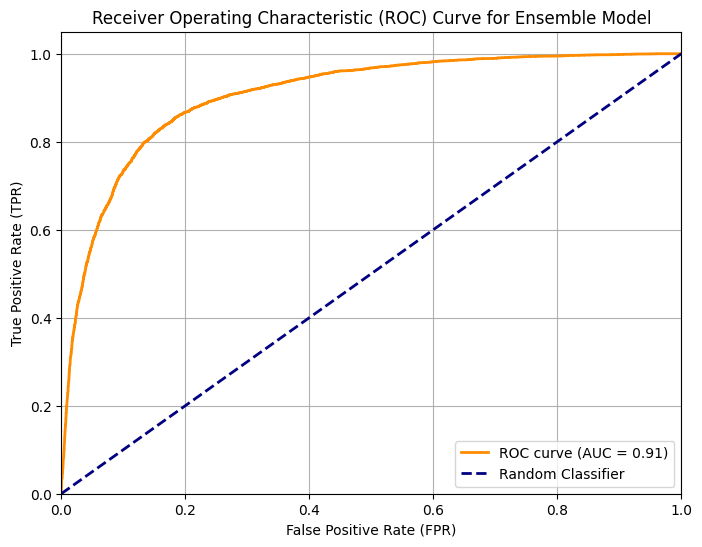

AUC (Area Under the Curve): 0.9062


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc
import os

# --- 配置预测文件路径 ---
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
# The ensemble model saves its output directly in GLOBAL_COMPARISON_DIR
model_output_dir = os.path.join(BASE_DIR, "outputs", "page1to3_timeaware_multibert_ensemble")
prediction_file_name = "ensemble_test_predictions.csv"
prediction_file_path = os.path.join(model_output_dir, prediction_file_name)


if not os.path.exists(prediction_file_path):
    print(f"错误：未找到文件 '{prediction_file_path}'。请检查路径是否正确或文件是否已生成。")
else:
    # 加载预测数据
    df_predictions = pd.read_csv(prediction_file_path)

    # 提取真实标签和预测概率
    # 对于集成模型，概率列名为 'ensemble_prob'
    y_true = df_predictions['y_true']
    y_prob = df_predictions['ensemble_prob']

    # 计算 ROC 曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # 绘制 ROC 曲线
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for Ensemble Model')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    print(f"AUC (Area Under the Curve): {roc_auc:.4f}")

In [ ]:
# =========================================================
# Simplified notebook/script version (tunable CE / focal + tunable class weight)
# Changes:
# 1) Refactored repeated logic into helpers
# 2) TITLE/BODY keyword matching uses boolean hit logic only
# 3) Date features keep quarter only
# 4) previous front page expanded to look back up to 30 days
# 5) Updated BODY keyword categories and BODY combos
# 6) Expanded TITLE keyword combos moderately
# 7) Supports switching between weighted CE and focal loss
# 8) Supports manual positive-class weight tuning
# =========================================================

import os
import re
import glob
import json
import random
import signal
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup


# =========================================================
# 0. Config
# =========================================================
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
RUN_ALL_MODELS = True
SINGLE_MODEL_KEY = "roberta_wwm_ext"
OUTPUT_SUFFIX = "simplified_boolkw_prev30d_qonly_ce_posw2"
RESUME_FROM_CHECKPOINT = False

MODEL_CONFIGS = {
    "roberta_wwm_ext": {
        "model_id": "hfl/chinese-roberta-wwm-ext",
        "model_tag": "chinese-roberta-wwm-ext",
        "display_name": "RoBERTa-wwm-ext",
    },
    "bert_base_chinese": {
        "model_id": "google-bert/bert-base-chinese",
        "model_tag": "bert-base-chinese",
        "display_name": "BERT base Chinese",
    },
    "chinese_bert_wwm_ext": {
        "model_id": "hfl/chinese-bert-wwm-ext",
        "model_tag": "chinese-bert-wwm-ext",
        "display_name": "Chinese BERT wwm-ext",
    },
}

RANDOM_SEED = 42
PAGE_COL = "scraped page number"
TEXT_COL = "title"
CONTENT_COL = "body"
DATE_COL = "published_at"
LABEL_COL = "labels"

TRAIN_SPLIT_FILENAME = "train_df.parquet"
VAL_SPLIT_FILENAME = "val_df 1.parquet"
TEST_SPLIT_FILENAME = "test_df 1.parquet"

MAX_LENGTH = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
WARMUP_RATIO = 0.1
EARLY_STOP_PATIENCE = 2
USE_GRADIENT_CLIPPING = True
MAX_GRAD_NORM = 1.0
USE_FIRST_LAST_SENTENCE = True
USE_TITLE_KEYWORDS = True
USE_BODY_KEYWORDS = True
USE_KEYWORD_INTERACTIONS = True
BODY_KEYWORD_MAX_CHARS = 1200
PREV_FRONT_LOOKBACK_DAYS = 30
SAVE_CHECKPOINT_EVERY_N_EPOCHS = 1
MAX_CHECKPOINTS_TO_KEEP = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Loss config
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 1.5
POS_CLASS_WEIGHT = 20.0


def sanitize_suffix(value: str) -> str:
    cleaned = re.sub(r"[^0-9A-Za-z._-]+", "-", str(value).strip())
    return cleaned.strip("-")


OUTPUT_SUFFIX = sanitize_suffix(OUTPUT_SUFFIX)
GLOBAL_COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "model_comparison_simplified_boolkw_prev30d_qonly_loss_tunable",
)
os.makedirs(GLOBAL_COMPARISON_DIR, exist_ok=True)


# =========================================================
# 1. Keywords
# =========================================================
TITLE_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "总书记", "国家主席", "中央军委主席",
        "李强", "赵乐际", "王沪宁", "蔡奇", "丁薛祥", "薛祥", "李希", "韩正",
        "李克强", "梁强", "阮富仲", "洪森", "苏林", "普京", "黄循财", "卢拉",
        "莫迪", "穆罕默德", "舒斯京", "拉马", "鲁托", "博沃", "欧尔", "莱恩", "桑切斯", "马克"
    ],
    "central_institutions": [
        "中共中央", "党中央", "中央政治局", "中央政治局常委", "中央政治局常委会", "中央军委",
        "国务院", "全国人大", "全国政协", "中共中央办公厅", "中央书记处",
        "中办国办", "中共中央国务院", "全军", "武警部队", "统一战线", "国务院令",
        "常委会", "常务委员会"
    ],
    "leadership_activities": [
        "主持召开", "主持", "出席", "会见", "接见", "视察", "考察", "调研",
        "重要讲话", "重要指示", "重要批示", "情况汇报", "工作汇报", "听取", "座谈",
        "看望", "致辞", "演讲", "主旨", "离京", "出访", "抵达", "回到",
        "春节前夕", "新年贺词", "团拜会", "预备会议", "常务会议", "全体会议",
        "闭幕式", "首发式", "开班式", "欢迎宴会", "晚宴", "出席会议", "隆重举行", "召开"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "唁电", "慰问电", "复信", "回信", "致信", "致电",
        "祝贺", "命令", "指示", "批示", "致以", "问候", "勉励", "祝福",
        "署名文章", "发表", "出版发行", "单行本", "读本", "英文版", "社论", "述评", "纪实"
    ],
    "political_meetings": [
        "中央政治局会议", "中央经济工作会议", "中央农村工作会议", "国务院常务会议",
        "全国两会", "全国人民代表大会", "中国人民政治协商会议", "峰会", "全会",
        "代表大会", "开幕会", "联组会", "小组会议", "会议议程", "十四五", "十五五"
    ],
    "diplomacy": [
        "国事访问", "非正式", "外事活动", "欢迎仪式", "欢迎宴会", "欢送", "送行"
    ],
    "policy_or_philosophy": [
        "强国建设", "民族复兴", "坚定信心", "奋发有为", "锲而不舍", "中国式现代化",
        "高质量发展", "改革开放", "共同富裕", "新质生产力", "优秀党员", "党性", "党纪", "论述"
    ],
    "military": [
        "军衔", "上将", "部队", "军队", "战士", "我军", "全军", "动员", "检阅", "分列式"
    ],
    "foreign_entities": [
        "越南共产党", "越共中央", "老挝人民革命党", "亚太经合组织", "欧盟委员会",
        "十国集团", "阿塞拜疆", "斯洛伐克", "斐济", "国王", "总统", "元首", "参议长",
        "财政部长", "国民议会", "参议院"
    ],
    "other_high_freq": [
        "火化", "遗体", "牵挂", "求是", "杂志", "专题学习", "述职", "连任", "就任",
        "学习", "研讨班", "会议精神", "贯彻落实"
    ]
}

BODY_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "蔡奇", "韩正", "薛祥", "王沪宁", "李希", "李强", "赵乐际",
        "彭丽媛", "普京", "莫迪", "阮富仲", "苏林", "梁强", "胡锦涛", "李克强"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "慰问电", "唁电", "回信", "致电", "祝贺",
        "命令", "致以", "就任", "勉励", "悼念", "沉痛", "火化", "遗像", "生前友好"
    ],
    "central_institutions": [
        "中共中央", "中央办公厅", "中央书记处", "中央政治局常委",
        "中央政治局常委会", "中央军委", "军委", "各级党委", "全国政协",
        "政协全国委员会", "政协常委会", "越南共产党", "越共中央", "武警部队"
    ],
    "state_places": [
        "北京人民大会堂", "人民大会堂", "中南海", "北京中南海",
        "北京钓鱼台国宾馆", "天安门广场", "主席台", "检阅台"
    ],
    "official_activities_discourse": [
        "陪同", "重要讲话", "特命", "诚挚", "团拜会", "党外人士", "主持", "会谈",
        "工作汇报", "情况汇报", "汇报会", "列席会议", "主持会议", "出席会议",
        "专题学习", "读书班", "欢迎仪式", "欢迎宴会", "欢送", "送行",
        "乘专机", "专机", "返京", "出京", "下榻", "红毯", "礼兵", "仪仗队",
        "军乐团", "鸣放", "礼炮", "国歌", "握手", "挥手致意", "接见", "十四五", "十五五"
    ],
    "Announcement_of_the_Passing_of_an_Important_Figure": [
        "火化", "悼念", "沉痛", "遗像", "生前友好"
    ],
}

TITLE_KEYWORD_COMBOS = [
    ("习近平", "重要讲话"),
    ("习近平", "重要指示"),
    ("习近平", "重要批示"),
    ("习近平", "贺信"),
    ("习近平", "回信"),
    ("习近平", "会见"),
    ("习近平", "主持召开"),
    ("中央政治局", "会议"),
    ("中共中央", "国务院"),
    ("中央军委", "习近平"),
    ("李强", "国务院"),
    ("赵乐际", "全国人大"),
    ("王沪宁", "全国政协"),
    ("强国建设", "民族复兴"),
    ("中国式现代化", "高质量发展"),
    ("欢迎仪式", "人民大会堂"),
    ("欢迎宴会", "人民大会堂"),
    ("国事访问", "习近平"),
    ("出访", "习近平"),
    ("专题学习", "习近平"),
    ("求是", "习近平"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
    ("中央军委", "重要讲话"),
    ("李强", "重要讲话"),
    ("欢迎宴会", "国事访问"),
]

BODY_KEYWORD_COMBOS = [
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("中央军委", "习近平"),
    ("中央军委", "重要讲话"),
    ("中共中央", "工作汇报"),
    ("中共中央", "重要讲话"),
    ("各级党委", "重要讲话"),
    ("李强", "重要讲话"),
    ("赵乐际", "重要讲话"),
    ("王沪宁", "重要讲话"),
    ("韩正", "重要讲话"),
    ("北京人民大会堂", "欢迎仪式"),
    ("人民大会堂", "欢迎宴会"),
    ("北京人民大会堂", "陪同"),
    ("人民大会堂", "陪同"),
    ("礼兵", "仪仗队"),
    ("专机", "返京"),
    ("祝贺", "致以"),
    ("诚挚", "祝贺"),
    ("回信", "重要讲话"),
    ("火化", "遗像"),
    ("唁电", "慰问电"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
]


# =========================================================
# 2. Utilities
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clean_text(x):
    return "" if pd.isna(x) else str(x).strip()


def ensure_model_snapshot(model_id, cache_dir):
    if os.path.isdir(cache_dir) and os.listdir(cache_dir):
        return cache_dir
    print(f"Downloading {model_id} -> {cache_dir}")
    snapshot_download(repo_id=model_id, local_dir=cache_dir, local_dir_use_symlinks=False)
    return cache_dir


def find_best_threshold_on_val(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_predictions(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}precision": precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall": recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}f1": f1_score(y_true, y_pred, zero_division=0),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics[f"{prefix}roc_auc"] = np.nan
    return metrics, y_pred


def print_metrics_dict(metrics):
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


def get_checkpoint_epoch(path):
    m = re.search(r"checkpoint_epoch_(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.alpha,
        )
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


# =========================================================
# 3. Features
# =========================================================
def extract_title_text_features(text: str):
    text = str(text) if not isinstance(text, str) else text
    length = max(len(text), 1)
    return {
        "title_text_length": min(len(text) / 100, 1.0),
        "title_has_number": float(any(c.isdigit() for c in text)),
        "title_has_colon": float("：" in text or ":" in text),
        "title_has_exclamation": float("！" in text or "!" in text),
        "title_has_question": float("？" in text or "?" in text),
        "title_has_parenthesis": float(any(ch in text for ch in ["（", "(", "）", ")"])),
        "title_digit_ratio": min(sum(c.isdigit() for c in text) / length, 0.5),
        "title_punctuation_ratio": min(sum(not c.isalnum() and not c.isspace() for c in text) / length, 0.5),
    }


def extract_first_last_sentence(text, max_len=128):
    if not isinstance(text, str) or not text:
        return "", ""
    sentences = [s.strip() for s in re.split(r"[。！？!?]+", text) if len(s.strip()) > 5]
    first = sentences[0] if sentences else ""
    last = sentences[-1] if len(sentences) > 1 else first
    return first[:max_len], last[:max_len]


def extract_quarter_features(df, date_col):
    dates = pd.to_datetime(df[date_col], errors="coerce") if date_col in df.columns else pd.Series([pd.NaT] * len(df), index=df.index)
    q = dates.dt.quarter.fillna(0)
    return pd.DataFrame(
        {
            "date_quarter_sin": np.sin(2 * np.pi * q / 4),
            "date_quarter_cos": np.cos(2 * np.pi * q / 4),
        },
        index=df.index,
    ).fillna(0.0)


def extract_keyword_features_bool(text, keyword_categories, keyword_combos, max_chars=None):
    text = "" if pd.isna(text) else str(text).strip()
    if max_chars is not None and max_chars > 0:
        text = text[:max_chars]

    out = {}
    if not text:
        for cat in keyword_categories:
            out[f"kw_{cat}_any"] = 0.0
        for i in range(len(keyword_combos)):
            out[f"kw_combo_{i}_both"] = 0.0
        out["kw_any_match"] = 0.0
        return out

    any_match = False
    for cat, kws in keyword_categories.items():
        hit = any(kw in text for kw in kws)
        out[f"kw_{cat}_any"] = float(hit)
        any_match = any_match or hit

    for i, (kw1, kw2) in enumerate(keyword_combos):
        both = (kw1 in text) and (kw2 in text)
        out[f"kw_combo_{i}_both"] = float(both)
        any_match = any_match or both

    out["kw_any_match"] = float(any_match)
    return out


def extract_keyword_features_batch(df, text_col, prefix, categories, combos, max_chars=None):
    if text_col not in df.columns:
        return pd.DataFrame(index=df.index)
    features = [
        extract_keyword_features_bool(text, categories, combos, max_chars=max_chars)
        for text in tqdm(df[text_col].fillna(""), desc=f"Extract {prefix} bool keyword")
    ]
    feat_df = pd.DataFrame(features, index=df.index).fillna(0.0)
    return feat_df.rename(columns=lambda c: f"{prefix}_{c}")


def build_keyword_interactions(title_kw_df, body_kw_df):
    out = pd.DataFrame(index=title_kw_df.index)
    shared = sorted(set(TITLE_KEYWORD_CATEGORIES).intersection(BODY_KEYWORD_CATEGORIES))
    for cat in shared:
        tc = f"title_kw_{cat}_any"
        bc = f"body_kw_{cat}_any"
        if tc in title_kw_df.columns and bc in body_kw_df.columns:
            out[f"inter_kw_{cat}_both"] = title_kw_df[tc].values * body_kw_df[bc].values
    if "title_kw_any_match" in title_kw_df.columns and "body_kw_any_match" in body_kw_df.columns:
        out["inter_kw_title_body_any"] = title_kw_df["title_kw_any_match"].values * body_kw_df["body_kw_any_match"].values
    return out.fillna(0.0)


# =========================================================
# 4. Dataset / Model
# =========================================================
class DualDataset(Dataset):
    def __init__(self, current_titles, prev_titles, labels, extra_features, tokenizer, first_sentences=None, last_sentences=None, max_length=128):
        self.current_titles = list(current_titles)
        self.prev_titles = list(prev_titles)
        self.labels = list(labels)
        self.extra_features = extra_features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.first_sentences = first_sentences
        self.last_sentences = last_sentences
        self.use_sentence_features = first_sentences is not None and last_sentences is not None

    def __len__(self):
        return len(self.current_titles)

    def _encode(self, text, max_length):
        enc = self.tokenizer(text, truncation=True, max_length=max_length, padding="max_length", return_tensors="pt")
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __getitem__(self, idx):
        cur_ids, cur_mask = self._encode(self.current_titles[idx], self.max_length)
        prev_ids, prev_mask = self._encode(self.prev_titles[idx] or "", self.max_length)
        item = {
            "current_input_ids": cur_ids,
            "current_attention_mask": cur_mask,
            "prev_input_ids": prev_ids,
            "prev_attention_mask": prev_mask,
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }
        if self.extra_features is not None:
            item["extra_features"] = torch.tensor(self.extra_features.iloc[idx].values.astype(np.float32), dtype=torch.float)
        if self.use_sentence_features:
            first_ids, first_mask = self._encode(self.first_sentences[idx] or "", self.max_length // 2)
            last_ids, last_mask = self._encode(self.last_sentences[idx] or "", self.max_length // 2)
            item.update({
                "first_input_ids": first_ids,
                "first_attention_mask": first_mask,
                "last_input_ids": last_ids,
                "last_attention_mask": last_mask,
            })
        return item


class DualInputClassifier(nn.Module):
    def __init__(self, encoder, extra_feature_dim, hidden_dim=256, dropout=0.3, use_sentence_features=False):
        super().__init__()
        self.encoder = encoder
        self.extra_feature_dim = extra_feature_dim
        self.use_sentence_features = use_sentence_features
        total_dim = encoder.config.hidden_size * 2 + extra_feature_dim
        if use_sentence_features:
            total_dim += encoder.config.hidden_size * 2
        self.total_dim = total_dim
        self.classifier = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def _cls(self, input_ids, attention_mask):
        return self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

    def forward(self, current_input_ids, current_attention_mask, prev_input_ids, prev_attention_mask, extra_features=None, first_input_ids=None, first_attention_mask=None, last_input_ids=None, last_attention_mask=None):
        embeds = [
            self._cls(current_input_ids, current_attention_mask),
            self._cls(prev_input_ids, prev_attention_mask),
        ]
        if self.use_sentence_features and first_input_ids is not None and last_input_ids is not None:
            embeds.extend([
                self._cls(first_input_ids, first_attention_mask),
                self._cls(last_input_ids, last_attention_mask),
            ])
        combined = torch.cat(embeds, dim=1)
        if extra_features is not None and self.extra_feature_dim > 0:
            combined = torch.cat([combined, extra_features], dim=1)
        return self.classifier(combined)


# =========================================================
# 5. Checkpoint Manager
# =========================================================
class CheckpointManager:
    def __init__(self, output_dir, best_model_filename, max_checkpoints=3):
        self.output_dir = output_dir
        self.best_model_filename = best_model_filename
        self.max_checkpoints = max_checkpoints
        self.checkpoint_dir = os.path.join(output_dir, "checkpoints")
        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def save(self, epoch, model, optimizer, scheduler, best_val_f1, best_epoch, best_threshold, patience_counter, history, is_best, extra_feature_dim, model_key, use_sentence_features):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "best_threshold": best_threshold,
            "patience_counter": patience_counter,
            "history": history,
            "extra_feature_dim": extra_feature_dim,
            "model_key": model_key,
            "use_sentence_features": use_sentence_features,
            "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
        }
        ckpt_path = os.path.join(self.checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save(ckpt, ckpt_path)
        if is_best:
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_f1": best_val_f1,
                    "best_threshold": best_threshold,
                    "extra_feature_dim": extra_feature_dim,
                    "model_key": model_key,
                    "use_sentence_features": use_sentence_features,
                    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
                },
                os.path.join(self.output_dir, self.best_model_filename),
            )
        self.cleanup()

    def cleanup(self):
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")), key=get_checkpoint_epoch)
        for old in checkpoints[:-self.max_checkpoints]:
            try:
                os.remove(old)
            except Exception:
                pass

    def load_latest(self, model, optimizer, scheduler, device, current_extra_feature_dim, current_model_key, current_use_sentence_features):
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")), key=get_checkpoint_epoch, reverse=True)
        for path in checkpoints:
            try:
                ckpt = torch.load(path, map_location=device)
                if int(ckpt.get("extra_feature_dim", -1)) != int(current_extra_feature_dim):
                    continue
                if ckpt.get("model_key") not in [None, current_model_key]:
                    continue
                if ckpt.get("use_sentence_features") not in [None, current_use_sentence_features]:
                    continue
                model.load_state_dict(ckpt["model_state_dict"])
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
                return ckpt
            except Exception:
                continue
        return None


class GracefulExiter:
    def __init__(self):
        self.should_exit = False
        signal.signal(signal.SIGINT, self.exit_gracefully)
        signal.signal(signal.SIGTERM, self.exit_gracefully)

    def exit_gracefully(self, signum, frame):
        print("\n⚠️ Received stop signal. Will stop after current epoch.")
        self.should_exit = True


# =========================================================
# 6. Data building
# =========================================================
def load_and_clean_split(path, split_name):
    df = pd.read_parquet(path).copy()
    df[PAGE_COL] = pd.to_numeric(df[PAGE_COL], errors="coerce")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[PAGE_COL, DATE_COL]).copy()
    df[PAGE_COL] = df[PAGE_COL].astype(int)
    df[TEXT_COL] = df[TEXT_COL].apply(clean_text)
    if CONTENT_COL in df.columns:
        df[CONTENT_COL] = df[CONTENT_COL].fillna("").astype(str)
    df = df[df[TEXT_COL].str.len() > 0].copy()
    df[LABEL_COL] = (df[PAGE_COL] == 1).astype(int)
    df["date_only"] = df[DATE_COL].dt.normalize()
    df["split"] = split_name
    return df


def build_prev_front_title(df, lookback_days=30):
    front_df = df.loc[df[PAGE_COL] == 1, ["date_only", TEXT_COL]].drop_duplicates(subset=["date_only"])
    front_map = dict(zip(front_df["date_only"], front_df[TEXT_COL]))
    prev_titles = []
    for d in df["date_only"]:
        found = ""
        for k in range(1, lookback_days + 1):
            cand = d - pd.Timedelta(days=k)
            if cand in front_map:
                found = front_map[cand]
                break
        prev_titles.append(found)
    return pd.Series(prev_titles, index=df.index)


def build_feature_table(df):
    title_feat = pd.DataFrame([extract_title_text_features(t) for t in tqdm(df[TEXT_COL], desc="Title text features")], index=df.index).fillna(0.0)

    keyword_parts = []
    title_kw = pd.DataFrame(index=df.index)
    body_kw = pd.DataFrame(index=df.index)

    if USE_TITLE_KEYWORDS:
        title_kw = extract_keyword_features_batch(df, TEXT_COL, "title", TITLE_KEYWORD_CATEGORIES, TITLE_KEYWORD_COMBOS)
        keyword_parts.append(title_kw)
    if USE_BODY_KEYWORDS:
        body_kw = extract_keyword_features_batch(df, CONTENT_COL, "body", BODY_KEYWORD_CATEGORIES, BODY_KEYWORD_COMBOS, max_chars=BODY_KEYWORD_MAX_CHARS)
        keyword_parts.append(body_kw)
    if USE_KEYWORD_INTERACTIONS and USE_TITLE_KEYWORDS and USE_BODY_KEYWORDS:
        keyword_parts.append(build_keyword_interactions(title_kw, body_kw))

    keyword_feat = pd.concat(keyword_parts, axis=1).fillna(0.0) if keyword_parts else pd.DataFrame(index=df.index)
    quarter_feat = extract_quarter_features(df, DATE_COL)
    return pd.concat([title_feat, keyword_feat, quarter_feat], axis=1).fillna(0.0)


def build_data_and_features(base_dir):
    paths = {
        "train": os.path.join(base_dir, TRAIN_SPLIT_FILENAME),
        "val": os.path.join(base_dir, VAL_SPLIT_FILENAME),
        "test": os.path.join(base_dir, TEST_SPLIT_FILENAME),
    }
    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} split not found: {path}")

    train_df = load_and_clean_split(paths["train"], "train")
    val_df = load_and_clean_split(paths["val"], "val")
    test_df = load_and_clean_split(paths["test"], "test")
    df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values(["date_only", PAGE_COL, TEXT_COL]).reset_index(drop=True)

    df["prev_front_title"] = build_prev_front_title(df, lookback_days=PREV_FRONT_LOOKBACK_DAYS).fillna("").apply(clean_text)

    first_last = None
    if USE_FIRST_LAST_SENTENCE and CONTENT_COL in df.columns:
        firsts, lasts = zip(*[extract_first_last_sentence(x) for x in tqdm(df[CONTENT_COL], desc="First/last sentence")])
        first_last = (pd.Series(firsts, index=df.index), pd.Series(lasts, index=df.index))

    extra_features_df = build_feature_table(df)

    split_idx = {s: df.index[df["split"] == s] for s in ["train", "val", "test"]}
    bundle = {
        "df": df,
        "train_df": df.loc[split_idx["train"]].copy().reset_index(drop=True),
        "val_df": df.loc[split_idx["val"]].copy().reset_index(drop=True),
        "test_df": df.loc[split_idx["test"]].copy().reset_index(drop=True),
        "train_extra": extra_features_df.loc[split_idx["train"]].reset_index(drop=True),
        "val_extra": extra_features_df.loc[split_idx["val"]].reset_index(drop=True),
        "test_extra": extra_features_df.loc[split_idx["test"]].reset_index(drop=True),
        "extra_features_df": extra_features_df,
    }
    if first_last is not None:
        first_series, last_series = first_last
        for split in ["train", "val", "test"]:
            idx = split_idx[split]
            bundle[f"{split}_first"] = first_series.loc[idx].tolist()
            bundle[f"{split}_last"] = last_series.loc[idx].tolist()
    else:
        for split in ["train", "val", "test"]:
            bundle[f"{split}_first"] = None
            bundle[f"{split}_last"] = None

    print("\nFeature columns:")
    print(extra_features_df.columns.tolist())
    print(f"Extra feature dim: {extra_features_df.shape[1]}")
    print(f"Prev-front coverage ({PREV_FRONT_LOOKBACK_DAYS}d): {(df['prev_front_title'].str.len() > 0).mean():.2%}")
    return bundle


# =========================================================
# 7. Train / eval helpers
# =========================================================
def move_optional_tensor(batch, key):
    x = batch.get(key, None)
    return x.to(DEVICE) if x is not None else None


def run_eval(model, data_loader, criterion):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )
            labels = batch["labels"].to(DEVICE)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / max(len(data_loader), 1), np.array(all_labels), np.array(all_probs)


def save_curves(history_df, best_epoch, title, path):
    if len(history_df) == 0:
        return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")
    plt.title(f"{title}: Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["val_f1@best_thr"], marker="o", label="val_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="s", label="val_macro_f1")
    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")
    plt.title(f"{title}: Validation F1")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def build_and_save_summary_matrix(model_key, model_id, model_display_name, y_test, test_pred, test_prob, best_threshold, best_epoch, output_dir, final_summary_filename):
    label_precision, label_recall, label_f1, label_support = precision_recall_fscore_support(y_test, test_pred, labels=[0, 1], zero_division=0)
    macro_precision = precision_score(y_test, test_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, test_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, test_pred)
    try:
        roc_auc = roc_auc_score(y_test, test_prob)
    except Exception:
        roc_auc = np.nan

    summary = pd.DataFrame([
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "label_0_negative", "n_samples": int(label_support[0]), "precision": float(label_precision[0]), "recall": float(label_recall[0]), "f1": float(label_f1[0]), "accuracy": np.nan, "roc_auc": np.nan, "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "label_1_positive", "n_samples": int(label_support[1]), "precision": float(label_precision[1]), "recall": float(label_recall[1]), "f1": float(label_f1[1]), "accuracy": np.nan, "roc_auc": np.nan, "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "macro_avg", "n_samples": int(np.sum(label_support)), "precision": float(macro_precision), "recall": float(macro_recall), "f1": float(macro_f1), "accuracy": float(accuracy), "roc_auc": float(roc_auc), "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
    ])
    out_path = os.path.join(output_dir, final_summary_filename)
    summary.to_csv(out_path, index=False, encoding="utf-8-sig")
    return summary


# =========================================================
# 8. Main training loop for one model
# =========================================================
def run_one_model(model_key, data_bundle):
    set_seed(RANDOM_SEED)
    cfg = MODEL_CONFIGS[model_key]
    model_id, model_tag, model_display_name = cfg["model_id"], cfg["model_tag"], cfg["display_name"]
    body_flag = "bodykw" if USE_BODY_KEYWORDS else "no_bodykw"
    inter_flag = "inter" if USE_KEYWORD_INTERACTIONS else "no_inter"
    loss_flag = "focal" if USE_FOCAL_LOSS else "ce"

    run_name = f"title_finetune_{model_tag}_fixedsplit_prevfront{PREV_FRONT_LOOKBACK_DAYS}d_boolkw_{body_flag}_{inter_flag}_{loss_flag}"
    if OUTPUT_SUFFIX:
        run_name = f"{run_name}_{OUTPUT_SUFFIX}"
    output_dir = os.path.join(BASE_DIR, "outputs", run_name)
    os.makedirs(output_dir, exist_ok=True)

    local_model_path = ensure_model_snapshot(model_id, os.path.join(BASE_DIR, "hf_models", model_tag))
    tokenizer = AutoTokenizer.from_pretrained(local_model_path, local_files_only=True)

    train_df, val_df, test_df = data_bundle["train_df"], data_bundle["val_df"], data_bundle["test_df"]
    train_extra, val_extra, test_extra = data_bundle["train_extra"], data_bundle["val_extra"], data_bundle["test_extra"]

    def build_dataset(df, extra, split):
        return DualDataset(
            df[TEXT_COL].tolist(),
            df["prev_front_title"].tolist(),
            df[LABEL_COL].tolist(),
            extra,
            tokenizer,
            data_bundle[f"{split}_first"],
            data_bundle[f"{split}_last"],
            MAX_LENGTH,
        )

    train_loader = DataLoader(build_dataset(train_df, train_extra, "train"), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(build_dataset(val_df, val_extra, "val"), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(build_dataset(test_df, test_extra, "test"), batch_size=BATCH_SIZE, shuffle=False)

    base_encoder = AutoModel.from_pretrained(local_model_path, use_safetensors=False, local_files_only=True)
    sample_batch = next(iter(train_loader))
    extra_feature_dim = int(sample_batch["extra_features"].shape[1]) if "extra_features" in sample_batch else 0

    model = DualInputClassifier(base_encoder, extra_feature_dim, hidden_dim=256, dropout=0.3, use_sentence_features=USE_FIRST_LAST_SENTENCE).to(DEVICE)

    num_neg = int((train_df[LABEL_COL] == 0).sum())
    num_pos = int((train_df[LABEL_COL] == 1).sum())

    print(f"Train negatives: {num_neg}")
    print(f"Train positives: {num_pos}")
    print(f"Raw neg/pos ratio: {num_neg / max(num_pos, 1):.4f}")
    print(f"Configured positive class weight: {POS_CLASS_WEIGHT}")
    print(f"Use focal loss: {USE_FOCAL_LOSS}")
    print(f"Focal gamma: {FOCAL_GAMMA}")

    class_weights = torch.tensor([1.0, POS_CLASS_WEIGHT], dtype=torch.float).to(DEVICE)

    if USE_FOCAL_LOSS:
        criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA, reduction="mean")
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW([
        {"params": model.encoder.parameters(), "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY},
        {"params": model.classifier.parameters(), "lr": LEARNING_RATE * 5.0, "weight_decay": WEIGHT_DECAY},
    ])
    total_steps = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS)) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    artifact_stem = f"{model_tag}_fixedsplit_prevfront{PREV_FRONT_LOOKBACK_DAYS}d_boolkw_{body_flag}_{inter_flag}_{loss_flag}"
    best_model_filename = f"best_model_{artifact_stem}.pt"
    ckpt_manager = CheckpointManager(output_dir, best_model_filename, MAX_CHECKPOINTS_TO_KEEP)
    exiter = GracefulExiter()

    history = {k: [] for k in ["epoch", "train_loss", "val_loss", "val_f1@best_thr", "val_precision@best_thr", "val_recall@best_thr", "val_threshold", "val_macro_precision", "val_macro_recall", "val_macro_f1"]}
    best_val_f1, best_epoch, best_threshold, patience_counter, start_epoch = -1, -1, 0.5, 0, 1

    if RESUME_FROM_CHECKPOINT:
        ckpt = ckpt_manager.load_latest(model, optimizer, scheduler, DEVICE, extra_feature_dim, model_key, USE_FIRST_LAST_SENTENCE)
        if ckpt is not None:
            start_epoch = ckpt["epoch"] + 1
            best_val_f1 = ckpt["best_val_f1"]
            best_epoch = ckpt["best_epoch"]
            best_threshold = ckpt["best_threshold"]
            patience_counter = ckpt["patience_counter"]
            history = ckpt["history"]

    last_epoch_ran = start_epoch - 1
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        if exiter.should_exit:
            break
        last_epoch_ran = epoch
        model.train()
        optimizer.zero_grad()
        total_train_loss = 0.0

        for step, batch in enumerate(tqdm(train_loader, desc=f"Train {model_key} epoch {epoch}", leave=False)):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )
            labels = batch["labels"].to(DEVICE)
            loss = criterion(logits, labels) / GRAD_ACCUM_STEPS
            loss.backward()
            total_train_loss += loss.item() * GRAD_ACCUM_STEPS

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                if USE_GRADIENT_CLIPPING:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        avg_train_loss = total_train_loss / max(len(train_loader), 1)
        val_loss, y_val, val_prob = run_eval(model, val_loader, criterion)
        val_threshold, _ = find_best_threshold_on_val(y_val, val_prob)
        val_metrics, val_pred = evaluate_predictions(y_val, val_prob, val_threshold, prefix="val_")
        val_report = classification_report(y_val, val_pred, output_dict=True, zero_division=0)

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1@best_thr"].append(val_metrics["val_f1"])
        history["val_precision@best_thr"].append(val_metrics["val_precision"])
        history["val_recall@best_thr"].append(val_metrics["val_recall"])
        history["val_threshold"].append(val_threshold)
        history["val_macro_precision"].append(val_report["macro avg"]["precision"])
        history["val_macro_recall"].append(val_report["macro avg"]["recall"])
        history["val_macro_f1"].append(val_report["macro avg"]["f1-score"])

        is_best = val_metrics["val_f1"] > best_val_f1
        if is_best:
            best_val_f1 = val_metrics["val_f1"]
            best_epoch = epoch
            best_threshold = val_threshold
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"\nEpoch {epoch}")
        print(f"train_loss={avg_train_loss:.4f}  val_loss={val_loss:.4f}  best_thr={val_threshold:.4f}")
        print_metrics_dict(val_metrics)
        print(classification_report(y_val, val_pred, digits=4, zero_division=0))

        if epoch % SAVE_CHECKPOINT_EVERY_N_EPOCHS == 0:
            ckpt_manager.save(epoch, model, optimizer, scheduler, best_val_f1, best_epoch, best_threshold, patience_counter, history, is_best, extra_feature_dim, model_key, USE_FIRST_LAST_SENTENCE)
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(output_dir, f"training_history_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")
    save_curves(history_df, best_epoch, model_display_name, os.path.join(output_dir, f"training_curves_{artifact_stem}.png"))

    best_model_path = os.path.join(output_dir, best_model_filename)
    if not os.path.exists(best_model_path):
        torch.save(
            {
                "epoch": best_epoch if best_epoch != -1 else last_epoch_ran,
                "model_state_dict": model.state_dict(),
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "model_key": model_key,
                "use_sentence_features": USE_FIRST_LAST_SENTENCE,
            },
            best_model_path,
        )

    pd.DataFrame([
        {
            "model_key": model_key,
            "model_id": model_id,
            "model_display_name": model_display_name,
            "num_epochs_completed": last_epoch_ran,
            "best_epoch": best_epoch,
            "best_val_f1": best_val_f1,
            "best_threshold": best_threshold,
            "extra_feature_dim": extra_feature_dim,
            "use_fixed_external_splits": True,
            "train_split_filename": TRAIN_SPLIT_FILENAME,
            "val_split_filename": VAL_SPLIT_FILENAME,
            "test_split_filename": TEST_SPLIT_FILENAME,
            "use_title_keywords": USE_TITLE_KEYWORDS,
            "use_body_keywords": USE_BODY_KEYWORDS,
            "use_keyword_interactions": USE_KEYWORD_INTERACTIONS,
            "body_keyword_max_chars": BODY_KEYWORD_MAX_CHARS,
            "prev_front_lookback_days": PREV_FRONT_LOOKBACK_DAYS,
            "quarter_only_date_features": True,
            "use_focal_loss": USE_FOCAL_LOSS,
            "focal_gamma": FOCAL_GAMMA,
            "pos_class_weight": POS_CLASS_WEIGHT,
            "train_neg_count": num_neg,
            "train_pos_count": num_pos,
            "raw_neg_pos_ratio": float(num_neg / max(num_pos, 1)),
            "title_keyword_categories": json.dumps(list(TITLE_KEYWORD_CATEGORIES.keys()), ensure_ascii=False),
            "body_keyword_categories": json.dumps(list(BODY_KEYWORD_CATEGORIES.keys()), ensure_ascii=False),
            "training_completed": not exiter.should_exit,
        }
    ]).to_csv(os.path.join(output_dir, f"training_summary_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")

    best_ckpt = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model_state_dict"])
    test_loss, y_test, test_prob = run_eval(model, test_loader, criterion)
    test_metrics, test_pred = evaluate_predictions(y_test, test_prob, best_ckpt["best_threshold"], prefix="test_")
    print(f"\nTest loss: {test_loss:.4f}")
    print_metrics_dict(test_metrics)
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    test_result_df = test_df.copy()
    test_result_df["y_true"] = y_test
    test_result_df["pred_prob"] = test_prob
    test_result_df["pred_label"] = test_pred
    test_result_df.to_csv(os.path.join(output_dir, f"test_predictions_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")

    summary_df = build_and_save_summary_matrix(
        model_key=model_key,
        model_id=model_id,
        model_display_name=model_display_name,
        y_test=y_test,
        test_pred=test_pred,
        test_prob=test_prob,
        best_threshold=best_ckpt["best_threshold"],
        best_epoch=best_ckpt["epoch"],
        output_dir=output_dir,
        final_summary_filename=f"final_summary_matrix_{artifact_stem}.csv",
    )

    del model, base_encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary_df


# =========================================================
# 9. Main
# =========================================================
def main():
    set_seed(RANDOM_SEED)
    print("\nBuilding shared data/features...")
    data_bundle = build_data_and_features(BASE_DIR)

    model_keys = list(MODEL_CONFIGS.keys()) if RUN_ALL_MODELS else [SINGLE_MODEL_KEY]
    all_summary_dfs = [run_one_model(model_key, data_bundle) for model_key in model_keys]

    final_comparison_df = pd.concat(all_summary_dfs, ignore_index=True)
    long_path = os.path.join(GLOBAL_COMPARISON_DIR, "final_model_comparison_long.csv")
    final_comparison_df.to_csv(long_path, index=False, encoding="utf-8-sig")

    macro_rows = final_comparison_df[final_comparison_df["subset"] == "macro_avg"].copy()
    pos_rows = final_comparison_df[final_comparison_df["subset"] == "label_1_positive"].copy()
    neg_rows = final_comparison_df[final_comparison_df["subset"] == "label_0_negative"].copy()

    wide_rows = []
    for model_key in model_keys:
        macro_match = macro_rows[macro_rows["model_key"] == model_key]
        pos_match = pos_rows[pos_rows["model_key"] == model_key]
        neg_match = neg_rows[neg_rows["model_key"] == model_key]
        if len(macro_match) == 0 or len(pos_match) == 0 or len(neg_match) == 0:
            continue
        macro, pos, neg = macro_match.iloc[0], pos_match.iloc[0], neg_match.iloc[0]
        wide_rows.append(
            {
                "model_key": model_key,
                "model_display_name": macro["model_display_name"],
                "negative_precision": neg["precision"],
                "negative_recall": neg["recall"],
                "negative_f1": neg["f1"],
                "positive_precision": pos["precision"],
                "positive_recall": pos["recall"],
                "positive_f1": pos["f1"],
                "macro_precision": macro["precision"],
                "macro_recall": macro["recall"],
                "macro_f1": macro["f1"],
                "accuracy": macro["accuracy"],
                "roc_auc": macro["roc_auc"],
                "best_threshold": macro["best_threshold"],
                "best_epoch": macro["best_epoch"],
            }
        )

    display_df = pd.DataFrame(wide_rows)
    wide_path = os.path.join(GLOBAL_COMPARISON_DIR, "final_model_comparison_wide.csv")
    display_df.to_csv(wide_path, index=False, encoding="utf-8-sig")

    print("\nFinal model comparison")
    print(display_df.to_string(index=False))
    print(f"\nSaved long: {long_path}")
    print(f"Saved wide: {wide_path}")


if __name__ == "__main__":
    main()



Building shared data/features...


Extract body bool keyword: 100%|██████████| 86279/86279 [00:06<00:00, 14341.69it/s]



Feature columns:
['title_text_length', 'title_has_number', 'title_has_colon', 'title_has_exclamation', 'title_has_question', 'title_has_parenthesis', 'title_digit_ratio', 'title_punctuation_ratio', 'title_kw_top_leadership_any', 'title_kw_central_institutions_any', 'title_kw_leadership_activities_any', 'title_kw_official_messages_any', 'title_kw_political_meetings_any', 'title_kw_diplomacy_any', 'title_kw_policy_or_philosophy_any', 'title_kw_military_any', 'title_kw_foreign_entities_any', 'title_kw_other_high_freq_any', 'title_kw_combo_0_both', 'title_kw_combo_1_both', 'title_kw_combo_2_both', 'title_kw_combo_3_both', 'title_kw_combo_4_both', 'title_kw_combo_5_both', 'title_kw_combo_6_both', 'title_kw_combo_7_both', 'title_kw_combo_8_both', 'title_kw_combo_9_both', 'title_kw_combo_10_both', 'title_kw_combo_11_both', 'title_kw_combo_12_both', 'title_kw_combo_13_both', 'title_kw_combo_14_both', 'title_kw_combo_15_both', 'title_kw_combo_16_both', 'title_kw_combo_17_both', 'title_kw_combo

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


Test loss: 0.7968
test_accuracy: 0.9022
test_precision: 0.4644
test_recall: 0.7109
test_f1: 0.5618
test_macro_precision: 0.7175
test_macro_recall: 0.8158
test_macro_f1: 0.7534
test_roc_auc: 0.9238
              precision    recall  f1-score   support

           0     0.9705    0.9207    0.9450     15741
           1     0.4644    0.7109    0.5618      1522

    accuracy                         0.9022     17263
   macro avg     0.7175    0.8158    0.7534     17263
weighted avg     0.9259    0.9022    0.9112     17263



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/hf_models/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train negatives: 47195
Train positives: 4565
Raw neg/pos ratio: 10.3384
Configured positive class weight: 20.0
Use focal loss: True
Focal gamma: 1.5


Train bert_base_chinese epoch 1:  15%|█▍        | 235/1618 [07:39<44:56,  1.95s/it]

In [ ]:
# =========================================================
# Simplified notebook/script version (updated + focal loss)
# Changes:
# 1) Refactored repeated logic into helpers
# 2) TITLE/BODY keyword matching uses boolean hit logic only
# 3) Date features keep quarter only
# 4) previous front page expanded to look back up to 30 days
# 5) Updated BODY keyword categories and BODY combos
# 6) Expanded TITLE keyword combos moderately
# 7) Replaced weighted CE with Focal Loss
# =========================================================

import os
import re
import glob
import json
import random
import signal
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup


# =========================================================
# 0. Config
# =========================================================
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
RUN_ALL_MODELS = True
SINGLE_MODEL_KEY = "roberta_wwm_ext"
OUTPUT_SUFFIX = "simplified_boolkw_prev30d_qonly_focal_v1"
RESUME_FROM_CHECKPOINT = False

MODEL_CONFIGS = {
    "roberta_wwm_ext": {
        "model_id": "hfl/chinese-roberta-wwm-ext",
        "model_tag": "chinese-roberta-wwm-ext",
        "display_name": "RoBERTa-wwm-ext",
    },
    "bert_base_chinese": {
        "model_id": "google-bert/bert-base-chinese",
        "model_tag": "bert-base-chinese",
        "display_name": "BERT base Chinese",
    },
    "chinese_bert_wwm_ext": {
        "model_id": "hfl/chinese-bert-wwm-ext",
        "model_tag": "chinese-bert-wwm-ext",
        "display_name": "Chinese BERT wwm-ext",
    },
}

RANDOM_SEED = 42
PAGE_COL = "scraped page number"
TEXT_COL = "title"
CONTENT_COL = "body"
DATE_COL = "published_at"
LABEL_COL = "labels"

TRAIN_SPLIT_FILENAME = "train_df.parquet"
VAL_SPLIT_FILENAME = "val_df 1.parquet"
TEST_SPLIT_FILENAME = "test_df 1.parquet"

MAX_LENGTH = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
WARMUP_RATIO = 0.1
EARLY_STOP_PATIENCE = 2
USE_GRADIENT_CLIPPING = True
MAX_GRAD_NORM = 1.0
USE_FIRST_LAST_SENTENCE = True
USE_TITLE_KEYWORDS = True
USE_BODY_KEYWORDS = True
USE_KEYWORD_INTERACTIONS = True
BODY_KEYWORD_MAX_CHARS = 1200
PREV_FRONT_LOOKBACK_DAYS = 30
SAVE_CHECKPOINT_EVERY_N_EPOCHS = 1
MAX_CHECKPOINTS_TO_KEEP = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Focal loss config
FOCAL_GAMMA = 2.0


def sanitize_suffix(value: str) -> str:
    cleaned = re.sub(r"[^0-9A-Za-z._-]+", "-", str(value).strip())
    return cleaned.strip("-")


OUTPUT_SUFFIX = sanitize_suffix(OUTPUT_SUFFIX)
GLOBAL_COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "model_comparison_simplified_boolkw_prev30d_qonly_focal",
)
os.makedirs(GLOBAL_COMPARISON_DIR, exist_ok=True)


# =========================================================
# 1. Keywords
# =========================================================
TITLE_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "总书记", "国家主席", "中央军委主席",
        "李强", "赵乐际", "王沪宁", "蔡奇", "丁薛祥", "薛祥", "李希", "韩正",
        "李克强", "梁强", "阮富仲", "洪森", "苏林", "普京", "黄循财", "卢拉",
        "莫迪", "穆罕默德", "舒斯京", "拉马", "鲁托", "博沃", "欧尔", "莱恩", "桑切斯", "马克"
    ],
    "central_institutions": [
        "中共中央", "党中央", "中央政治局", "中央政治局常委", "中央政治局常委会", "中央军委",
        "国务院", "全国人大", "全国政协", "中共中央办公厅", "中央书记处",
        "中办国办", "中共中央国务院", "全军", "武警部队", "统一战线", "国务院令",
        "常委会", "常务委员会"
    ],
    "leadership_activities": [
        "主持召开", "主持", "出席", "会见", "接见", "视察", "考察", "调研",
        "重要讲话", "重要指示", "重要批示", "情况汇报", "工作汇报", "听取", "座谈",
        "看望", "致辞", "演讲", "主旨", "离京", "出访", "抵达", "回到",
        "春节前夕", "新年贺词", "团拜会", "预备会议", "常务会议", "全体会议",
        "闭幕式", "首发式", "开班式", "欢迎宴会", "晚宴", "出席会议", "隆重举行", "召开"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "唁电", "慰问电", "复信", "回信", "致信", "致电",
        "祝贺", "命令", "指示", "批示", "致以", "问候", "勉励", "祝福",
        "署名文章", "发表", "出版发行", "单行本", "读本", "英文版", "社论", "述评", "纪实"
    ],
    "political_meetings": [
        "中央政治局会议", "中央经济工作会议", "中央农村工作会议", "国务院常务会议",
        "全国两会", "全国人民代表大会", "中国人民政治协商会议", "峰会", "全会",
        "代表大会", "开幕会", "联组会", "小组会议", "会议议程", "十四五", "十五五"
    ],
    "diplomacy": [
        "国事访问", "非正式", "外事活动", "欢迎仪式", "欢迎宴会", "欢送", "送行"
    ],
    "policy_or_philosophy": [
        "强国建设", "民族复兴", "坚定信心", "奋发有为", "锲而不舍", "中国式现代化",
        "高质量发展", "改革开放", "共同富裕", "新质生产力", "优秀党员", "党性", "党纪", "论述"
    ],
    "military": [
        "军衔", "上将", "部队", "军队", "战士", "我军", "全军", "动员", "检阅", "分列式"
    ],
    "foreign_entities": [
        "越南共产党", "越共中央", "老挝人民革命党", "亚太经合组织", "欧盟委员会",
        "十国集团", "阿塞拜疆", "斯洛伐克", "斐济", "国王", "总统", "元首", "参议长",
        "财政部长", "国民议会", "参议院"
    ],
    "other_high_freq": [
        "火化", "遗体", "牵挂", "求是", "杂志", "专题学习", "述职", "连任", "就任",
        "学习", "研讨班", "会议精神", "贯彻落实"
    ]
}

BODY_KEYWORD_CATEGORIES = {
    "top_leadership": [
        "习近平", "蔡奇", "韩正", "薛祥", "王沪宁", "李希", "李强", "赵乐际",
        "彭丽媛", "普京", "莫迪", "阮富仲", "苏林", "梁强", "胡锦涛", "李克强"
    ],
    "official_messages": [
        "贺信", "贺电", "致贺", "慰问电", "唁电", "回信", "致电", "祝贺",
        "命令", "致以", "就任", "勉励", "悼念", "沉痛", "火化", "遗像", "生前友好"
    ],
    "central_institutions": [
        "中共中央", "中央办公厅", "中央书记处", "中央政治局常委",
        "中央政治局常委会", "中央军委", "军委", "各级党委", "全国政协",
        "政协全国委员会", "政协常委会", "越南共产党", "越共中央", "武警部队"
    ],
    "state_places": [
        "北京人民大会堂", "人民大会堂", "中南海", "北京中南海",
        "北京钓鱼台国宾馆", "天安门广场", "主席台", "检阅台"
    ],
    "official_activities_discourse": [
        "陪同", "重要讲话", "特命", "诚挚", "团拜会", "党外人士", "主持", "会谈",
        "工作汇报", "情况汇报", "汇报会", "列席会议", "主持会议", "出席会议",
        "专题学习", "读书班", "欢迎仪式", "欢迎宴会", "欢送", "送行",
        "乘专机", "专机", "返京", "出京", "下榻", "红毯", "礼兵", "仪仗队",
        "军乐团", "鸣放", "礼炮", "国歌", "握手", "挥手致意", "接见", "十四五", "十五五"
    ],
    "Announcement_of_the_Passing_of_an_Important_Figure": [
        "火化", "悼念", "沉痛", "遗像", "生前友好"
    ],
}

TITLE_KEYWORD_COMBOS = [
    ("习近平", "重要讲话"),
    ("习近平", "重要指示"),
    ("习近平", "重要批示"),
    ("习近平", "贺信"),
    ("习近平", "回信"),
    ("习近平", "会见"),
    ("习近平", "主持召开"),
    ("中央政治局", "会议"),
    ("中共中央", "国务院"),
    ("中央军委", "习近平"),
    ("李强", "国务院"),
    ("赵乐际", "全国人大"),
    ("王沪宁", "全国政协"),
    ("强国建设", "民族复兴"),
    ("中国式现代化", "高质量发展"),
    ("欢迎仪式", "人民大会堂"),
    ("欢迎宴会", "人民大会堂"),
    ("国事访问", "习近平"),
    ("出访", "习近平"),
    ("专题学习", "习近平"),
    ("求是", "习近平"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
    ("中央军委", "重要讲话"),
    ("李强", "重要讲话"),
    ("欢迎宴会", "国事访问"),
]

BODY_KEYWORD_COMBOS = [
    ("中央政治局常委", "韩正"),
    ("中央政治局常委", "蔡奇"),
    ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"),
    ("中央军委", "习近平"),
    ("中央军委", "重要讲话"),
    ("中共中央", "工作汇报"),
    ("中共中央", "重要讲话"),
    ("各级党委", "重要讲话"),
    ("李强", "重要讲话"),
    ("赵乐际", "重要讲话"),
    ("王沪宁", "重要讲话"),
    ("韩正", "重要讲话"),
    ("北京人民大会堂", "欢迎仪式"),
    ("人民大会堂", "欢迎宴会"),
    ("北京人民大会堂", "陪同"),
    ("人民大会堂", "陪同"),
    ("礼兵", "仪仗队"),
    ("专机", "返京"),
    ("祝贺", "致以"),
    ("诚挚", "祝贺"),
    ("回信", "重要讲话"),
    ("火化", "遗像"),
    ("唁电", "慰问电"),
    ("越共中央", "苏林"),
    ("越南共产党", "阮富仲"),
]


# =========================================================
# 2. Utilities
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clean_text(x):
    return "" if pd.isna(x) else str(x).strip()


def ensure_model_snapshot(model_id, cache_dir):
    if os.path.isdir(cache_dir) and os.listdir(cache_dir):
        return cache_dir
    print(f"Downloading {model_id} -> {cache_dir}")
    snapshot_download(repo_id=model_id, local_dir=cache_dir, local_dir_use_symlinks=False)
    return cache_dir


def find_best_threshold_on_val(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_predictions(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}precision": precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall": recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}f1": f1_score(y_true, y_pred, zero_division=0),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics[f"{prefix}roc_auc"] = np.nan
    return metrics, y_pred


def print_metrics_dict(metrics):
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


def get_checkpoint_epoch(path):
    m = re.search(r"checkpoint_epoch_(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.alpha,
        )
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


# =========================================================
# 3. Features
# =========================================================
def extract_title_text_features(text: str):
    text = str(text) if not isinstance(text, str) else text
    length = max(len(text), 1)
    return {
        "title_text_length": min(len(text) / 100, 1.0),
        "title_has_number": float(any(c.isdigit() for c in text)),
        "title_has_colon": float("：" in text or ":" in text),
        "title_has_exclamation": float("！" in text or "!" in text),
        "title_has_question": float("？" in text or "?" in text),
        "title_has_parenthesis": float(any(ch in text for ch in ["（", "(", "）", ")"])),
        "title_digit_ratio": min(sum(c.isdigit() for c in text) / length, 0.5),
        "title_punctuation_ratio": min(sum(not c.isalnum() and not c.isspace() for c in text) / length, 0.5),
    }


def extract_first_last_sentence(text, max_len=128):
    if not isinstance(text, str) or not text:
        return "", ""
    sentences = [s.strip() for s in re.split(r"[。！？!?]+", text) if len(s.strip()) > 5]
    first = sentences[0] if sentences else ""
    last = sentences[-1] if len(sentences) > 1 else first
    return first[:max_len], last[:max_len]


def extract_quarter_features(df, date_col):
    dates = pd.to_datetime(df[date_col], errors="coerce") if date_col in df.columns else pd.Series([pd.NaT] * len(df), index=df.index)
    q = dates.dt.quarter.fillna(0)
    return pd.DataFrame(
        {
            "date_quarter_sin": np.sin(2 * np.pi * q / 4),
            "date_quarter_cos": np.cos(2 * np.pi * q / 4),
        },
        index=df.index,
    ).fillna(0.0)


def extract_keyword_features_bool(text, keyword_categories, keyword_combos, max_chars=None):
    text = "" if pd.isna(text) else str(text).strip()
    if max_chars is not None and max_chars > 0:
        text = text[:max_chars]

    out = {}
    if not text:
        for cat in keyword_categories:
            out[f"kw_{cat}_any"] = 0.0
        for i in range(len(keyword_combos)):
            out[f"kw_combo_{i}_both"] = 0.0
        out["kw_any_match"] = 0.0
        return out

    any_match = False
    for cat, kws in keyword_categories.items():
        hit = any(kw in text for kw in kws)
        out[f"kw_{cat}_any"] = float(hit)
        any_match = any_match or hit

    for i, (kw1, kw2) in enumerate(keyword_combos):
        both = (kw1 in text) and (kw2 in text)
        out[f"kw_combo_{i}_both"] = float(both)
        any_match = any_match or both

    out["kw_any_match"] = float(any_match)
    return out


def extract_keyword_features_batch(df, text_col, prefix, categories, combos, max_chars=None):
    if text_col not in df.columns:
        return pd.DataFrame(index=df.index)
    features = [
        extract_keyword_features_bool(text, categories, combos, max_chars=max_chars)
        for text in tqdm(df[text_col].fillna(""), desc=f"Extract {prefix} bool keyword")
    ]
    feat_df = pd.DataFrame(features, index=df.index).fillna(0.0)
    return feat_df.rename(columns=lambda c: f"{prefix}_{c}")


def build_keyword_interactions(title_kw_df, body_kw_df):
    out = pd.DataFrame(index=title_kw_df.index)
    shared = sorted(set(TITLE_KEYWORD_CATEGORIES).intersection(BODY_KEYWORD_CATEGORIES))
    for cat in shared:
        tc = f"title_kw_{cat}_any"
        bc = f"body_kw_{cat}_any"
        if tc in title_kw_df.columns and bc in body_kw_df.columns:
            out[f"inter_kw_{cat}_both"] = title_kw_df[tc].values * body_kw_df[bc].values
    if "title_kw_any_match" in title_kw_df.columns and "body_kw_any_match" in body_kw_df.columns:
        out["inter_kw_title_body_any"] = title_kw_df["title_kw_any_match"].values * body_kw_df["body_kw_any_match"].values
    return out.fillna(0.0)


# =========================================================
# 4. Dataset / Model
# =========================================================
class DualDataset(Dataset):
    def __init__(self, current_titles, prev_titles, labels, extra_features, tokenizer, first_sentences=None, last_sentences=None, max_length=128):
        self.current_titles = list(current_titles)
        self.prev_titles = list(prev_titles)
        self.labels = list(labels)
        self.extra_features = extra_features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.first_sentences = first_sentences
        self.last_sentences = last_sentences
        self.use_sentence_features = first_sentences is not None and last_sentences is not None

    def __len__(self):
        return len(self.current_titles)

    def _encode(self, text, max_length):
        enc = self.tokenizer(text, truncation=True, max_length=max_length, padding="max_length", return_tensors="pt")
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __getitem__(self, idx):
        cur_ids, cur_mask = self._encode(self.current_titles[idx], self.max_length)
        prev_ids, prev_mask = self._encode(self.prev_titles[idx] or "", self.max_length)
        item = {
            "current_input_ids": cur_ids,
            "current_attention_mask": cur_mask,
            "prev_input_ids": prev_ids,
            "prev_attention_mask": prev_mask,
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }
        if self.extra_features is not None:
            item["extra_features"] = torch.tensor(self.extra_features.iloc[idx].values.astype(np.float32), dtype=torch.float)
        if self.use_sentence_features:
            first_ids, first_mask = self._encode(self.first_sentences[idx] or "", self.max_length // 2)
            last_ids, last_mask = self._encode(self.last_sentences[idx] or "", self.max_length // 2)
            item.update({
                "first_input_ids": first_ids,
                "first_attention_mask": first_mask,
                "last_input_ids": last_ids,
                "last_attention_mask": last_mask,
            })
        return item


class DualInputClassifier(nn.Module):
    def __init__(self, encoder, extra_feature_dim, hidden_dim=256, dropout=0.3, use_sentence_features=False):
        super().__init__()
        self.encoder = encoder
        self.extra_feature_dim = extra_feature_dim
        self.use_sentence_features = use_sentence_features
        total_dim = encoder.config.hidden_size * 2 + extra_feature_dim
        if use_sentence_features:
            total_dim += encoder.config.hidden_size * 2
        self.total_dim = total_dim
        self.classifier = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def _cls(self, input_ids, attention_mask):
        return self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

    def forward(self, current_input_ids, current_attention_mask, prev_input_ids, prev_attention_mask, extra_features=None, first_input_ids=None, first_attention_mask=None, last_input_ids=None, last_attention_mask=None):
        embeds = [
            self._cls(current_input_ids, current_attention_mask),
            self._cls(prev_input_ids, prev_attention_mask),
        ]
        if self.use_sentence_features and first_input_ids is not None and last_input_ids is not None:
            embeds.extend([
                self._cls(first_input_ids, first_attention_mask),
                self._cls(last_input_ids, last_attention_mask),
            ])
        combined = torch.cat(embeds, dim=1)
        if extra_features is not None and self.extra_feature_dim > 0:
            combined = torch.cat([combined, extra_features], dim=1)
        return self.classifier(combined)


# =========================================================
# 5. Checkpoint Manager
# =========================================================
class CheckpointManager:
    def __init__(self, output_dir, best_model_filename, max_checkpoints=3):
        self.output_dir = output_dir
        self.best_model_filename = best_model_filename
        self.max_checkpoints = max_checkpoints
        self.checkpoint_dir = os.path.join(output_dir, "checkpoints")
        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def save(self, epoch, model, optimizer, scheduler, best_val_f1, best_epoch, best_threshold, patience_counter, history, is_best, extra_feature_dim, model_key, use_sentence_features):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "best_threshold": best_threshold,
            "patience_counter": patience_counter,
            "history": history,
            "extra_feature_dim": extra_feature_dim,
            "model_key": model_key,
            "use_sentence_features": use_sentence_features,
            "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
        }
        ckpt_path = os.path.join(self.checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save(ckpt, ckpt_path)
        if is_best:
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_f1": best_val_f1,
                    "best_threshold": best_threshold,
                    "extra_feature_dim": extra_feature_dim,
                    "model_key": model_key,
                    "use_sentence_features": use_sentence_features,
                    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
                },
                os.path.join(self.output_dir, self.best_model_filename),
            )
        self.cleanup()

    def cleanup(self):
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")), key=get_checkpoint_epoch)
        for old in checkpoints[:-self.max_checkpoints]:
            try:
                os.remove(old)
            except Exception:
                pass

    def load_latest(self, model, optimizer, scheduler, device, current_extra_feature_dim, current_model_key, current_use_sentence_features):
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")), key=get_checkpoint_epoch, reverse=True)
        for path in checkpoints:
            try:
                ckpt = torch.load(path, map_location=device)
                if int(ckpt.get("extra_feature_dim", -1)) != int(current_extra_feature_dim):
                    continue
                if ckpt.get("model_key") not in [None, current_model_key]:
                    continue
                if ckpt.get("use_sentence_features") not in [None, current_use_sentence_features]:
                    continue
                model.load_state_dict(ckpt["model_state_dict"])
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
                return ckpt
            except Exception:
                continue
        return None


class GracefulExiter:
    def __init__(self):
        self.should_exit = False
        signal.signal(signal.SIGINT, self.exit_gracefully)
        signal.signal(signal.SIGTERM, self.exit_gracefully)

    def exit_gracefully(self, signum, frame):
        print("\n⚠️ Received stop signal. Will stop after current epoch.")
        self.should_exit = True


# =========================================================
# 6. Data building
# =========================================================
def load_and_clean_split(path, split_name):
    df = pd.read_parquet(path).copy()
    df[PAGE_COL] = pd.to_numeric(df[PAGE_COL], errors="coerce")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[PAGE_COL, DATE_COL]).copy()
    df[PAGE_COL] = df[PAGE_COL].astype(int)
    df[TEXT_COL] = df[TEXT_COL].apply(clean_text)
    if CONTENT_COL in df.columns:
        df[CONTENT_COL] = df[CONTENT_COL].fillna("").astype(str)
    df = df[df[TEXT_COL].str.len() > 0].copy()
    df[LABEL_COL] = (df[PAGE_COL] == 1).astype(int)
    df["date_only"] = df[DATE_COL].dt.normalize()
    df["split"] = split_name
    return df


def build_prev_front_title(df, lookback_days=30):
    front_df = df.loc[df[PAGE_COL] == 1, ["date_only", TEXT_COL]].drop_duplicates(subset=["date_only"])
    front_map = dict(zip(front_df["date_only"], front_df[TEXT_COL]))
    prev_titles = []
    for d in df["date_only"]:
        found = ""
        for k in range(1, lookback_days + 1):
            cand = d - pd.Timedelta(days=k)
            if cand in front_map:
                found = front_map[cand]
                break
        prev_titles.append(found)
    return pd.Series(prev_titles, index=df.index)


def build_feature_table(df):
    title_feat = pd.DataFrame([extract_title_text_features(t) for t in tqdm(df[TEXT_COL], desc="Title text features")], index=df.index).fillna(0.0)

    keyword_parts = []
    title_kw = pd.DataFrame(index=df.index)
    body_kw = pd.DataFrame(index=df.index)

    if USE_TITLE_KEYWORDS:
        title_kw = extract_keyword_features_batch(df, TEXT_COL, "title", TITLE_KEYWORD_CATEGORIES, TITLE_KEYWORD_COMBOS)
        keyword_parts.append(title_kw)
    if USE_BODY_KEYWORDS:
        body_kw = extract_keyword_features_batch(df, CONTENT_COL, "body", BODY_KEYWORD_CATEGORIES, BODY_KEYWORD_COMBOS, max_chars=BODY_KEYWORD_MAX_CHARS)
        keyword_parts.append(body_kw)
    if USE_KEYWORD_INTERACTIONS and USE_TITLE_KEYWORDS and USE_BODY_KEYWORDS:
        keyword_parts.append(build_keyword_interactions(title_kw, body_kw))

    keyword_feat = pd.concat(keyword_parts, axis=1).fillna(0.0) if keyword_parts else pd.DataFrame(index=df.index)
    quarter_feat = extract_quarter_features(df, DATE_COL)
    return pd.concat([title_feat, keyword_feat, quarter_feat], axis=1).fillna(0.0)


def build_data_and_features(base_dir):
    paths = {
        "train": os.path.join(base_dir, TRAIN_SPLIT_FILENAME),
        "val": os.path.join(base_dir, VAL_SPLIT_FILENAME),
        "test": os.path.join(base_dir, TEST_SPLIT_FILENAME),
    }
    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} split not found: {path}")

    train_df = load_and_clean_split(paths["train"], "train")
    val_df = load_and_clean_split(paths["val"], "val")
    test_df = load_and_clean_split(paths["test"], "test")
    df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values(["date_only", PAGE_COL, TEXT_COL]).reset_index(drop=True)

    df["prev_front_title"] = build_prev_front_title(df, lookback_days=PREV_FRONT_LOOKBACK_DAYS).fillna("").apply(clean_text)

    first_last = None
    if USE_FIRST_LAST_SENTENCE and CONTENT_COL in df.columns:
        firsts, lasts = zip(*[extract_first_last_sentence(x) for x in tqdm(df[CONTENT_COL], desc="First/last sentence")])
        first_last = (pd.Series(firsts, index=df.index), pd.Series(lasts, index=df.index))

    extra_features_df = build_feature_table(df)

    split_idx = {s: df.index[df["split"] == s] for s in ["train", "val", "test"]}
    bundle = {
        "df": df,
        "train_df": df.loc[split_idx["train"]].copy().reset_index(drop=True),
        "val_df": df.loc[split_idx["val"]].copy().reset_index(drop=True),
        "test_df": df.loc[split_idx["test"]].copy().reset_index(drop=True),
        "train_extra": extra_features_df.loc[split_idx["train"]].reset_index(drop=True),
        "val_extra": extra_features_df.loc[split_idx["val"]].reset_index(drop=True),
        "test_extra": extra_features_df.loc[split_idx["test"]].reset_index(drop=True),
        "extra_features_df": extra_features_df,
    }
    if first_last is not None:
        first_series, last_series = first_last
        for split in ["train", "val", "test"]:
            idx = split_idx[split]
            bundle[f"{split}_first"] = first_series.loc[idx].tolist()
            bundle[f"{split}_last"] = last_series.loc[idx].tolist()
    else:
        for split in ["train", "val", "test"]:
            bundle[f"{split}_first"] = None
            bundle[f"{split}_last"] = None

    print("\nFeature columns:")
    print(extra_features_df.columns.tolist())
    print(f"Extra feature dim: {extra_features_df.shape[1]}")
    print(f"Prev-front coverage ({PREV_FRONT_LOOKBACK_DAYS}d): {(df['prev_front_title'].str.len() > 0).mean():.2%}")
    return bundle


# =========================================================
# 7. Train / eval helpers
# =========================================================
def move_optional_tensor(batch, key):
    x = batch.get(key, None)
    return x.to(DEVICE) if x is not None else None


def run_eval(model, data_loader, criterion):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )
            labels = batch["labels"].to(DEVICE)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / max(len(data_loader), 1), np.array(all_labels), np.array(all_probs)


def save_curves(history_df, best_epoch, title, path):
    if len(history_df) == 0:
        return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")
    plt.title(f"{title}: Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["val_f1@best_thr"], marker="o", label="val_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="s", label="val_macro_f1")
    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")
    plt.title(f"{title}: Validation F1")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def build_and_save_summary_matrix(model_key, model_id, model_display_name, y_test, test_pred, test_prob, best_threshold, best_epoch, output_dir, final_summary_filename):
    label_precision, label_recall, label_f1, label_support = precision_recall_fscore_support(y_test, test_pred, labels=[0, 1], zero_division=0)
    macro_precision = precision_score(y_test, test_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, test_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, test_pred)
    try:
        roc_auc = roc_auc_score(y_test, test_prob)
    except Exception:
        roc_auc = np.nan

    summary = pd.DataFrame([
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "label_0_negative", "n_samples": int(label_support[0]), "precision": float(label_precision[0]), "recall": float(label_recall[0]), "f1": float(label_f1[0]), "accuracy": np.nan, "roc_auc": np.nan, "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "label_1_positive", "n_samples": int(label_support[1]), "precision": float(label_precision[1]), "recall": float(label_recall[1]), "f1": float(label_f1[1]), "accuracy": np.nan, "roc_auc": np.nan, "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "macro_avg", "n_samples": int(np.sum(label_support)), "precision": float(macro_precision), "recall": float(macro_recall), "f1": float(macro_f1), "accuracy": float(accuracy), "roc_auc": float(roc_auc), "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
    ])
    out_path = os.path.join(output_dir, final_summary_filename)
    summary.to_csv(out_path, index=False, encoding="utf-8-sig")
    return summary


# =========================================================
# 8. Main training loop for one model
# =========================================================
def run_one_model(model_key, data_bundle):
    set_seed(RANDOM_SEED)
    cfg = MODEL_CONFIGS[model_key]
    model_id, model_tag, model_display_name = cfg["model_id"], cfg["model_tag"], cfg["display_name"]
    body_flag = "bodykw" if USE_BODY_KEYWORDS else "no_bodykw"
    inter_flag = "inter" if USE_KEYWORD_INTERACTIONS else "no_inter"
    run_name = f"title_finetune_{model_tag}_fixedsplit_prevfront{PREV_FRONT_LOOKBACK_DAYS}d_boolkw_{body_flag}_{inter_flag}"
    if OUTPUT_SUFFIX:
        run_name = f"{run_name}_{OUTPUT_SUFFIX}"
    output_dir = os.path.join(BASE_DIR, "outputs", run_name)
    os.makedirs(output_dir, exist_ok=True)

    local_model_path = ensure_model_snapshot(model_id, os.path.join(BASE_DIR, "hf_models", model_tag))
    tokenizer = AutoTokenizer.from_pretrained(local_model_path, local_files_only=True)

    train_df, val_df, test_df = data_bundle["train_df"], data_bundle["val_df"], data_bundle["test_df"]
    train_extra, val_extra, test_extra = data_bundle["train_extra"], data_bundle["val_extra"], data_bundle["test_extra"]

    def build_dataset(df, extra, split):
        return DualDataset(
            df[TEXT_COL].tolist(),
            df["prev_front_title"].tolist(),
            df[LABEL_COL].tolist(),
            extra,
            tokenizer,
            data_bundle[f"{split}_first"],
            data_bundle[f"{split}_last"],
            MAX_LENGTH,
        )

    train_loader = DataLoader(build_dataset(train_df, train_extra, "train"), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(build_dataset(val_df, val_extra, "val"), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(build_dataset(test_df, test_extra, "test"), batch_size=BATCH_SIZE, shuffle=False)

    base_encoder = AutoModel.from_pretrained(local_model_path, use_safetensors=False, local_files_only=True)
    sample_batch = next(iter(train_loader))
    extra_feature_dim = int(sample_batch["extra_features"].shape[1]) if "extra_features" in sample_batch else 0

    model = DualInputClassifier(base_encoder, extra_feature_dim, hidden_dim=256, dropout=0.3, use_sentence_features=USE_FIRST_LAST_SENTENCE).to(DEVICE)

    num_neg = int((train_df[LABEL_COL] == 0).sum())
    num_pos = int((train_df[LABEL_COL] == 1).sum())
    class_weights = torch.tensor([1.0, num_neg / max(num_pos, 1)], dtype=torch.float).to(DEVICE)
    criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA, reduction="mean")

    optimizer = torch.optim.AdamW([
        {"params": model.encoder.parameters(), "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY},
        {"params": model.classifier.parameters(), "lr": LEARNING_RATE * 5.0, "weight_decay": WEIGHT_DECAY},
    ])
    total_steps = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS)) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    artifact_stem = f"{model_tag}_fixedsplit_prevfront{PREV_FRONT_LOOKBACK_DAYS}d_boolkw_{body_flag}_{inter_flag}"
    best_model_filename = f"best_model_{artifact_stem}.pt"
    ckpt_manager = CheckpointManager(output_dir, best_model_filename, MAX_CHECKPOINTS_TO_KEEP)
    exiter = GracefulExiter()

    history = {k: [] for k in ["epoch", "train_loss", "val_loss", "val_f1@best_thr", "val_precision@best_thr", "val_recall@best_thr", "val_threshold", "val_macro_precision", "val_macro_recall", "val_macro_f1"]}
    best_val_f1, best_epoch, best_threshold, patience_counter, start_epoch = -1, -1, 0.5, 0, 1

    if RESUME_FROM_CHECKPOINT:
        ckpt = ckpt_manager.load_latest(model, optimizer, scheduler, DEVICE, extra_feature_dim, model_key, USE_FIRST_LAST_SENTENCE)
        if ckpt is not None:
            start_epoch = ckpt["epoch"] + 1
            best_val_f1 = ckpt["best_val_f1"]
            best_epoch = ckpt["best_epoch"]
            best_threshold = ckpt["best_threshold"]
            patience_counter = ckpt["patience_counter"]
            history = ckpt["history"]

    last_epoch_ran = start_epoch - 1
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        if exiter.should_exit:
            break
        last_epoch_ran = epoch
        model.train()
        optimizer.zero_grad()
        total_train_loss = 0.0

        for step, batch in enumerate(tqdm(train_loader, desc=f"Train {model_key} epoch {epoch}", leave=False)):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )
            labels = batch["labels"].to(DEVICE)
            loss = criterion(logits, labels) / GRAD_ACCUM_STEPS
            loss.backward()
            total_train_loss += loss.item() * GRAD_ACCUM_STEPS

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                if USE_GRADIENT_CLIPPING:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        avg_train_loss = total_train_loss / max(len(train_loader), 1)
        val_loss, y_val, val_prob = run_eval(model, val_loader, criterion)
        val_threshold, _ = find_best_threshold_on_val(y_val, val_prob)
        val_metrics, val_pred = evaluate_predictions(y_val, val_prob, val_threshold, prefix="val_")
        val_report = classification_report(y_val, val_pred, output_dict=True, zero_division=0)

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1@best_thr"].append(val_metrics["val_f1"])
        history["val_precision@best_thr"].append(val_metrics["val_precision"])
        history["val_recall@best_thr"].append(val_metrics["val_recall"])
        history["val_threshold"].append(val_threshold)
        history["val_macro_precision"].append(val_report["macro avg"]["precision"])
        history["val_macro_recall"].append(val_report["macro avg"]["recall"])
        history["val_macro_f1"].append(val_report["macro avg"]["f1-score"])

        is_best = val_metrics["val_f1"] > best_val_f1
        if is_best:
            best_val_f1 = val_metrics["val_f1"]
            best_epoch = epoch
            best_threshold = val_threshold
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"\nEpoch {epoch}")
        print(f"train_loss={avg_train_loss:.4f}  val_loss={val_loss:.4f}  best_thr={val_threshold:.4f}")
        print_metrics_dict(val_metrics)
        print(classification_report(y_val, val_pred, digits=4, zero_division=0))

        if epoch % SAVE_CHECKPOINT_EVERY_N_EPOCHS == 0:
            ckpt_manager.save(epoch, model, optimizer, scheduler, best_val_f1, best_epoch, best_threshold, patience_counter, history, is_best, extra_feature_dim, model_key, USE_FIRST_LAST_SENTENCE)
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(output_dir, f"training_history_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")
    save_curves(history_df, best_epoch, model_display_name, os.path.join(output_dir, f"training_curves_{artifact_stem}.png"))

    best_model_path = os.path.join(output_dir, best_model_filename)
    if not os.path.exists(best_model_path):
        torch.save(
            {
                "epoch": best_epoch if best_epoch != -1 else last_epoch_ran,
                "model_state_dict": model.state_dict(),
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "model_key": model_key,
                "use_sentence_features": USE_FIRST_LAST_SENTENCE,
            },
            best_model_path,
        )

    pd.DataFrame([
        {
            "model_key": model_key,
            "model_id": model_id,
            "model_display_name": model_display_name,
            "num_epochs_completed": last_epoch_ran,
            "best_epoch": best_epoch,
            "best_val_f1": best_val_f1,
            "best_threshold": best_threshold,
            "extra_feature_dim": extra_feature_dim,
            "use_fixed_external_splits": True,
            "train_split_filename": TRAIN_SPLIT_FILENAME,
            "val_split_filename": VAL_SPLIT_FILENAME,
            "test_split_filename": TEST_SPLIT_FILENAME,
            "use_title_keywords": USE_TITLE_KEYWORDS,
            "use_body_keywords": USE_BODY_KEYWORDS,
            "use_keyword_interactions": USE_KEYWORD_INTERACTIONS,
            "body_keyword_max_chars": BODY_KEYWORD_MAX_CHARS,
            "prev_front_lookback_days": PREV_FRONT_LOOKBACK_DAYS,
            "quarter_only_date_features": True,
            "focal_gamma": FOCAL_GAMMA,
            "title_keyword_categories": json.dumps(list(TITLE_KEYWORD_CATEGORIES.keys()), ensure_ascii=False),
            "body_keyword_categories": json.dumps(list(BODY_KEYWORD_CATEGORIES.keys()), ensure_ascii=False),
            "training_completed": not exiter.should_exit,
        }
    ]).to_csv(os.path.join(output_dir, f"training_summary_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")

    best_ckpt = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model_state_dict"])
    test_loss, y_test, test_prob = run_eval(model, test_loader, criterion)
    test_metrics, test_pred = evaluate_predictions(y_test, test_prob, best_ckpt["best_threshold"], prefix="test_")
    print(f"\nTest loss: {test_loss:.4f}")
    print_metrics_dict(test_metrics)
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    test_result_df = test_df.copy()
    test_result_df["y_true"] = y_test
    test_result_df["pred_prob"] = test_prob
    test_result_df["pred_label"] = test_pred
    test_result_df.to_csv(os.path.join(output_dir, f"test_predictions_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")

    summary_df = build_and_save_summary_matrix(
        model_key=model_key,
        model_id=model_id,
        model_display_name=model_display_name,
        y_test=y_test,
        test_pred=test_pred,
        test_prob=test_prob,
        best_threshold=best_ckpt["best_threshold"],
        best_epoch=best_ckpt["epoch"],
        output_dir=output_dir,
        final_summary_filename=f"final_summary_matrix_{artifact_stem}.csv",
    )

    del model, base_encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary_df


# =========================================================
# 9. Main
# =========================================================
def main():
    set_seed(RANDOM_SEED)
    print("\nBuilding shared data/features...")
    data_bundle = build_data_and_features(BASE_DIR)

    model_keys = list(MODEL_CONFIGS.keys()) if RUN_ALL_MODELS else [SINGLE_MODEL_KEY]
    all_summary_dfs = [run_one_model(model_key, data_bundle) for model_key in model_keys]

    final_comparison_df = pd.concat(all_summary_dfs, ignore_index=True)
    long_path = os.path.join(GLOBAL_COMPARISON_DIR, "final_model_comparison_long.csv")
    final_comparison_df.to_csv(long_path, index=False, encoding="utf-8-sig")

    macro_rows = final_comparison_df[final_comparison_df["subset"] == "macro_avg"].copy()
    pos_rows = final_comparison_df[final_comparison_df["subset"] == "label_1_positive"].copy()
    neg_rows = final_comparison_df[final_comparison_df["subset"] == "label_0_negative"].copy()

    wide_rows = []
    for model_key in model_keys:
        macro_match = macro_rows[macro_rows["model_key"] == model_key]
        pos_match = pos_rows[pos_rows["model_key"] == model_key]
        neg_match = neg_rows[neg_rows["model_key"] == model_key]
        if len(macro_match) == 0 or len(pos_match) == 0 or len(neg_match) == 0:
            continue
        macro, pos, neg = macro_match.iloc[0], pos_match.iloc[0], neg_match.iloc[0]
        wide_rows.append(
            {
                "model_key": model_key,
                "model_display_name": macro["model_display_name"],
                "negative_precision": neg["precision"],
                "negative_recall": neg["recall"],
                "negative_f1": neg["f1"],
                "positive_precision": pos["precision"],
                "positive_recall": pos["recall"],
                "positive_f1": pos["f1"],
                "macro_precision": macro["precision"],
                "macro_recall": macro["recall"],
                "macro_f1": macro["f1"],
                "accuracy": macro["accuracy"],
                "roc_auc": macro["roc_auc"],
                "best_threshold": macro["best_threshold"],
                "best_epoch": macro["best_epoch"],
            }
        )

    display_df = pd.DataFrame(wide_rows)
    wide_path = os.path.join(GLOBAL_COMPARISON_DIR, "final_model_comparison_wide.csv")
    display_df.to_csv(wide_path, index=False, encoding="utf-8-sig")

    print("\nFinal model comparison")
    print(display_df.to_string(index=False))
    print(f"\nSaved long: {long_path}")
    print(f"Saved wide: {wide_path}")


if __name__ == "__main__":
    main()



Building shared data/features...


Extract body bool keyword: 100%|██████████| 86279/86279 [00:06<00:00, 12862.51it/s]



Feature columns:
['title_text_length', 'title_has_number', 'title_has_colon', 'title_has_exclamation', 'title_has_question', 'title_has_parenthesis', 'title_digit_ratio', 'title_punctuation_ratio', 'title_kw_top_leadership_any', 'title_kw_central_institutions_any', 'title_kw_leadership_activities_any', 'title_kw_official_messages_any', 'title_kw_political_meetings_any', 'title_kw_diplomacy_any', 'title_kw_policy_or_philosophy_any', 'title_kw_military_any', 'title_kw_foreign_entities_any', 'title_kw_other_high_freq_any', 'title_kw_combo_0_both', 'title_kw_combo_1_both', 'title_kw_combo_2_both', 'title_kw_combo_3_both', 'title_kw_combo_4_both', 'title_kw_combo_5_both', 'title_kw_combo_6_both', 'title_kw_combo_7_both', 'title_kw_combo_8_both', 'title_kw_combo_9_both', 'title_kw_combo_10_both', 'title_kw_combo_11_both', 'title_kw_combo_12_both', 'title_kw_combo_13_both', 'title_kw_combo_14_both', 'title_kw_combo_15_both', 'title_kw_combo_16_both', 'title_kw_combo_17_both', 'title_kw_combo

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


Epoch 2
train_loss=0.2917  val_loss=0.4282  best_thr=0.7039
val_accuracy: 0.9069
val_precision: 0.4826
val_recall: 0.7635
val_f1: 0.5913
val_macro_precision: 0.7292
val_macro_recall: 0.8421
val_macro_f1: 0.7694
val_roc_auc: 0.9323
              precision    recall  f1-score   support

           0     0.9758    0.9208    0.9475     15734
           1     0.4826    0.7635    0.5913      1522

    accuracy                         0.9069     17256
   macro avg     0.7292    0.8421    0.7694     17256
weighted avg     0.9323    0.9069    0.9161     17256




Epoch 3
train_loss=0.2353  val_loss=0.5442  best_thr=0.7862
val_accuracy: 0.9137
val_precision: 0.5079
val_recall: 0.6767
val_f1: 0.5803
val_macro_precision: 0.7378
val_macro_recall: 0.8067
val_macro_f1: 0.7661
val_roc_auc: 0.9230
              precision    recall  f1-score   support

           0     0.9677    0.9366    0.9519     15734
           1     0.5079    0.6767    0.5803      1522

    accuracy                         0.9137     17256
   macro avg     0.7378    0.8067    0.7661     17256
weighted avg     0.9271    0.9137    0.9191     17256




Epoch 4
train_loss=0.1965  val_loss=0.7884  best_thr=0.6327
val_accuracy: 0.9175
val_precision: 0.5250
val_recall: 0.6820
val_f1: 0.5933
val_macro_precision: 0.7467
val_macro_recall: 0.8112
val_macro_f1: 0.7737
val_roc_auc: 0.9245
              precision    recall  f1-score   support

           0     0.9683    0.9403    0.9541     15734
           1     0.5250    0.6820    0.5933      1522

    accuracy                         0.9175     17256
   macro avg     0.7467    0.8112    0.7737     17256
weighted avg     0.9292    0.9175    0.9223     17256




Epoch 5
train_loss=0.1614  val_loss=0.9532  best_thr=0.6687
val_accuracy: 0.9156
val_precision: 0.5166
val_recall: 0.6629
val_f1: 0.5807
val_macro_precision: 0.7416
val_macro_recall: 0.8015
val_macro_f1: 0.7669
val_roc_auc: 0.9146
              precision    recall  f1-score   support

           0     0.9665    0.9400    0.9531     15734
           1     0.5166    0.6629    0.5807      1522

    accuracy                         0.9156     17256
   macro avg     0.7416    0.8015    0.7669     17256
weighted avg     0.9268    0.9156    0.9202     17256



Train bert_base_chinese epoch 6:  52%|█████▏    | 847/1618 [30:58<28:13,  2.20s/it]

In [ ]:
# Simplified notebook/script version
# Changes:
# 1) Refactored repeated logic into small helpers
# 2) TITLE/BODY keyword matching uses boolean hit logic only
# 3) Date features keep quarter only
# 4) previous front page expanded to look back up to 30 days
# 5) Keeps fixed train/val/test parquet split workflow

import os
import re
import glob
import json
import random
import signal
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup


# =========================================================
# 0. Config
# =========================================================
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
RUN_ALL_MODELS = True
SINGLE_MODEL_KEY = "roberta_wwm_ext"
OUTPUT_SUFFIX = "simplified_boolkw_prev30d_qonly_v1"
RESUME_FROM_CHECKPOINT = False

MODEL_CONFIGS = {
    "roberta_wwm_ext": {
        "model_id": "hfl/chinese-roberta-wwm-ext",
        "model_tag": "chinese-roberta-wwm-ext",
        "display_name": "RoBERTa-wwm-ext",
    },
    "bert_base_chinese": {
        "model_id": "google-bert/bert-base-chinese",
        "model_tag": "bert-base-chinese",
        "display_name": "BERT base Chinese",
    },
    "chinese_bert_wwm_ext": {
        "model_id": "hfl/chinese-bert-wwm-ext",
        "model_tag": "chinese-bert-wwm-ext",
        "display_name": "Chinese BERT wwm-ext",
    },
}

RANDOM_SEED = 42
PAGE_COL = "scraped page number"
TEXT_COL = "title"
CONTENT_COL = "body"
DATE_COL = "published_at"
LABEL_COL = "labels"

TRAIN_SPLIT_FILENAME = "train_df.parquet"
VAL_SPLIT_FILENAME = "val_df 1.parquet"
TEST_SPLIT_FILENAME = "test_df 1.parquet"

MAX_LENGTH = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
WARMUP_RATIO = 0.1
EARLY_STOP_PATIENCE = 2
USE_GRADIENT_CLIPPING = True
MAX_GRAD_NORM = 1.0
USE_FIRST_LAST_SENTENCE = True
USE_TITLE_KEYWORDS = True
USE_BODY_KEYWORDS = Ture
USE_KEYWORD_INTERACTIONS = True
BODY_KEYWORD_MAX_CHARS = 1200
PREV_FRONT_LOOKBACK_DAYS = 30
SAVE_CHECKPOINT_EVERY_N_EPOCHS = 1
MAX_CHECKPOINTS_TO_KEEP = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def sanitize_suffix(value: str) -> str:
    cleaned = re.sub(r"[^0-9A-Za-z._-]+", "-", str(value).strip())
    return cleaned.strip("-")


OUTPUT_SUFFIX = sanitize_suffix(OUTPUT_SUFFIX)
GLOBAL_COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "model_comparison_simplified_boolkw_prev30d_qonly",
)
os.makedirs(GLOBAL_COMPARISON_DIR, exist_ok=True)


TITLE_KEYWORD_CATEGORIES = {
    # ================= 原有词 + 新增的外国领导人姓名 =================
    "top_leadership": [
        # 原有
        "习近平", "总书记", "国家主席", "中央军委主席",
        "李强", "赵乐际", "王沪宁", "蔡奇", "丁薛祥", "李希", "韩正",
        # 新增
        "李克强",          # 你给的词表中有
        "薛祥",            # 你给的词表中有（丁薛祥的简称）
        "梁强", "阮富仲", "洪森", "苏林", "普京", "黄循财", "卢拉",
        "穆罕默德","卡耶夫","舒斯京","拉马","福萨","多夫","鲁托","博沃",欧尔","莱恩","桑切斯","马克"        # 你给的词表中有，作为一个完整词保留
    ],

    # =============== 原有 + 新增的中央/国家机构及军事单位 ===============
    "central_institutions": [
        # 原有
        "中共中央", "党中央", "中央政治局", "中央政治局常委", "中央军委",
        "国务院", "全国人大", "全国政协",
        # 新增
        "中共中央办公厅", "中共中央国务院", "中办国办", "中央书记处",
        "全军", "武警部队", "统一战线", "国务院令", "审计", "常委会",
        "常务委员会",
    ],

    # =============== 原有 + 新增的领导活动、会议、仪式 ===============
    "leadership_activities": [
        # 原有
        "主持召开", "主持", "出席", "会见", "接见", "视察", "考察", "调研",
        "重要讲话", "重要指示", "重要批示", "情况汇报",
        # 新增
        "工作汇报", "听取", "座谈", "看望", "致辞", "演讲", "主旨",
        "离京", "出访", "抵达", "回到", "春节前夕", "新年贺词",
        "团拜会", "预备会议", "常务会议", "全体会议", "闭幕式",
        "首发式", "开班式", "巡礼", "侧记", "欢迎宴会", "晚宴",
        "出席会议", "隆重举行", "召开",
    ],

    # =============== 原有 + 新增的公文、信电、出版用语 ===============
    "official_messages": [
        # 原有
        "贺信", "贺电", "致贺", "唁电", "慰问电", "复信", "回信",
        "致信", "致电", "祝贺", "命令",
        # 新增
        "指示",            # “指示”你给了，原只有“重要指示”
        "批示",            # 同理，原只有“重要批示”
        "致以", "问候", "勉励", "祝福", "署名文章", "发表",
        "出版发行", "单行本", "读本", "文版", "英文版",
        "致", "电",         # 你给的词表中有，虽然短，按要求加入
        "社论", "述评", "纪实",
    ],

    # =============== 原有 + 新增的会议/政治议程名称 ===============
    "political_meetings": [
        # 原有
        "中央政治局会议", "中央经济工作会议", "中央农村工作会议",
        "国务院常务会议", "全国两会", "全国人民代表大会",
        "中国人民政治协商会议", "峰会", "十四五", "十五五",
        # 新增
        "全会", "全国政协",  # “全国政协”原在institutions，此处也加一份
        "代表大会", "全体",
    ],

    # =============== 原有 + 新增的外交术语 ===============
    "diplomacy": [
        # 原有
        "国事访问",
        # 新增
        "非正式", "署名文章", "外事活动",
    ],

    # =============== 原有 + 新增的政策理念、口号、精神 ===============
    "policy_or_philosophy": [
        # 原有
        "强国建设", "民族复兴",
        # 新增
        "坚定信心", "奋发有为", "奋勇争先", "锲而不舍", "再立新功",
        "众志成城", "决胜", "决战", "斗争", "各具特色", "一国两制",
        "改革开放", "高质量发展", "中国式现代化", "共同富裕",
        "中国梦", "新质生产力",  # 你词表中有“新天地”，但无这些，不加
        "优秀党员", "共产主义", "党性", "党纪", "情怀", "论述",
    ],

    # ====================== 新增：军事相关词汇 ======================
    "military": [
        "军衔", "上将", "部队", "军队", "战士", "我军", "全军",
        "决战", "硬仗", "动员",
    ],

    # ================== 新增：外国政党、组织 ==================
    "foreign_entities": [
        "越南共产党", "越共中央", "老挝人民革命党", "人民党",
        "亚太经合组织", "欧盟委员会", "十国集团", "阿塞拜疆",
        "斯洛伐克", "斐济", "国王", "总统", "元首", "参议长",
        "财政部长", "国民议会", "参议院", "董事会",
    ],

    # ================ 新增：其他头版高频但不易归类的词 ================
    "other_high_freq": [
        "火化", "遗体", "失联", "生命财产", "牵挂",
        "今日", "看点", "点题", "数据", "利润",
        "用电量", "首超", "已超", "之际", "到来之际", "以来",
        "各族人民", "伟大祖国", "繁荣昌盛", "求是", "杂志",
        "专题学习", "述职", "连任", "晋升", "新任", "就任",
        "全面", "推进", "加快", "深化", "构建", "加强", "完善",
        "研究部署", "宏观经济", "战略性", "当头", "勇立",
        "流动量", "已获", "经费", "新天地",
        "学习", "研讨班", "会议精神", "贯彻落实",
    ]
}

BODY_KEYWORD_CATEGORIES = {
    "top_leadership": ["韩正", "蔡奇", "薛祥", "王沪宁", "李希", "李强", "赵乐际", "普京", "领导人"],
    "official_messages": ["贺信", "贺电", "致贺", "慰问电", "回信", "致电", "祝贺", "命令", "致以", "就任", "连任", "出版发行"],
    "central_institutions": ["中央政治局常委", "中央军委", "中央政治局", "中共中央", "各级党委", "全国政协"],
    "state_places": ["北京人民大会堂", "人民大会堂"],
    "official_activities_discourse": ["陪同", "重要讲话", "特命", "诚挚", "团拜会", "党外人士", "主持", "会谈","十四五","十五五"],
    "Announcement_of_the_Passing_of_an_Important_Figure": ["火化"],
}

TITLE_KEYWORD_COMBOS = [
    ("习近平", "重要讲话"), ("习近平", "重要指示"), ("习近平", "重要批示"),
    ("习近平", "贺信"), ("习近平", "回信"), ("习近平", "会见"),
    ("习近平", "主持召开"), ("中央政治局", "会议"), ("中共中央", "国务院"),
    ("中央军委", "习近平"), ("李强", "国务院"), ("赵乐际", "全国人大"),
    ("王沪宁", "全国政协"), ("强国建设", "民族复兴"), ("中国式现代化", "高质量发展"),
]

BODY_KEYWORD_COMBOS = [
    ("中央政治局常委", "韩正"), ("中央政治局常委", "蔡奇"), ("中央政治局常委", "王沪宁"),
    ("中央政治局常委", "李希"), ("中央军委", "重要讲话"), ("中共中央", "重要讲话"),
    ("各级党委", "重要讲话"), ("李强", "重要讲话"), ("赵乐际", "重要讲话"),
    ("王沪宁", "重要讲话"), ("韩正", "重要讲话"), ("北京人民大会堂", "陪同"),
    ("人民大会堂", "陪同"), ("祝贺", "致以"), ("诚挚", "祝贺"), ("回信", "重要讲话"),
]


# =========================================================
# 1. Utilities
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clean_text(x):
    return "" if pd.isna(x) else str(x).strip()


def ensure_model_snapshot(model_id, cache_dir):
    if os.path.isdir(cache_dir) and os.listdir(cache_dir):
        return cache_dir
    print(f"Downloading {model_id} -> {cache_dir}")
    snapshot_download(repo_id=model_id, local_dir=cache_dir, local_dir_use_symlinks=False)
    return cache_dir


def find_best_threshold_on_val(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_predictions(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}precision": precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall": recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}f1": f1_score(y_true, y_pred, zero_division=0),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics[f"{prefix}roc_auc"] = np.nan
    return metrics, y_pred


def print_metrics_dict(metrics):
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


def get_checkpoint_epoch(path):
    m = re.search(r"checkpoint_epoch_(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


# =========================================================
# 2. Features
# =========================================================
def extract_title_text_features(text: str):
    text = str(text) if not isinstance(text, str) else text
    length = max(len(text), 1)
    return {
        "title_text_length": min(len(text) / 100, 1.0),
        "title_has_number": float(any(c.isdigit() for c in text)),
        "title_has_colon": float("：" in text or ":" in text),
        "title_has_exclamation": float("！" in text or "!" in text),
        "title_has_question": float("？" in text or "?" in text),
        "title_has_parenthesis": float(any(ch in text for ch in ["（", "(", "）", ")"])),
        "title_digit_ratio": min(sum(c.isdigit() for c in text) / length, 0.5),
        "title_punctuation_ratio": min(sum(not c.isalnum() and not c.isspace() for c in text) / length, 0.5),
    }


def extract_first_last_sentence(text, max_len=128):
    if not isinstance(text, str) or not text:
        return "", ""
    sentences = [s.strip() for s in re.split(r"[。！？!?]+", text) if len(s.strip()) > 5]
    first = sentences[0] if sentences else ""
    last = sentences[-1] if len(sentences) > 1 else first
    return first[:max_len], last[:max_len]


def extract_quarter_features(df, date_col):
    dates = pd.to_datetime(df[date_col], errors="coerce") if date_col in df.columns else pd.Series([pd.NaT] * len(df), index=df.index)
    q = dates.dt.quarter.fillna(0)
    return pd.DataFrame(
        {
            "date_quarter_sin": np.sin(2 * np.pi * q / 4),
            "date_quarter_cos": np.cos(2 * np.pi * q / 4),
        },
        index=df.index,
    ).fillna(0.0)


def extract_keyword_features_bool(text, keyword_categories, keyword_combos, max_chars=None):
    text = "" if pd.isna(text) else str(text).strip()
    if max_chars is not None and max_chars > 0:
        text = text[:max_chars]

    out = {}
    if not text:
        for cat in keyword_categories:
            out[f"kw_{cat}_any"] = 0.0
        for i in range(len(keyword_combos)):
            out[f"kw_combo_{i}_both"] = 0.0
        out["kw_any_match"] = 0.0
        return out

    any_match = False
    for cat, kws in keyword_categories.items():
        hit = any(kw in text for kw in kws)
        out[f"kw_{cat}_any"] = float(hit)
        any_match = any_match or hit

    for i, (kw1, kw2) in enumerate(keyword_combos):
        both = (kw1 in text) and (kw2 in text)
        out[f"kw_combo_{i}_both"] = float(both)
        any_match = any_match or both

    out["kw_any_match"] = float(any_match)
    return out


def extract_keyword_features_batch(df, text_col, prefix, categories, combos, max_chars=None):
    if text_col not in df.columns:
        return pd.DataFrame(index=df.index)
    features = [
        extract_keyword_features_bool(text, categories, combos, max_chars=max_chars)
        for text in tqdm(df[text_col].fillna(""), desc=f"Extract {prefix} bool keyword")
    ]
    feat_df = pd.DataFrame(features, index=df.index).fillna(0.0)
    return feat_df.rename(columns=lambda c: f"{prefix}_{c}")


def build_keyword_interactions(title_kw_df, body_kw_df):
    out = pd.DataFrame(index=title_kw_df.index)
    shared = sorted(set(TITLE_KEYWORD_CATEGORIES).intersection(BODY_KEYWORD_CATEGORIES))
    for cat in shared:
        tc = f"title_kw_{cat}_any"
        bc = f"body_kw_{cat}_any"
        if tc in title_kw_df.columns and bc in body_kw_df.columns:
            out[f"inter_kw_{cat}_both"] = title_kw_df[tc].values * body_kw_df[bc].values
    if "title_kw_any_match" in title_kw_df.columns and "body_kw_any_match" in body_kw_df.columns:
        out["inter_kw_title_body_any"] = title_kw_df["title_kw_any_match"].values * body_kw_df["body_kw_any_match"].values
    return out.fillna(0.0)


# =========================================================
# 3. Dataset / Model
# =========================================================
class DualDataset(Dataset):
    def __init__(self, current_titles, prev_titles, labels, extra_features, tokenizer, first_sentences=None, last_sentences=None, max_length=128):
        self.current_titles = list(current_titles)
        self.prev_titles = list(prev_titles)
        self.labels = list(labels)
        self.extra_features = extra_features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.first_sentences = first_sentences
        self.last_sentences = last_sentences
        self.use_sentence_features = first_sentences is not None and last_sentences is not None

    def __len__(self):
        return len(self.current_titles)

    def _encode(self, text, max_length):
        enc = self.tokenizer(text, truncation=True, max_length=max_length, padding="max_length", return_tensors="pt")
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __getitem__(self, idx):
        cur_ids, cur_mask = self._encode(self.current_titles[idx], self.max_length)
        prev_ids, prev_mask = self._encode(self.prev_titles[idx] or "", self.max_length)
        item = {
            "current_input_ids": cur_ids,
            "current_attention_mask": cur_mask,
            "prev_input_ids": prev_ids,
            "prev_attention_mask": prev_mask,
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }
        if self.extra_features is not None:
            item["extra_features"] = torch.tensor(self.extra_features.iloc[idx].values.astype(np.float32), dtype=torch.float)
        if self.use_sentence_features:
            first_ids, first_mask = self._encode(self.first_sentences[idx] or "", self.max_length // 2)
            last_ids, last_mask = self._encode(self.last_sentences[idx] or "", self.max_length // 2)
            item.update({
                "first_input_ids": first_ids,
                "first_attention_mask": first_mask,
                "last_input_ids": last_ids,
                "last_attention_mask": last_mask,
            })
        return item


class DualInputClassifier(nn.Module):
    def __init__(self, encoder, extra_feature_dim, hidden_dim=256, dropout=0.3, use_sentence_features=False):
        super().__init__()
        self.encoder = encoder
        self.extra_feature_dim = extra_feature_dim
        self.use_sentence_features = use_sentence_features
        total_dim = encoder.config.hidden_size * 2 + extra_feature_dim
        if use_sentence_features:
            total_dim += encoder.config.hidden_size * 2
        self.total_dim = total_dim
        self.classifier = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def _cls(self, input_ids, attention_mask):
        return self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

    def forward(self, current_input_ids, current_attention_mask, prev_input_ids, prev_attention_mask, extra_features=None, first_input_ids=None, first_attention_mask=None, last_input_ids=None, last_attention_mask=None):
        embeds = [
            self._cls(current_input_ids, current_attention_mask),
            self._cls(prev_input_ids, prev_attention_mask),
        ]
        if self.use_sentence_features and first_input_ids is not None and last_input_ids is not None:
            embeds.extend([
                self._cls(first_input_ids, first_attention_mask),
                self._cls(last_input_ids, last_attention_mask),
            ])
        combined = torch.cat(embeds, dim=1)
        if extra_features is not None and self.extra_feature_dim > 0:
            combined = torch.cat([combined, extra_features], dim=1)
        return self.classifier(combined)


# =========================================================
# 4. Checkpoint Manager
# =========================================================
class CheckpointManager:
    def __init__(self, output_dir, best_model_filename, max_checkpoints=3):
        self.output_dir = output_dir
        self.best_model_filename = best_model_filename
        self.max_checkpoints = max_checkpoints
        self.checkpoint_dir = os.path.join(output_dir, "checkpoints")
        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def save(self, epoch, model, optimizer, scheduler, best_val_f1, best_epoch, best_threshold, patience_counter, history, is_best, extra_feature_dim, model_key, use_sentence_features):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "best_threshold": best_threshold,
            "patience_counter": patience_counter,
            "history": history,
            "extra_feature_dim": extra_feature_dim,
            "model_key": model_key,
            "use_sentence_features": use_sentence_features,
            "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
        }
        ckpt_path = os.path.join(self.checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save(ckpt, ckpt_path)
        if is_best:
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_f1": best_val_f1,
                    "best_threshold": best_threshold,
                    "extra_feature_dim": extra_feature_dim,
                    "model_key": model_key,
                    "use_sentence_features": use_sentence_features,
                    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
                },
                os.path.join(self.output_dir, self.best_model_filename),
            )
        self.cleanup()

    def cleanup(self):
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")), key=get_checkpoint_epoch)
        for old in checkpoints[:-self.max_checkpoints]:
            try:
                os.remove(old)
            except Exception:
                pass

    def load_latest(self, model, optimizer, scheduler, device, current_extra_feature_dim, current_model_key, current_use_sentence_features):
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_epoch_*.pt")), key=get_checkpoint_epoch, reverse=True)
        for path in checkpoints:
            try:
                ckpt = torch.load(path, map_location=device)
                if int(ckpt.get("extra_feature_dim", -1)) != int(current_extra_feature_dim):
                    continue
                if ckpt.get("model_key") not in [None, current_model_key]:
                    continue
                if ckpt.get("use_sentence_features") not in [None, current_use_sentence_features]:
                    continue
                model.load_state_dict(ckpt["model_state_dict"])
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
                return ckpt
            except Exception:
                continue
        return None


class GracefulExiter:
    def __init__(self):
        self.should_exit = False
        signal.signal(signal.SIGINT, self.exit_gracefully)
        signal.signal(signal.SIGTERM, self.exit_gracefully)

    def exit_gracefully(self, signum, frame):
        print("\n⚠️ Received stop signal. Will stop after current epoch.")
        self.should_exit = True


# =========================================================
# 5. Data building
# =========================================================
def load_and_clean_split(path, split_name):
    df = pd.read_parquet(path).copy()
    df[PAGE_COL] = pd.to_numeric(df[PAGE_COL], errors="coerce")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[PAGE_COL, DATE_COL]).copy()
    df[PAGE_COL] = df[PAGE_COL].astype(int)
    df[TEXT_COL] = df[TEXT_COL].apply(clean_text)
    if CONTENT_COL in df.columns:
        df[CONTENT_COL] = df[CONTENT_COL].fillna("").astype(str)
    df = df[df[TEXT_COL].str.len() > 0].copy()
    df[LABEL_COL] = (df[PAGE_COL] == 1).astype(int)
    df["date_only"] = df[DATE_COL].dt.normalize()
    df["split"] = split_name
    return df


def build_prev_front_title(df, lookback_days=30):
    front_df = df.loc[df[PAGE_COL] == 1, ["date_only", TEXT_COL]].drop_duplicates(subset=["date_only"])
    front_map = dict(zip(front_df["date_only"], front_df[TEXT_COL]))
    prev_titles = []
    for d in df["date_only"]:
        found = ""
        for k in range(1, lookback_days + 1):
            cand = d - pd.Timedelta(days=k)
            if cand in front_map:
                found = front_map[cand]
                break
        prev_titles.append(found)
    return pd.Series(prev_titles, index=df.index)


def build_feature_table(df):
    title_feat = pd.DataFrame([extract_title_text_features(t) for t in tqdm(df[TEXT_COL], desc="Title text features")], index=df.index).fillna(0.0)

    keyword_parts = []
    title_kw = pd.DataFrame(index=df.index)
    body_kw = pd.DataFrame(index=df.index)

    if USE_TITLE_KEYWORDS:
        title_kw = extract_keyword_features_batch(df, TEXT_COL, "title", TITLE_KEYWORD_CATEGORIES, TITLE_KEYWORD_COMBOS)
        keyword_parts.append(title_kw)
    if USE_BODY_KEYWORDS:
        body_kw = extract_keyword_features_batch(df, CONTENT_COL, "body", BODY_KEYWORD_CATEGORIES, BODY_KEYWORD_COMBOS, max_chars=BODY_KEYWORD_MAX_CHARS)
        keyword_parts.append(body_kw)
    if USE_KEYWORD_INTERACTIONS and USE_TITLE_KEYWORDS and USE_BODY_KEYWORDS:
        keyword_parts.append(build_keyword_interactions(title_kw, body_kw))

    keyword_feat = pd.concat(keyword_parts, axis=1).fillna(0.0) if keyword_parts else pd.DataFrame(index=df.index)
    quarter_feat = extract_quarter_features(df, DATE_COL)
    return pd.concat([title_feat, keyword_feat, quarter_feat], axis=1).fillna(0.0)


def build_data_and_features(base_dir):
    paths = {
        "train": os.path.join(base_dir, TRAIN_SPLIT_FILENAME),
        "val": os.path.join(base_dir, VAL_SPLIT_FILENAME),
        "test": os.path.join(base_dir, TEST_SPLIT_FILENAME),
    }
    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"{name} split not found: {path}")

    train_df = load_and_clean_split(paths["train"], "train")
    val_df = load_and_clean_split(paths["val"], "val")
    test_df = load_and_clean_split(paths["test"], "test")
    df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values(["date_only", PAGE_COL, TEXT_COL]).reset_index(drop=True)

    df["prev_front_title"] = build_prev_front_title(df, lookback_days=PREV_FRONT_LOOKBACK_DAYS).fillna("").apply(clean_text)

    first_last = None
    if USE_FIRST_LAST_SENTENCE and CONTENT_COL in df.columns:
        firsts, lasts = zip(*[extract_first_last_sentence(x) for x in tqdm(df[CONTENT_COL], desc="First/last sentence")])
        first_last = (pd.Series(firsts, index=df.index), pd.Series(lasts, index=df.index))

    extra_features_df = build_feature_table(df)

    split_idx = {s: df.index[df["split"] == s] for s in ["train", "val", "test"]}
    bundle = {
        "df": df,
        "train_df": df.loc[split_idx["train"]].copy().reset_index(drop=True),
        "val_df": df.loc[split_idx["val"]].copy().reset_index(drop=True),
        "test_df": df.loc[split_idx["test"]].copy().reset_index(drop=True),
        "train_extra": extra_features_df.loc[split_idx["train"]].reset_index(drop=True),
        "val_extra": extra_features_df.loc[split_idx["val"]].reset_index(drop=True),
        "test_extra": extra_features_df.loc[split_idx["test"]].reset_index(drop=True),
        "extra_features_df": extra_features_df,
    }
    if first_last is not None:
        first_series, last_series = first_last
        for split in ["train", "val", "test"]:
            idx = split_idx[split]
            bundle[f"{split}_first"] = first_series.loc[idx].tolist()
            bundle[f"{split}_last"] = last_series.loc[idx].tolist()
    else:
        for split in ["train", "val", "test"]:
            bundle[f"{split}_first"] = None
            bundle[f"{split}_last"] = None

    print("\nFeature columns:")
    print(extra_features_df.columns.tolist())
    print(f"Extra feature dim: {extra_features_df.shape[1]}")
    print(f"Prev-front coverage ({PREV_FRONT_LOOKBACK_DAYS}d): {(df['prev_front_title'].str.len() > 0).mean():.2%}")
    return bundle


# =========================================================
# 6. Train / eval helpers
# =========================================================
def move_optional_tensor(batch, key):
    x = batch.get(key, None)
    return x.to(DEVICE) if x is not None else None


def run_eval(model, data_loader, criterion):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )
            labels = batch["labels"].to(DEVICE)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / max(len(data_loader), 1), np.array(all_labels), np.array(all_probs)


def save_curves(history_df, best_epoch, title, path):
    if len(history_df) == 0:
        return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")
    plt.title(f"{title}: Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["val_f1@best_thr"], marker="o", label="val_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="s", label="val_macro_f1")
    if best_epoch != -1:
        plt.axvline(best_epoch, color="r", linestyle="--", label=f"best={best_epoch}")
    plt.title(f"{title}: Validation F1")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def build_and_save_summary_matrix(model_key, model_id, model_display_name, y_test, test_pred, test_prob, best_threshold, best_epoch, output_dir, final_summary_filename):
    label_precision, label_recall, label_f1, label_support = precision_recall_fscore_support(y_test, test_pred, labels=[0, 1], zero_division=0)
    macro_precision = precision_score(y_test, test_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, test_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, test_pred)
    try:
        roc_auc = roc_auc_score(y_test, test_prob)
    except Exception:
        roc_auc = np.nan

    summary = pd.DataFrame([
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "label_0_negative", "n_samples": int(label_support[0]), "precision": float(label_precision[0]), "recall": float(label_recall[0]), "f1": float(label_f1[0]), "accuracy": np.nan, "roc_auc": np.nan, "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "label_1_positive", "n_samples": int(label_support[1]), "precision": float(label_precision[1]), "recall": float(label_recall[1]), "f1": float(label_f1[1]), "accuracy": np.nan, "roc_auc": np.nan, "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
        {"model_key": model_key, "model_id": model_id, "model_display_name": model_display_name, "subset": "macro_avg", "n_samples": int(np.sum(label_support)), "precision": float(macro_precision), "recall": float(macro_recall), "f1": float(macro_f1), "accuracy": float(accuracy), "roc_auc": float(roc_auc), "best_threshold": float(best_threshold), "best_epoch": int(best_epoch)},
    ])
    out_path = os.path.join(output_dir, final_summary_filename)
    summary.to_csv(out_path, index=False, encoding="utf-8-sig")
    return summary


# =========================================================
# 7. Main training loop for one model
# =========================================================
def run_one_model(model_key, data_bundle):
    set_seed(RANDOM_SEED)
    cfg = MODEL_CONFIGS[model_key]
    model_id, model_tag, model_display_name = cfg["model_id"], cfg["model_tag"], cfg["display_name"]
    body_flag = "bodykw" if USE_BODY_KEYWORDS else "no_bodykw"
    inter_flag = "inter" if USE_KEYWORD_INTERACTIONS else "no_inter"
    run_name = f"title_finetune_{model_tag}_fixedsplit_prevfront{PREV_FRONT_LOOKBACK_DAYS}d_boolkw_{body_flag}_{inter_flag}"
    if OUTPUT_SUFFIX:
        run_name = f"{run_name}_{OUTPUT_SUFFIX}"
    output_dir = os.path.join(BASE_DIR, "outputs", run_name)
    os.makedirs(output_dir, exist_ok=True)

    local_model_path = ensure_model_snapshot(model_id, os.path.join(BASE_DIR, "hf_models", model_tag))
    tokenizer = AutoTokenizer.from_pretrained(local_model_path, local_files_only=True)

    train_df, val_df, test_df = data_bundle["train_df"], data_bundle["val_df"], data_bundle["test_df"]
    train_extra, val_extra, test_extra = data_bundle["train_extra"], data_bundle["val_extra"], data_bundle["test_extra"]

    def build_dataset(df, extra, split):
        return DualDataset(
            df[TEXT_COL].tolist(),
            df["prev_front_title"].tolist(),
            df[LABEL_COL].tolist(),
            extra,
            tokenizer,
            data_bundle[f"{split}_first"],
            data_bundle[f"{split}_last"],
            MAX_LENGTH,
        )

    train_loader = DataLoader(build_dataset(train_df, train_extra, "train"), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(build_dataset(val_df, val_extra, "val"), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(build_dataset(test_df, test_extra, "test"), batch_size=BATCH_SIZE, shuffle=False)

    base_encoder = AutoModel.from_pretrained(local_model_path, use_safetensors=False, local_files_only=True)
    sample_batch = next(iter(train_loader))
    extra_feature_dim = int(sample_batch["extra_features"].shape[1]) if "extra_features" in sample_batch else 0

    model = DualInputClassifier(base_encoder, extra_feature_dim, hidden_dim=256, dropout=0.3, use_sentence_features=USE_FIRST_LAST_SENTENCE).to(DEVICE)

    num_neg = int((train_df[LABEL_COL] == 0).sum())
    num_pos = int((train_df[LABEL_COL] == 1).sum())
    class_weights = torch.tensor([1.0, num_neg / max(num_pos, 1)], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW([
        {"params": model.encoder.parameters(), "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY},
        {"params": model.classifier.parameters(), "lr": LEARNING_RATE * 5.0, "weight_decay": WEIGHT_DECAY},
    ])
    total_steps = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS)) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    artifact_stem = f"{model_tag}_fixedsplit_prevfront{PREV_FRONT_LOOKBACK_DAYS}d_boolkw_{body_flag}_{inter_flag}"
    best_model_filename = f"best_model_{artifact_stem}.pt"
    ckpt_manager = CheckpointManager(output_dir, best_model_filename, MAX_CHECKPOINTS_TO_KEEP)
    exiter = GracefulExiter()

    history = {k: [] for k in ["epoch", "train_loss", "val_loss", "val_f1@best_thr", "val_precision@best_thr", "val_recall@best_thr", "val_threshold", "val_macro_precision", "val_macro_recall", "val_macro_f1"]}
    best_val_f1, best_epoch, best_threshold, patience_counter, start_epoch = -1, -1, 0.5, 0, 1

    if RESUME_FROM_CHECKPOINT:
        ckpt = ckpt_manager.load_latest(model, optimizer, scheduler, DEVICE, extra_feature_dim, model_key, USE_FIRST_LAST_SENTENCE)
        if ckpt is not None:
            start_epoch = ckpt["epoch"] + 1
            best_val_f1 = ckpt["best_val_f1"]
            best_epoch = ckpt["best_epoch"]
            best_threshold = ckpt["best_threshold"]
            patience_counter = ckpt["patience_counter"]
            history = ckpt["history"]

    last_epoch_ran = start_epoch - 1
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        if exiter.should_exit:
            break
        last_epoch_ran = epoch
        model.train()
        optimizer.zero_grad()
        total_train_loss = 0.0

        for step, batch in enumerate(tqdm(train_loader, desc=f"Train {model_key} epoch {epoch}", leave=False)):
            logits = model(
                current_input_ids=batch["current_input_ids"].to(DEVICE),
                current_attention_mask=batch["current_attention_mask"].to(DEVICE),
                prev_input_ids=batch["prev_input_ids"].to(DEVICE),
                prev_attention_mask=batch["prev_attention_mask"].to(DEVICE),
                extra_features=move_optional_tensor(batch, "extra_features"),
                first_input_ids=move_optional_tensor(batch, "first_input_ids"),
                first_attention_mask=move_optional_tensor(batch, "first_attention_mask"),
                last_input_ids=move_optional_tensor(batch, "last_input_ids"),
                last_attention_mask=move_optional_tensor(batch, "last_attention_mask"),
            )
            labels = batch["labels"].to(DEVICE)
            loss = criterion(logits, labels) / GRAD_ACCUM_STEPS
            loss.backward()
            total_train_loss += loss.item() * GRAD_ACCUM_STEPS

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                if USE_GRADIENT_CLIPPING:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        avg_train_loss = total_train_loss / max(len(train_loader), 1)
        val_loss, y_val, val_prob = run_eval(model, val_loader, criterion)
        val_threshold, _ = find_best_threshold_on_val(y_val, val_prob)
        val_metrics, val_pred = evaluate_predictions(y_val, val_prob, val_threshold, prefix="val_")
        val_report = classification_report(y_val, val_pred, output_dict=True, zero_division=0)

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1@best_thr"].append(val_metrics["val_f1"])
        history["val_precision@best_thr"].append(val_metrics["val_precision"])
        history["val_recall@best_thr"].append(val_metrics["val_recall"])
        history["val_threshold"].append(val_threshold)
        history["val_macro_precision"].append(val_report["macro avg"]["precision"])
        history["val_macro_recall"].append(val_report["macro avg"]["recall"])
        history["val_macro_f1"].append(val_report["macro avg"]["f1-score"])

        is_best = val_metrics["val_f1"] > best_val_f1
        if is_best:
            best_val_f1 = val_metrics["val_f1"]
            best_epoch = epoch
            best_threshold = val_threshold
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"\nEpoch {epoch}")
        print(f"train_loss={avg_train_loss:.4f}  val_loss={val_loss:.4f}  best_thr={val_threshold:.4f}")
        print_metrics_dict(val_metrics)
        print(classification_report(y_val, val_pred, digits=4, zero_division=0))

        if epoch % SAVE_CHECKPOINT_EVERY_N_EPOCHS == 0:
            ckpt_manager.save(epoch, model, optimizer, scheduler, best_val_f1, best_epoch, best_threshold, patience_counter, history, is_best, extra_feature_dim, model_key, USE_FIRST_LAST_SENTENCE)
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(output_dir, f"training_history_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")
    save_curves(history_df, best_epoch, model_display_name, os.path.join(output_dir, f"training_curves_{artifact_stem}.png"))

    best_model_path = os.path.join(output_dir, best_model_filename)
    if not os.path.exists(best_model_path):
        torch.save(
            {
                "epoch": best_epoch if best_epoch != -1 else last_epoch_ran,
                "model_state_dict": model.state_dict(),
                "best_val_f1": best_val_f1,
                "best_threshold": best_threshold,
                "extra_feature_dim": extra_feature_dim,
                "model_key": model_key,
                "use_sentence_features": USE_FIRST_LAST_SENTENCE,
            },
            best_model_path,
        )

    pd.DataFrame([
        {
            "model_key": model_key,
            "model_id": model_id,
            "model_display_name": model_display_name,
            "num_epochs_completed": last_epoch_ran,
            "best_epoch": best_epoch,
            "best_val_f1": best_val_f1,
            "best_threshold": best_threshold,
            "extra_feature_dim": extra_feature_dim,
            "use_fixed_external_splits": True,
            "train_split_filename": TRAIN_SPLIT_FILENAME,
            "val_split_filename": VAL_SPLIT_FILENAME,
            "test_split_filename": TEST_SPLIT_FILENAME,
            "use_title_keywords": USE_TITLE_KEYWORDS,
            "use_body_keywords": USE_BODY_KEYWORDS,
            "use_keyword_interactions": USE_KEYWORD_INTERACTIONS,
            "body_keyword_max_chars": BODY_KEYWORD_MAX_CHARS,
            "prev_front_lookback_days": PREV_FRONT_LOOKBACK_DAYS,
            "quarter_only_date_features": True,
            "title_keyword_categories": json.dumps(list(TITLE_KEYWORD_CATEGORIES.keys()), ensure_ascii=False),
            "body_keyword_categories": json.dumps(list(BODY_KEYWORD_CATEGORIES.keys()), ensure_ascii=False),
            "training_completed": not exiter.should_exit,
        }
    ]).to_csv(os.path.join(output_dir, f"training_summary_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")

    best_ckpt = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model_state_dict"])
    test_loss, y_test, test_prob = run_eval(model, test_loader, criterion)
    test_metrics, test_pred = evaluate_predictions(y_test, test_prob, best_ckpt["best_threshold"], prefix="test_")
    print(f"\nTest loss: {test_loss:.4f}")
    print_metrics_dict(test_metrics)
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    test_result_df = test_df.copy()
    test_result_df["y_true"] = y_test
    test_result_df["pred_prob"] = test_prob
    test_result_df["pred_label"] = test_pred
    test_result_df.to_csv(os.path.join(output_dir, f"test_predictions_{artifact_stem}.csv"), index=False, encoding="utf-8-sig")

    summary_df = build_and_save_summary_matrix(
        model_key=model_key,
        model_id=model_id,
        model_display_name=model_display_name,
        y_test=y_test,
        test_pred=test_pred,
        test_prob=test_prob,
        best_threshold=best_ckpt["best_threshold"],
        best_epoch=best_ckpt["epoch"],
        output_dir=output_dir,
        final_summary_filename=f"final_summary_matrix_{artifact_stem}.csv",
    )

    del model, base_encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary_df


# =========================================================
# 8. Main
# =========================================================
def main():
    set_seed(RANDOM_SEED)
    print("\nBuilding shared data/features...")
    data_bundle = build_data_and_features(BASE_DIR)

    model_keys = list(MODEL_CONFIGS.keys()) if RUN_ALL_MODELS else [SINGLE_MODEL_KEY]
    all_summary_dfs = [run_one_model(model_key, data_bundle) for model_key in model_keys]

    final_comparison_df = pd.concat(all_summary_dfs, ignore_index=True)
    long_path = os.path.join(GLOBAL_COMPARISON_DIR, "final_model_comparison_long.csv")
    final_comparison_df.to_csv(long_path, index=False, encoding="utf-8-sig")

    macro_rows = final_comparison_df[final_comparison_df["subset"] == "macro_avg"].copy()
    pos_rows = final_comparison_df[final_comparison_df["subset"] == "label_1_positive"].copy()
    neg_rows = final_comparison_df[final_comparison_df["subset"] == "label_0_negative"].copy()

    wide_rows = []
    for model_key in model_keys:
        macro_match = macro_rows[macro_rows["model_key"] == model_key]
        pos_match = pos_rows[pos_rows["model_key"] == model_key]
        neg_match = neg_rows[neg_rows["model_key"] == model_key]
        if len(macro_match) == 0 or len(pos_match) == 0 or len(neg_match) == 0:
            continue
        macro, pos, neg = macro_match.iloc[0], pos_match.iloc[0], neg_match.iloc[0]
        wide_rows.append(
            {
                "model_key": model_key,
                "model_display_name": macro["model_display_name"],
                "negative_precision": neg["precision"],
                "negative_recall": neg["recall"],
                "negative_f1": neg["f1"],
                "positive_precision": pos["precision"],
                "positive_recall": pos["recall"],
                "positive_f1": pos["f1"],
                "macro_precision": macro["precision"],
                "macro_recall": macro["recall"],
                "macro_f1": macro["f1"],
                "accuracy": macro["accuracy"],
                "roc_auc": macro["roc_auc"],
                "best_threshold": macro["best_threshold"],
                "best_epoch": macro["best_epoch"],
            }
        )

    display_df = pd.DataFrame(wide_rows)
    wide_path = os.path.join(GLOBAL_COMPARISON_DIR, "final_model_comparison_wide.csv")
    display_df.to_csv(wide_path, index=False, encoding="utf-8-sig")

    print("\nFinal model comparison")
    print(display_df.to_string(index=False))
    print(f"\nSaved long: {long_path}")
    print(f"Saved wide: {wide_path}")


if __name__ == "__main__":
    main()



Building shared data/features...


Extract title bool keyword: 100%|██████████| 86279/86279 [00:01<00:00, 62604.05it/s]



Feature columns:
['title_text_length', 'title_has_number', 'title_has_colon', 'title_has_exclamation', 'title_has_question', 'title_has_parenthesis', 'title_digit_ratio', 'title_punctuation_ratio', 'title_kw_top_leadership_any', 'title_kw_central_institutions_any', 'title_kw_leadership_activities_any', 'title_kw_official_messages_any', 'title_kw_political_meetings_any', 'title_kw_diplomacy_any', 'title_kw_combo_0_both', 'title_kw_combo_1_both', 'title_kw_combo_2_both', 'title_kw_combo_3_both', 'title_kw_combo_4_both', 'title_kw_combo_5_both', 'title_kw_combo_6_both', 'title_kw_combo_7_both', 'title_kw_combo_8_both', 'title_kw_combo_9_both', 'title_kw_combo_10_both', 'title_kw_combo_11_both', 'title_kw_combo_12_both', 'title_kw_combo_13_both', 'title_kw_combo_14_both', 'title_kw_any_match', 'date_quarter_sin', 'date_quarter_cos']
Extra feature dim: 32
Prev-front coverage (30d): 99.98%


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/hf_models/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Train roberta_wwm_ext epoch 4:  33%|███▎      | 526/1618 [17:08<35:47,  1.97s/it]


⚠️ Received stop signal. Will stop after current epoch.


Train roberta_wwm_ext epoch 4:  33%|███▎      | 527/1618 [17:10<35:37,  1.96s/it]


⚠️ Received stop signal. Will stop after current epoch.


Train roberta_wwm_ext epoch 4:  33%|███▎      | 528/1618 [17:12<35:39,  1.96s/it]

In [ ]:
import os
import pandas as pd
import glob

# --- 请根据你的实际情况修改 BASE_DIR ---
# 这是你运行训练代码的根目录，你的模型输出文件夹（outputs）应该在这个路径下。
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
OUTPUTS_ROOT = os.path.join(BASE_DIR, "outputs")

def find_error_samples_for_model(predictions_path):
    """
    分析单个模型的预测结果，找出并保存假阳性 (FP) 和假阴性 (FN) 样本。

    Args:
        predictions_path (str): 测试集预测结果CSV文件的路径。
    """
    if not os.path.exists(predictions_path):
        print(f"  警告: 未找到预测文件，跳过: {predictions_path}")
        return

    print(f"  正在分析: {os.path.basename(predictions_path)}")

    # 1. 加载预测结果
    try:
        df_pred = pd.read_csv(predictions_path)
    except Exception as e:
        print(f"    加载文件出错: {e}")
        return

    # 2. 筛选错误样本
    #    假阳性 (FP): 模型预测为正例 (pred_label == 1)，但真实标签是反例 (y_true == 0)
    false_positives = df_pred[(df_pred['y_true'] == 0) & (df_pred['pred_label'] == 1)]

    #    假阴性 (FN): 模型预测为反例 (pred_label == 0)，但真实标签是正例 (y_true == 1)
    false_negatives = df_pred[(df_pred['y_true'] == 1) & (df_pred['pred_label'] == 0)]

    # 3. 保存结果
    output_dir = os.path.dirname(predictions_path)
    fp_path = os.path.join(output_dir, "false_positive_samples.csv")
    fn_path = os.path.join(output_dir, "false_negative_samples.csv")

    false_positives.to_csv(fp_path, index=False, encoding='utf-8-sig')
    false_negatives.to_csv(fn_path, index=False, encoding='utf-8-sig')

    print(f"    假阳性 (FP) 样本: {len(false_positives)} 条 -> 已保存至 {fp_path}")
    print(f"    假阴性 (FN) 样本: {len(false_negatives)} 条 -> 已保存至 {fn_path}")


def main():
    """主函数，遍历所有模型的测试集预测文件，执行错误分析。"""
    print(f"正在从 '{OUTPUTS_ROOT}' 搜索所有测试集预测文件...")

    # 查找所有名为 'test_predictions_*.csv' 的文件
    # 这里的通配符 '*' 会匹配不同模型的标识符
    search_pattern = os.path.join(OUTPUTS_ROOT, "*", "test_predictions_*.csv")
    all_pred_files = glob.glob(search_pattern)

    if not all_pred_files:
        print("错误: 未找到任何测试集预测文件 (test_predictions_*.csv)。")
        print("请检查 BASE_DIR 和 OUTPUTS_ROOT 是否正确。")
        return

    print(f"找到 {len(all_pred_files)} 个预测文件，开始逐个分析...\n")
    for pred_file in all_pred_files:
        find_error_samples_for_model(pred_file)

    print("\n所有模型的错误分析完成！")

if __name__ == "__main__":
    main()

正在从 '/content/drive/MyDrive/Colab Notebooks/outputs' 搜索所有测试集预测文件...
找到 6 个预测文件，开始逐个分析...

  正在分析: test_predictions_chinese-roberta-wwm-ext_fixedsplit_prevfront_title_body_sep_keywords.csv


/tmp/ipykernel_768/3527074284.py:25: DtypeWarning: Columns (10,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv(predictions_path)


    假阳性 (FP) 样本: 1306 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-roberta-wwm-ext_fixedsplit_prevfront_title_body_sep_keywords_fixed_split_sepkw_notebook_v1/false_positive_samples.csv
    假阴性 (FN) 样本: 424 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-roberta-wwm-ext_fixedsplit_prevfront_title_body_sep_keywords_fixed_split_sepkw_notebook_v1/false_negative_samples.csv
  正在分析: test_predictions_chinese-roberta-wwm-ext_fixedsplit_prevfront_titlekw_bodykw_no_inter.csv


/tmp/ipykernel_768/3527074284.py:25: DtypeWarning: Columns (10,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv(predictions_path)


    假阳性 (FP) 样本: 1373 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-roberta-wwm-ext_fixedsplit_prevfront_titlekw_bodykw_no_inter_fixed_split_sepkw_body_switch_v1/false_positive_samples.csv
    假阴性 (FN) 样本: 372 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-roberta-wwm-ext_fixedsplit_prevfront_titlekw_bodykw_no_inter_fixed_split_sepkw_body_switch_v1/false_negative_samples.csv
  正在分析: test_predictions_bert-base-chinese_fixedsplit_prevfront_titlekw_bodykw_no_inter.csv


...

    假阳性 (FP) 样本: 982 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-roberta-wwm-ext_fixedsplit_prevfront30d_boolkw_bodykw_no_inter_simplified_boolkw_prev30d_qonly_v1/false_positive_samples.csv
    假阴性 (FN) 样本: 525 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-roberta-wwm-ext_fixedsplit_prevfront30d_boolkw_bodykw_no_inter_simplified_boolkw_prev30d_qonly_v1/false_negative_samples.csv
  正在分析: test_predictions_bert-base-chinese_fixedsplit_prevfront30d_boolkw_bodykw_no_inter.csv


/tmp/ipykernel_768/3527074284.py:25: DtypeWarning: Columns (10,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv(predictions_path)


    假阳性 (FP) 样本: 1412 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_bert-base-chinese_fixedsplit_prevfront30d_boolkw_bodykw_no_inter_simplified_boolkw_prev30d_qonly_v1/false_positive_samples.csv
    假阴性 (FN) 样本: 379 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_bert-base-chinese_fixedsplit_prevfront30d_boolkw_bodykw_no_inter_simplified_boolkw_prev30d_qonly_v1/false_negative_samples.csv
  正在分析: test_predictions_chinese-bert-wwm-ext_fixedsplit_prevfront30d_boolkw_bodykw_no_inter.csv


/tmp/ipykernel_768/3527074284.py:25: DtypeWarning: Columns (10,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv(predictions_path)


    假阳性 (FP) 样本: 1167 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-bert-wwm-ext_fixedsplit_prevfront30d_boolkw_bodykw_no_inter_simplified_boolkw_prev30d_qonly_v1/false_positive_samples.csv
    假阴性 (FN) 样本: 474 条 -> 已保存至 /content/drive/MyDrive/Colab Notebooks/outputs/title_finetune_chinese-bert-wwm-ext_fixedsplit_prevfront30d_boolkw_bodykw_no_inter_simplified_boolkw_prev30d_qonly_v1/false_negative_samples.csv

所有模型的错误分析完成！


2.实验模型

### 3补充：使用 TF-IDF 挖掘高区分度关键词
此代码将分析训练集中“头版文章”特有的关键词，帮助验证手动筛选的合理性。

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import jieba
import pandas as pd
import os

# --- 配置路径 ---
# 直接指向已有的训练集文件
TRAIN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/train_df.parquet"
TEXT_COL = "title"
LABEL_COL = "labels"

# 1. 加载数据
print(f"正在从 {TRAIN_DATA_PATH} 加载数据...")
train_df = pd.read_parquet(TRAIN_DATA_PATH)

# 2. TF-IDF 分析逻辑
print(f"正在分析训练集标题关键词，样本数: {len(train_df)}")

# 分词处理 (jieba)
pos_texts = train_df[train_df[LABEL_COL] == 1][TEXT_COL].apply(lambda x: " ".join(jieba.cut(str(x))))
neg_texts = train_df[train_df[LABEL_COL] == 0][TEXT_COL].apply(lambda x: " ".join(jieba.cut(str(x))))

# 3. 计算 TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
tfidf_pos = vectorizer.fit_transform(pos_texts)
words = vectorizer.get_feature_names_out()
scores_pos = tfidf_pos.mean(axis=0).A1

# 将模型应用到非头版数据进行对比
tfidf_neg = vectorizer.transform(neg_texts)
scores_neg = tfidf_neg.mean(axis=0).A1

# 4. 构建对比分析表
analysis_df = pd.DataFrame({
    'keyword': words,
    'pos_tfidf (头版)': scores_pos,
    'neg_tfidf (非头版)': scores_neg
})

# 计算区分度得分：头版分值越高，非头版分值越低，则区分度越高
analysis_df['diff_score'] = analysis_df['pos_tfidf (头版)'] / (analysis_df['neg_tfidf (非头版)'] + 1e-9)

print("分析完成，可以运行下一个单元格查看结果。")

正在从 /content/drive/MyDrive/Colab Notebooks/train_df.parquet 加载数据...


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache


正在分析训练集标题关键词，样本数: 51789


Loading model cost 1.719 seconds.
DEBUG:jieba:Loading model cost 1.719 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


分析完成，可以运行下一个单元格查看结果。


In [ ]:
# 筛选 diff_score 最高的 20 个关键词
top_20_diff = analysis_df.sort_values(by='diff_score', ascending=False).head(30)

print("--- TF-IDF 区分度最高(diff_score)的 20 个关键词 ---")
print("注意：diff_score = 头版TF-IDF / 非头版TF-IDF")
display(top_20_diff)
# 筛选策略：pos_tfidf 需大于 0.005 (排除极低频词)，diff_score 需大于 5 (确保区分度)
filtered_keywords = analysis_df[
    (analysis_df['pos_tfidf (头版)'] > 0.005) &
    (analysis_df['diff_score'] > 5)
].sort_values(by='diff_score', ascending=False)

print(f"--- 筛选出的优质模型特征关键词 (共 {len(filtered_keywords)} 个) ---")
display(filtered_keywords.head(30))

--- TF-IDF 区分度最高(diff_score)的 20 个关键词 ---
注意：diff_score = 头版TF-IDF / 非头版TF-IDF


,keyword,pos_tfidf (头版),neg_tfidf (非头版),diff_score
687,火化,0.001361,0.000000,1.361298e+06
301,唁电,0.001014,0.000000,1.014119e+06
197,军衔,0.000915,0.000000,9.147000e+05
205,决战,0.000687,0.000000,6.873505e+05
690,点题,0.002471,0.000007,3.681687e+02
499,慰问电,0.002492,0.000011,2.370371e+02
295,命令,0.000989,0.000007,1.394197e+02
721,看点,0.017948,0.000160,1.123960e+02
821,致贺,0.008349,0.000082,1.018379e+02
242,勉励,0.001724,0.000018,9.504096e+01


--- 筛选出的优质模型特征关键词 (共 21 个) ---


,keyword,pos_tfidf (头版),neg_tfidf (非头版),diff_score
721,看点,0.017948,0.000160,112.395968
821,致贺,0.008349,0.000082,101.837898
118,今日,0.021763,0.000311,70.063610
884,贺信,0.006004,0.000120,49.903255
736,祝贺,0.005707,0.000229,24.875500
971,韩正,0.011320,0.000467,24.262491
215,出版发行,0.006190,0.000305,20.311067
836,薛祥,0.006916,0.000420,16.481535
87,习近平,0.048457,0.003525,13.747668
336,坚定信心,0.005186,0.000392,13.229197


4.title关键词分布检查

In [ ]:
target_word = "硬仗"
pos_samples = train_df[(train_df[LABEL_COL] == 1) & (train_df[TEXT_COL].str.contains(target_word))]
neg_samples = train_df[(train_df[LABEL_COL] == 0) & (train_df[TEXT_COL].str.contains(target_word))]

print(f"关键词 '{target_word}' 的分布情况：")
print(f"头版出现次数: {len(pos_samples)}")
print(f"非头版出现次数: {len(neg_samples)}")

if len(pos_samples) > 0:
    print("\n头版样本示例:")
    display(pos_samples[TEXT_COL].head(10))

关键词 '硬仗' 的分布情况：
头版出现次数: 6
非头版出现次数: 11

头版样本示例:


,title
12775,坚决打赢防汛救灾这场硬仗（今日谈）
15729,黑龙江一手抓抗灾减灾，一手抓单产提升建好建强国家重要商品粮生产基地（打好夺取秋粮丰收这场硬仗）
15796,河南大力实施秋粮增产夺丰收行动（打好夺取秋粮丰收这场硬仗）
35903,坚决打赢防汛抗洪救灾这场硬仗（今日谈）
47323,八方支援，众志成城，全力以赴迎击西藏定日6.8级地震 \n 坚决打赢抗震救灾这场硬仗
51667,全力打赢应对极端天气的硬仗（今日谈）


5.body特征词构建

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import jieba
import pandas as pd
import os

# --- 配置路径 ---
# 直接指向已有的训练集文件
TRAIN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/train_df.parquet"
CONTENT_COL = "body"
LABEL_COL = "labels"

# 1. 加载数据
print(f"正在从 {TRAIN_DATA_PATH} 加载数据...")
train_df = pd.read_parquet(TRAIN_DATA_PATH)

# --- TF-IDF 分析逻辑 ---
print(f"正在分析训练集正文数据，样本数: {len(train_df)}")

# 2. 分词处理
pos_texts = train_df[train_df[LABEL_COL] == 1][CONTENT_COL].apply(lambda x: " ".join(jieba.cut(str(x))))
neg_texts = train_df[train_df[LABEL_COL] == 0][CONTENT_COL].apply(lambda x: " ".join(jieba.cut(str(x))))

# 3. 计算正文头版的 TF-IDF
# 正文词汇量较大，将 max_features 提高到 2000
vectorizer = TfidfVectorizer(max_features=2000)
tfidf_pos = vectorizer.fit_transform(pos_texts)
words = vectorizer.get_feature_names_out()
scores_pos = tfidf_pos.mean(axis=0).A1

# 4. 计算这些词在非头版正文中的表现
tfidf_neg = vectorizer.transform(neg_texts)
scores_neg = tfidf_neg.mean(axis=0).A1

# 5. 构建对比表
analysis_df = pd.DataFrame({
    'keyword': words,
    'pos_tfidf (头版正文)': scores_pos,
    'neg_tfidf (非头版正文)': scores_neg
})

analysis_df['diff_score'] = analysis_df['pos_tfidf (头版正文)'] / (analysis_df['neg_tfidf (非头版正文)'] + 1e-9)

print("\n--- 训练集正文头版(Label 1) 核心词汇及区分度分析 ---")
result = analysis_df.sort_values(by='pos_tfidf (头版正文)', ascending=False).head(50)
display(result)

print("\n提示：'diff_score' 越高，说明该词越是头版正文特有的词。")

正在从 /content/drive/MyDrive/Colab Notebooks/train_df.parquet 加载数据...
正在分析训练集正文数据，样本数: 51789


In [ ]:
# 筛选 diff_score 最高的 30 个关键词
top_30_diff = analysis_df.sort_values(by='diff_score', ascending=False).head(30)

print("--- 正文 TF-IDF 区分度最高(diff_score)的 30 个关键词 ---")
print("注意：diff_score = 头版正文TF-IDF / 非头版正文TF-IDF")
display(top_30_diff)

--- 正文 TF-IDF 区分度最高(diff_score)的 30 个关键词 ---
注意：diff_score = 头版正文TF-IDF / 非头版正文TF-IDF


,keyword,pos_tfidf (头版正文),neg_tfidf (非头版正文),diff_score
1950,韩正,0.006645,0.000350,19.010487
1683,蔡奇,0.005264,0.000279,18.890797
168,中央政治局常委,0.006212,0.000380,16.333521
1685,薛祥,0.006362,0.000420,15.142349
1427,王沪宁,0.006263,0.000536,11.689189
166,中央军委,0.005950,0.000554,10.738872
1510,祝贺,0.005676,0.000599,9.475646
1271,李希,0.002741,0.000294,9.334780
1922,陪同,0.003007,0.000382,7.882147
1655,致以,0.003340,0.000445,7.506673


In [ ]:
# Identify the correct column names from analysis_df
pos_col = 'pos_tfidf (头版正文)'
diff_col = 'diff_score'

# Quick safety check: if the column name is slightly different, find the one starting with 'pos_tfidf'
if pos_col not in analysis_df.columns:
    matched_cols = [c for c in analysis_df.columns if c.startswith('pos_tfidf')]
    if matched_cols:
        pos_col = matched_cols[0]

# 筛选策略：pos_tfidf 需大于 0.005 (排除正文中的低频词)，diff_score 需大于 3 (确保高区分度)
filtered_keywords_body = analysis_df[
    (analysis_df[pos_col] > 0.005) &
    (analysis_df[diff_col] > 3)
].sort_values(by=diff_col, ascending=False)

print(f"--- 筛选出的优质正文特征关键词 (共 {len(filtered_keywords_body)} 个) ---")
display(filtered_keywords_body.head(30))

--- 筛选出的优质正文特征关键词 (共 35 个) ---


,keyword,pos_tfidf (头版),neg_tfidf (非头版),diff_score
721,看点,0.017948,0.000160,112.395968
821,致贺,0.008349,0.000082,101.837898
118,今日,0.021763,0.000311,70.063610
884,贺信,0.006004,0.000120,49.903255
736,祝贺,0.005707,0.000229,24.875500
971,韩正,0.011320,0.000467,24.262491
215,出版发行,0.006190,0.000305,20.311067
836,薛祥,0.006916,0.000420,16.481535
87,习近平,0.048457,0.003525,13.747668
336,坚定信心,0.005186,0.000392,13.229197


In [ ]:
target_word = "优秀党员"
# Ensure columns are defined
TEXT_COL = "title"
CONTENT_COL = "body"

# 使用 CONTENT_COL 查看该词在正文中的分布情况
pos_samples = train_df[(train_df[LABEL_COL] == 1) & (train_df[CONTENT_COL].str.contains(target_word, na=False))]
neg_samples = train_df[(train_df[LABEL_COL] == 0) & (train_df[CONTENT_COL].str.contains(target_word, na=False))]

print(f"正文关键词 '{target_word}' 的分布情况：")
print(f"头版正文出现次数: {len(pos_samples)}")
print(f"非头版正文出现次数: {len(neg_samples)}")

if len(pos_samples) > 0:
    print(f"\n包含 '{target_word}' 的头版文章标题示例:")
    display(pos_samples[TEXT_COL].head(10))

正文关键词 '优秀党员' 的分布情况：
头版正文出现次数: 20
非头版正文出现次数: 44

包含 '优秀党员' 的头版文章标题示例:


,title
17813,中共中央 全国人大常委会 国务院 全国政协讣告李克强同志逝世
18103,李克强同志遗体11月2日火化
18241,李克强同志遗体在京火化
22181,纪念甘苦同志诞辰100周年座谈会在京举行
22439,著名的社会活动家，台湾民主自治同盟的杰出领导人，中国共产党的优秀党员张克辉同志逝世
22773,张克辉同志遗体在京火化
29825,中国共产党的优秀党员，忠诚的共产主义战士，我国民族工作和社会主义法制建设的杰出领导人乌云其木...
29940,扎根中国大地办大学
37525,中国共产党的优秀党员，忠诚的共产主义战士，杰出的科学家周光召同志逝世
37940,周光召同志遗体在京火化


### 基于区分度计算关键词权重
我们将 `distinction_ratio` 转换为权重 `weight`。逻辑：`weight = log2(ratio)`。这样比率为 64 的词权重为 6，比率为 2 的词权重为 1，比率小于 1 的词权重为负。

In [ ]:
import pandas as pd
import jieba
from collections import Counter
import os

TRAIN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/train_df.parquet"
if os.path.exists(TRAIN_DATA_PATH):
    train_df = pd.read_parquet(TRAIN_DATA_PATH)
else:
    print(f"Error: File not found at {TRAIN_DATA_PATH}")

def extract_top_distinction_keywords(df, text_col, label_col='labels', top_n=50, min_ratio=5.0, min_pos_count=5):
    # 1. 分离头版和非头版文本
    pos_texts = df[df[label_col] == 1][text_col].astype(str)
    neg_texts = df[df[label_col] == 0][text_col].astype(str)

    pos_total = len(pos_texts)
    neg_total = len(neg_texts)

    # 2. 分词并计数
    def get_word_counts(texts):
        counts = Counter()
        for t in texts:
            words = set(jieba.cut(t)) # 使用set去重，计算包含该词的文章数
            counts.update(words)
        return counts

    pos_counts = get_word_counts(pos_texts)
    neg_counts = get_word_counts(neg_texts)

    # 3. 计算区分度比率
    stats = []
    for word, p_count in pos_counts.items():
        if p_count < min_pos_count: continue # 过滤掉出现次数太少的词

        p_rate = p_count / pos_total
        n_count = neg_counts.get(word, 0)
        n_rate = n_count / neg_total

        ratio = p_rate / (n_rate + 1e-9)

        stats.append({
            'keyword': word,
            'pos_count': p_count,
            'neg_count': n_count,
            'pos_rate': p_rate,
            'distinction_ratio': ratio
        })

    stats_df = pd.DataFrame(stats)
    # 筛选高区分度且在头版有一定覆盖率的词
    gold_features = stats_df[stats_df['distinction_ratio'] >= min_ratio].sort_values('distinction_ratio', ascending=False)

    return gold_features

# 执行分析
if 'train_df' in locals():
    print("--- 正在分析标题 (Title) 中的高区分度词 ---平衡")
    title_gold = extract_top_distinction_keywords(train_df, 'title')
    display(title_gold.head(20))

    print("\n--- 正在分析正文 (Body) 中的高区分度词 ---")
    # 注意：正文分析较慢，先取前5000条头版样本作为参考进行快速扫描
    body_gold = extract_top_distinction_keywords(train_df, 'body', min_pos_count=10)
    display(body_gold.head(20))
    output_path = '/content/drive/MyDrive/Colab Notebooks/title_gold_keywords.xlsx'
    title_gold.to_excel(output_path, index=False)
    output_path = '/content/drive/MyDrive/Colab Notebooks/body_gold_keywords.xlsx'
    body_gold.to_excel(output_path, index=False)

--- 正在分析标题 (Title) 中的高区分度词 ---平衡


,keyword,pos_count,neg_count,pos_rate,distinction_ratio
1486,火化,11,0,0.002410,2.409639e+06
1510,唁电,9,0,0.001972,1.971522e+06
1672,决战,8,0,0.001752,1.752464e+06
309,军衔,7,0,0.001533,1.533406e+06
1433,阿拉伯文,6,0,0.001314,1.314348e+06
1378,离京,6,0,0.001314,1.314348e+06
1547,优秀党员,6,0,0.001314,1.314348e+06
1603,共产主义,5,0,0.001095,1.095290e+06
1297,外事活动,5,0,0.001095,1.095290e+06
351,繁荣昌盛,5,0,0.001095,1.095290e+06



--- 正在分析正文 (Body) 中的高区分度词 ---


,keyword,pos_count,neg_count,pos_rate,distinction_ratio
7896,惊悉,19,1,0.004162,196.541869
17023,安卧,10,1,0.002191,103.443089
100,另发,53,8,0.011610,68.533878
17015,火化,11,2,0.002410,56.895042
17025,生前友好,10,2,0.002191,51.722766
17270,梁强,13,3,0.002848,44.826750
11490,你们好,25,7,0.005476,36.945456
16144,学查,18,6,0.003943,31.034148
17024,遗像,11,4,0.002410,28.447857
7900,慰问电,27,10,0.005915,27.930821
